# Загрузка датасета и разделение на подмножества

In [59]:
from sklearn.model_selection import GridSearchCV,PredefinedSplit
import pandas as pd
import numpy as np
df=pd.read_csv("dataset_with_embeddings.csv") #Загрузка датасета с эмбеддингами

#Делим датасет на 3 части
train=df[df['race_year']<2022] #На трейне - все записи до 2022 года
validation=df[(df['race_year']>=2022) & (df['race_year']<=2024)] #На валидации - записи с 2022 по 2024 года
test=df[df['race_year']>2024] #На тесте - все записи после 2024 года
train_validation=df[df['race_year']<=2024] #train + validation

X_train=train.drop(columns=['result_time'])
X_validation=validation.drop(columns=['result_time'])
X_test=test.drop(columns=['result_time'])
X_train_validation=pd.concat([X_train,X_validation],axis=0)

Y_train=train['result_time']
Y_validation=validation['result_time']
Y_test=test['result_time']
Y_train_validation=pd.concat([Y_train,Y_validation],axis=0)

#Заполняем индексы для того, чтобы в gridSearchCV было разделение на train и validation согласно созданному разделению (а не кросс-валидация)
train_validation_predefined_indexes = np.full(len(X_train_validation), -1)
train_validation_predefined_indexes[len(X_train):] = 0

predefined_train_validation_split=PredefinedSplit(test_fold=train_validation_predefined_indexes) #Предоставляет разделение датасета на train и validation


# Обучение модели ElasticNet

In [4]:
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,r2_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.base import BaseEstimator, TransformerMixin
import joblib

#Класс для преобразования таргета
class TargetTrasnsformer_Log_Standard_or_None(BaseEstimator,TransformerMixin):
    def __init__(self,method='none'):        
        super().__init__()
        self.method=method
    
    def fit(self,y,X=None):
        if self.method=='standard':
            self.scaler_=StandardScaler().fit(y)
        return self
    
    def transform(self,y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method=='log':
            return np.log(np.clip(y, 1e-9, None)).ravel()
        elif self.method=='standard':
            return self.scaler_.transform(y).ravel()
        elif self.method=='none':
            return y.ravel()
        else:
            raise ValueError("Неизвестное значение метода для нормализации таргета! Доступные значения: ['none','log','standard']")
    
    def inverse_transform(self,y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method=='log':
            return np.exp(y).ravel()
        elif self.method=='standard':
            return self.scaler_.inverse_transform(y).ravel()
        elif self.method=='none':
            return y.ravel()
        else:
            raise ValueError("Неизвестное значение метода для нормализации таргета! Доступные значения: ['none','log','standard']")

elastic_net_grid=GridSearchCV(
    estimator=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('standard_normalizator',StandardScaler(),make_column_selector(dtype_include='number'))], #Нормализация числовых признаков
                                                                remainder='drop')), #Остальные колонки игнорируем
                              ('regressor',TransformedTargetRegressor(regressor=ElasticNet(random_state=11),#Зафиксировать случайность
                                                                      transformer=TargetTrasnsformer_Log_Standard_or_None(method='none')))],
                       ),    
    param_grid={
        'regressor__regressor__alpha':[0.1,1,10],  #Коэффициент, отвечающий за то, насколько сильные штрафы накладываем за l1 и l2 регуляризации
        'regressor__regressor__l1_ratio':[0,0.25,0.5,0.75,1],  #Коэффициент, отвечающий за соотношение штрафов между l1 и l2 регуляризациями. Чем ближе к 0, тем сильнее штрафы за l2 регуляризацию и слабее за l1. Чем ближе к 1, тем сильнее штрафы за l1 регуляризацию и слабее за l2.
        'regressor__regressor__max_iter':[1000,10000], #Максимальное число итераций
        'regressor__transformer__method':  ['none', 'log', 'standard'] #Способ нормализации целевой переменной
    },    
    cv=predefined_train_validation_split,  #Индексы показывающие где train а где validation
    refit="neg_mean_absolute_error",           #Переобучить модель после нахождения лучших гиперпараметров на train+val множестве по метрике MAE
    scoring=["neg_mean_absolute_error","neg_mean_absolute_percentage_error","r2"], #MAE,R2 и MAPE метрики
    n_jobs=-1,            #Распараллелить на все ядра процессора
    return_train_score=True  #Вычислять метрики на тренировочном множестве
)
#Обучаем модель
elastic_net_grid.fit(X_train_validation,Y_train_validation) 



print("Лучшие гиперпараметры:",elastic_net_grid.best_params_)
print("MAE на тренировочном множестве лучшей модели:",-elastic_net_grid.cv_results_['mean_train_neg_mean_absolute_error'][elastic_net_grid.best_index_],sep="")
print("MAPE на тренировочном множестве лучшей модели:",-elastic_net_grid.cv_results_['mean_train_neg_mean_absolute_percentage_error'][elastic_net_grid.best_index_]*100,"%",sep="")
print("R^2 на тренировочном множестве лучшей модели:",elastic_net_grid.cv_results_['mean_train_r2'][elastic_net_grid.best_index_],sep="")
print("MAE на валидации лучшей модели:",-elastic_net_grid.best_score_,sep="")
print("MAPE на валидации лучшей модели:",-elastic_net_grid.cv_results_['mean_test_neg_mean_absolute_percentage_error'][elastic_net_grid.best_index_]*100,"%",sep="")
print("R^2 на валидации лучшей модели:",elastic_net_grid.cv_results_['mean_test_r2'][elastic_net_grid.best_index_],sep="")
elastic_net_Y_pred=elastic_net_grid.predict(X_test)

print("MAE на тесте лучшей модели:",mean_absolute_error(Y_test,elastic_net_Y_pred),sep="")
print("MAPE на тесте лучшей модели:",mean_absolute_percentage_error(Y_test,elastic_net_Y_pred)*100,"%",sep="")
print("R^2 на тесте лучшей модели:",r2_score(Y_test,elastic_net_Y_pred),sep="")

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(


Лучшие гиперпараметры: {'regressor__regressor__alpha': 1, 'regressor__regressor__l1_ratio': 1, 'regressor__regressor__max_iter': 1000, 'regressor__transformer__method': 'none'}
MAE на тренировочном множестве лучшей модели:6.258812068907207
MAPE на тренировочном множестве лучшей модели:7.569360538723398%
R^2 на тренировочном множестве лучшей модели:0.9917815151825821
MAE на валидации лучшей модели:6.538334330923353
MAPE на валидации лучшей модели:7.942859335474886%
R^2 на валидации лучшей модели:0.9932907867272275
MAE на тесте лучшей модели:6.557992666430492
MAPE на тесте лучшей модели:7.403696446659675%
R^2 на тесте лучшей модели:0.9927398331671898


# Обучение модели Random Forest

In [5]:
from sklearn.ensemble import RandomForestRegressor

random_forest_grid=GridSearchCV(
    estimator=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('select_only_numbers','passthrough',make_column_selector(dtype_include='number'))], #Берем только числовые признаки
                                                                remainder='drop')), #Остальные колонки игнорируем
                              ('regressor',RandomForestRegressor(random_state=11,n_jobs=-1))], #Зафиксировать случайность и распараллелить на все ядра цпу
                       ),  
    param_grid={
        'regressor__n_estimators':[40,150],  #Число деревьев
        'regressor__max_depth':[5,20],  #Максимальная глубина деревьев
        'regressor__criterion':['friedman_mse','squared_error','absolute_error'],  #По какому критерию проводить разделение элементов в узле дерева. MAE не берём, так как оно вычисляется слишком долго
        'regressor__min_samples_leaf':[1,2,4],  #Минимальное число записей в листе дерева
        'regressor__max_features':['sqrt','log2',1,0.5], #Сколько признаков рассматривать при поиске лучшего разделения        
    },    
    cv=predefined_train_validation_split,  #Индексы показывающие где train а где validation
    refit="neg_mean_absolute_error",           #Переобучить модель после нахождения лучших гиперпараметров на train+val множестве по метрике MAE
    scoring=["neg_mean_absolute_error","neg_mean_absolute_percentage_error","r2"], #MAE,R2 и MAPE метрики
    
    return_train_score=True  #Вычислять метрики на тренировочном множестве
)
#Обучаем модель
random_forest_grid.fit(X_train_validation,Y_train_validation) 



print("Лучшие гиперпараметры:",random_forest_grid.best_params_)
print("MAE на тренировочном множестве лучшей модели:",-random_forest_grid.cv_results_['mean_train_neg_mean_absolute_error'][random_forest_grid.best_index_],sep="")
print("MAPE на тренировочном множестве лучшей модели:",-random_forest_grid.cv_results_['mean_train_neg_mean_absolute_percentage_error'][random_forest_grid.best_index_]*100,"%",sep="")
print("R^2 на тренировочном множестве лучшей модели:",random_forest_grid.cv_results_['mean_train_r2'][random_forest_grid.best_index_],sep="")
print("MAE на валидации лучшей модели:",-random_forest_grid.best_score_,sep="")
print("MAPE на валидации лучшей модели:",-random_forest_grid.cv_results_['mean_test_neg_mean_absolute_percentage_error'][random_forest_grid.best_index_]*100,"%",sep="")
print("R^2 на валидации лучшей модели:",random_forest_grid.cv_results_['mean_test_r2'][random_forest_grid.best_index_],sep="")
random_forest_Y_pred=random_forest_grid.predict(X_test)

print("MAE на тесте лучшей модели:",mean_absolute_error(Y_test,random_forest_Y_pred),sep="")
print("MAPE на тесте лучшей модели:",mean_absolute_percentage_error(Y_test,random_forest_Y_pred)*100,"%",sep="")
print("R^2 на тесте лучшей модели:",r2_score(Y_test,random_forest_Y_pred),sep="")

Лучшие гиперпараметры: {'regressor__criterion': 'friedman_mse', 'regressor__max_depth': 20, 'regressor__max_features': 0.5, 'regressor__min_samples_leaf': 2, 'regressor__n_estimators': 150}
MAE на тренировочном множестве лучшей модели:0.7918488355503526
MAPE на тренировочном множестве лучшей модели:0.7984695929402841%
R^2 на тренировочном множестве лучшей модели:0.9998775694200674
MAE на валидации лучшей модели:3.987500162230523
MAPE на валидации лучшей модели:3.7183691778160695%
R^2 на валидации лучшей модели:0.9959371124714046
MAE на тесте лучшей модели:3.0287513540933753
MAPE на тесте лучшей модели:2.9104836862356316%
R^2 на тесте лучшей модели:0.9981533503405597


# Обучение модели LinearSVR

In [6]:
from sklearn.svm import LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,r2_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.base import BaseEstimator, TransformerMixin
import joblib

#Класс для преобразования таргета
class TargetTrasnsformer_Log_Standard_or_None(BaseEstimator,TransformerMixin):
    def __init__(self,method='none'):        
        super().__init__()
        self.method=method
    
    def fit(self,y,X=None):
        if self.method=='standard':
            self.scaler_=StandardScaler().fit(y)
        return self
    
    def transform(self,y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method=='log':
            return np.log(np.clip(y, 1e-9, None)).ravel()
        elif self.method=='standard':
            return self.scaler_.transform(y).ravel()
        elif self.method=='none':
            return y.ravel()
        else:
            raise ValueError("Неизвестное значение метода для нормализации таргета! Доступные значения: ['none','log','standard']")
    
    def inverse_transform(self,y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method=='log':
            return np.exp(y).ravel()
        elif self.method=='standard':
            return self.scaler_.inverse_transform(y).ravel()
        elif self.method=='none':
            return y.ravel()
        else:
            raise ValueError("Неизвестное значение метода для нормализации таргета! Доступные значения: ['none','log','standard']")


linear_svr_grid=GridSearchCV(
    estimator=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('standard_normalizator',StandardScaler(),make_column_selector(dtype_include='number'))], #Нормализация числовых признаков
                                                                remainder='drop')), #Остальные колонки игнорируем
                              ('regressor',TransformedTargetRegressor(regressor=LinearSVR(random_state=11),#Зафиксировать случайность
                                                                      transformer=TargetTrasnsformer_Log_Standard_or_None(method='none')))],
                       ),  
    param_grid={
        'regressor__regressor__loss':['epsilon_insensitive', 'squared_epsilon_insensitive'],  #Лосс функция
        'regressor__regressor__epsilon':[0.1,1,10],  #За какую ошибку не штрафуем модель
        'regressor__regressor__C':[0.1,1,10],   #Коэффициент, обратно пропорциональный силе регуляризации
        'regressor__regressor__intercept_scaling':[1,7,49],   #Изменяет влияние регуляризации на коэффициент смещения. Чем больше - тем меньше влияет регуляризация
        'regressor__regressor__max_iter':[1000,10000], #Максимальное число итераций
        'regressor__transformer__method':  ['none', 'log', 'standard'] #Способ нормализации целевой переменной
    },    
    cv=predefined_train_validation_split,  #Индексы показывающие где train а где validation
    refit="neg_mean_absolute_error",           #Переобучить модель после нахождения лучших гиперпараметров на train+val множестве по метрике MAE
    scoring=["neg_mean_absolute_error","neg_mean_absolute_percentage_error","r2"], #MAE,R2 и MAPE метрики
    n_jobs=3,            #Распараллелить на все ядра процессора
    return_train_score=True  #Вычислять метрики на тренировочном множестве
)
#Обучаем модель
linear_svr_grid.fit(X_train_validation,Y_train_validation) 



print("Лучшие гиперпараметры:",linear_svr_grid.best_params_)
print("MAE на тренировочном множестве лучшей модели:",-linear_svr_grid.cv_results_['mean_train_neg_mean_absolute_error'][linear_svr_grid.best_index_],sep="")
print("MAPE на тренировочном множестве лучшей модели:",-linear_svr_grid.cv_results_['mean_train_neg_mean_absolute_percentage_error'][linear_svr_grid.best_index_]*100,"%",sep="")
print("R^2 на тренировочном множестве лучшей модели:",linear_svr_grid.cv_results_['mean_train_r2'][linear_svr_grid.best_index_],sep="")
print("MAE на валидации лучшей модели:",-linear_svr_grid.best_score_,sep="")
print("MAPE на валидации лучшей модели:",-linear_svr_grid.cv_results_['mean_test_neg_mean_absolute_percentage_error'][linear_svr_grid.best_index_]*100,"%",sep="")
print("R^2 на валидации лучшей модели:",linear_svr_grid.cv_results_['mean_test_r2'][linear_svr_grid.best_index_],sep="")
linear_svr_Y_pred=linear_svr_grid.predict(X_test)

print("MAE на тесте лучшей модели:",mean_absolute_error(Y_test,linear_svr_Y_pred),sep="")
print("MAPE на тесте лучшей модели:",mean_absolute_percentage_error(Y_test,linear_svr_Y_pred)*100,"%",sep="")
print("R^2 на тесте лучшей модели:",r2_score(Y_test,linear_svr_Y_pred),sep="")

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(


Лучшие гиперпараметры: {'regressor__regressor__C': 0.1, 'regressor__regressor__epsilon': 0.1, 'regressor__regressor__intercept_scaling': 1, 'regressor__regressor__loss': 'epsilon_insensitive', 'regressor__regressor__max_iter': 1000, 'regressor__transformer__method': 'none'}
MAE на тренировочном множестве лучшей модели:5.5080568447262115
MAPE на тренировочном множестве лучшей модели:5.707925901709876%
R^2 на тренировочном множестве лучшей модели:0.9910946122254227
MAE на валидации лучшей модели:5.775203631828266
MAPE на валидации лучшей модели:6.718082540703732%
R^2 на валидации лучшей модели:0.9937444241148641
MAE на тесте лучшей модели:5.977068495217417
MAPE на тесте лучшей модели:6.805498371308223%
R^2 на тесте лучшей модели:0.9932881538281215


# Обучение модели XGBoost

In [7]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,r2_score
import joblib

XGBoost_grid=GridSearchCV(
    estimator=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('select_only_numbers','passthrough',make_column_selector(dtype_include='number'))], #Берем только числовые признаки
                                                                remainder='drop')), #Остальные колонки игнорируем
                              ('regressor',XGBRegressor(random_state=11,n_jobs=-1, #Зафиксировать случайность и распараллелить на все ядра цпу
                                                        ))] 
                       ),  
    param_grid={
        'regressor__n_estimators':[100,600],  #Число деревьев
        'regressor__max_depth':[1,2,4],  #Максимальная глубина деревьев               
        'regressor__learning_rate':[0.02,0.2], #Скорость обучения
        'regressor__objective':['reg:squarederror','reg:absoluteerror'],  #Минимизируем MAE или MSE        
        'regressor__subsample':[0.8,1], #Какую долю записей использовать для каждого дерева
        'regressor__colsample_bytree':[0.8,1], #Какую долю признаков использовать для каждого дерева        
        'regressor__reg_lambda':[0.5,1,3],  #l2 Регуляризация листьев
        'regressor__reg_alpha': [0, 0.5,1], #l1 Регуляризация листьев
        'regressor__gamma': [0, 0.1],     #Минимальное снижение loss для нового сплита (регуляризация)
    },    
    cv=predefined_train_validation_split,  #Индексы показывающие где train а где validation
    refit="neg_mean_absolute_error",           #Переобучить модель после нахождения лучших гиперпараметров на train+val множестве по метрике MAE
    scoring=["neg_mean_absolute_error","neg_mean_absolute_percentage_error","r2"], #MAE,R2 и MAPE метрики
    
    return_train_score=True  #Вычислять метрики на тренировочном множестве
)
#Обучаем модель
XGBoost_grid.fit(X_train_validation,Y_train_validation) 



print("Лучшие гиперпараметры:",XGBoost_grid.best_params_)
print("MAE на тренировочном множестве лучшей модели:",-XGBoost_grid.cv_results_['mean_train_neg_mean_absolute_error'][XGBoost_grid.best_index_],sep="")
print("MAPE на тренировочном множестве лучшей модели:",-XGBoost_grid.cv_results_['mean_train_neg_mean_absolute_percentage_error'][XGBoost_grid.best_index_]*100,"%",sep="")
print("R^2 на тренировочном множестве лучшей модели:",XGBoost_grid.cv_results_['mean_train_r2'][XGBoost_grid.best_index_],sep="")
print("MAE на валидации лучшей модели:",-XGBoost_grid.best_score_,sep="")
print("MAPE на валидации лучшей модели:",-XGBoost_grid.cv_results_['mean_test_neg_mean_absolute_percentage_error'][XGBoost_grid.best_index_]*100,"%",sep="")
print("R^2 на валидации лучшей модели:",XGBoost_grid.cv_results_['mean_test_r2'][XGBoost_grid.best_index_],sep="")
XGBoost_Y_pred=XGBoost_grid.predict(X_test)

print("MAE на тесте лучшей модели:",mean_absolute_error(Y_test,XGBoost_Y_pred),sep="")
print("MAPE на тесте лучшей модели:",mean_absolute_percentage_error(Y_test,XGBoost_Y_pred)*100,"%",sep="")
print("R^2 на тесте лучшей модели:",r2_score(Y_test,XGBoost_Y_pred),sep="")

Лучшие гиперпараметры: {'regressor__colsample_bytree': 1, 'regressor__gamma': 0, 'regressor__learning_rate': 0.2, 'regressor__max_depth': 4, 'regressor__n_estimators': 600, 'regressor__objective': 'reg:squarederror', 'regressor__reg_alpha': 0.5, 'regressor__reg_lambda': 0.5, 'regressor__subsample': 0.8}
MAE на тренировочном множестве лучшей модели:1.328843157322296
MAPE на тренировочном множестве лучшей модели:1.4225366630849765%
R^2 на тренировочном множестве лучшей модели:0.9997373919280115
MAE на валидации лучшей модели:3.4752771807148752
MAPE на валидации лучшей модели:3.1880071650294557%
R^2 на валидации лучшей модели:0.9967108953780814
MAE на тесте лучшей модели:2.741100083549357
MAPE на тесте лучшей модели:3.0740373725382035%
R^2 на тесте лучшей модели:0.9986259510667738


# Обучение модели MLP

In [9]:

from tensorflow.keras.regularizers import l1_l2
from keras import layers
from keras import activations
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from functools import partial
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.metrics import R2Score
from scikeras.wrappers import KerasRegressor
from random import seed
from os import environ
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor
SEED=11

#Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'

#Описание модели
def build_model_GridSearch_MLP(meta,num_layers=2,
                               neurons_in_layer=32,
                               activation_function='leaky_relu',
                               dropout_rate=0,
                               learning_rate=0.01,
                               loss_function='mse'):
    
  
  #Определяем слои по порядку, один за другим
  model = Sequential()

  #Входной слой
  tf.random.set_seed(SEED);model.add(Input(shape=(meta["n_features_in_"],)))

  #Скрытые слои
  for i in range(num_layers):
    tf.random.set_seed(SEED);model.add(Dense(neurons_in_layer, activation=activation_function))
    #Добавляем дропаут для каждого скрытого слоя
    if dropout_rate>0:
      tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

  #Выходной слой
  tf.random.set_seed(SEED);model.add(Dense(1, activation='linear'))

  model.compile(optimizer=Adam(learning_rate=learning_rate), loss=loss_function,metrics=['mean_absolute_error',
                                                                                         'mean_absolute_percentage_error',
                                                                                         'r2_score'])
  return model

#Класс для преобразования таргета
class TargetTrasnsformer_Log_Standard_or_None(BaseEstimator,TransformerMixin):
    def __init__(self,method='none'):        
        super().__init__()
        self.method=method
    
    def fit(self,y,X=None):
        if self.method=='standard':
            self.scaler_=StandardScaler().fit(y)
        return self
    
    def transform(self,y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method=='log':
            return np.log(np.clip(y, 1e-9, None)).ravel()
        elif self.method=='standard':
            return self.scaler_.transform(y).ravel()
        elif self.method=='none':
            return y.ravel()
        else:
            raise ValueError("Неизвестное значение метода для нормализации таргета! Доступные значения: ['none','log','standard']")
    
    def inverse_transform(self,y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method=='log':
            return np.exp(y).ravel()
        elif self.method=='standard':
            return self.scaler_.inverse_transform(y).ravel()
        elif self.method=='none':
            return y.ravel()
        else:
            raise ValueError("Неизвестное значение метода для нормализации таргета! Доступные значения: ['none','log','standard']")
        


MLP_grid=GridSearchCV(
    estimator=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('standard_normalizator',StandardScaler(),make_column_selector(dtype_include='number'))], #Нормализация числовых признаков
                                                                remainder='drop')), #Остальные колонки игнорируем
                              ('regressor',TransformedTargetRegressor(regressor=
                                  KerasRegressor(model=build_model_GridSearch_MLP,verbose=0,num_layers=2,
                               neurons_in_layer=32,
                               activation_function='leaky_relu',
                               dropout_rate=0,
                               learning_rate=0.01,
                               random_state=SEED,
                               loss_function='mse'),transformer=TargetTrasnsformer_Log_Standard_or_None(method='none')))] 
                       ),  
    param_grid={
        'regressor__regressor__num_layers':[2,5],                     #Количество скрытых слоев
        'regressor__regressor__neurons_in_layer': [4,32,100,300],                       #Количество нейронов на скрытых слоях
        'regressor__regressor__activation_function':['leaky_relu'],    #Функция активации
        'regressor__regressor__dropout_rate':[0.1,0.2],                                     #Шанс выключить нейрон в ходе дропаута
        'regressor__regressor__learning_rate':[0.001,0.004],                                  #Скорость обучения
        'regressor__regressor__loss_function':['mse','mae'],                      #Лосс функции
        'regressor__regressor__epochs':[50],                                     #Число эпох
        'regressor__regressor__batch_size':[128],                                      #Размер батча
        'regressor__transformer__method':['none','log','standard']            #Метод трансформации таргет переменной
    },    
    cv=predefined_train_validation_split,  #Индексы показывающие где train а где validation
    refit="neg_mean_absolute_error",           #Переобучить модель после нахождения лучших гиперпараметров на train+val множестве по метрике MAE
    scoring=["neg_mean_absolute_error","neg_mean_absolute_percentage_error","r2"], #MAE,R2 и MAPE метрики
    n_jobs=1, #Не Выполнять параллельно на всех возможных процессорах (мешает детерминированности)
    return_train_score=True  #Вычислять метрики на тренировочном множестве
)
#Обучаем модель
MLP_grid.fit(X_train_validation,Y_train_validation) 



print("Лучшие гиперпараметры:",MLP_grid.best_params_)
print("MAE на тренировочном множестве лучшей модели:",-MLP_grid.cv_results_['mean_train_neg_mean_absolute_error'][MLP_grid.best_index_],sep="")
print("MAPE на тренировочном множестве лучшей модели:",-MLP_grid.cv_results_['mean_train_neg_mean_absolute_percentage_error'][MLP_grid.best_index_]*100,"%",sep="")
print("R^2 на тренировочном множестве лучшей модели:",MLP_grid.cv_results_['mean_train_r2'][MLP_grid.best_index_],sep="")
print("MAE на валидации лучшей модели:",-MLP_grid.best_score_,sep="")
print("MAPE на валидации лучшей модели:",-MLP_grid.cv_results_['mean_test_neg_mean_absolute_percentage_error'][MLP_grid.best_index_]*100,"%",sep="")
print("R^2 на валидации лучшей модели:",MLP_grid.cv_results_['mean_test_r2'][MLP_grid.best_index_],sep="")
MLP_Y_pred=MLP_grid.predict(X_test)

print("MAE на тесте лучшей модели:",mean_absolute_error(Y_test,MLP_Y_pred),sep="")
print("MAPE на тесте лучшей модели:",mean_absolute_percentage_error(Y_test,MLP_Y_pred)*100,"%",sep="")
print("R^2 на тесте лучшей модели:",r2_score(Y_test,MLP_Y_pred),sep="")

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of

Лучшие гиперпараметры: {'regressor__regressor__activation_function': 'leaky_relu', 'regressor__regressor__batch_size': 128, 'regressor__regressor__dropout_rate': 0.1, 'regressor__regressor__epochs': 50, 'regressor__regressor__learning_rate': 0.001, 'regressor__regressor__loss_function': 'mae', 'regressor__regressor__neurons_in_layer': 300, 'regressor__regressor__num_layers': 2, 'regressor__transformer__method': 'none'}
MAE на тренировочном множестве лучшей модели:2.0587783787501555
MAPE на тренировочном множестве лучшей модели:1.8116227023704528%
R^2 на тренировочном множестве лучшей модели:0.9988858939174496
MAE на валидации лучшей модели:3.410889999966337
MAPE на валидации лучшей модели:3.2728413428209846%
R^2 на валидации лучшей модели:0.9972941696147537
MAE на тесте лучшей модели:3.750798827449221
MAPE на тесте лучшей модели:3.370994968435431%
R^2 на тесте лучшей модели:0.9966790596840536


# Обучение модели BiLSTM

In [ ]:
from tensorflow.keras.regularizers import l1_l2
from keras import layers
from keras import activations
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from functools import partial
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.metrics import R2Score
from scikeras.wrappers import KerasRegressor
from random import seed
from os import environ
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Masking,Bidirectional,LSTM,Dense,Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from numpy.lib.stride_tricks import sliding_window_view
import tensorflow as tf
import numpy as np
import joblib
SEED=11

#Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'

#Описание модели
def build_model_GridSearch_BiLSTM(meta,
                                   num_bilstm_layers=1,
                                   lstm_units_in_layer=16,
                                   num_dense_io_layers=1,
                                   dense_neurons_in_layer=32,
                                   activation_function='leaky_relu',
                                   dropout_rate=0,
                                   learning_rate=0.001,
                                   loss_function='mse'):

    tf.random.set_seed(SEED)

    input_shape = meta["X_shape_"][1:]  #Получаем размерность входных данных (будет кортеж (число элементов в 1 временной последовательности,число признаков))

    model = Sequential()
    tf.random.set_seed(SEED);model.add(Input(shape=input_shape))
    
    #Значения, маскированные -999 (пустые значения, которыми слева заполнялись последовательности внутри BiLSTM) будут игнорироваться при обучении
    tf.random.set_seed(SEED);model.add(Masking(mask_value=-999.0))
    
    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))


    for i in range(num_bilstm_layers):
        if i<num_bilstm_layers-1:        
            tf.random.set_seed(SEED);model.add(Bidirectional(LSTM(lstm_units_in_layer, return_sequences=True)))  #На выходе - 3d тензор. Передаем его для следующего BiLSTM слоя
        else:
            tf.random.set_seed(SEED);model.add(Bidirectional(LSTM(lstm_units_in_layer, return_sequences=False))) #На выходе - 2d тензор. Передаем его для полносвязного слоя
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    tf.random.set_seed(SEED);model.add(Dense(1, activation='linear'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),loss=loss_function, metrics=['mean_absolute_error', 'mean_absolute_percentage_error', 'r2_score'])
    return model

#Класс для преобразования таргета
class TargetTrasnsformer_Log_Standard_or_None(BaseEstimator, TransformerMixin):
    def __init__(self, method='none'):
        super().__init__()
        self.method = method

    def fit(self, y, X=None):
        if self.method == 'standard':
            #Делаем reshape, т.к. StandardScaler ожидает 2D
            self.scaler_ = StandardScaler().fit(np.asarray(y).reshape(-1, 1))
        return self

    def transform(self, y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method == 'log':
            return np.log(np.clip(y, 1e-9, None)).ravel()
        elif self.method == 'standard':
            return self.scaler_.transform(y).ravel()
        elif self.method == 'none':
            return y.ravel()
        else:
            raise ValueError("Недопустимое значение типа преобразования целевой переменной! Возможные значения: ['none','log','standard']")

    def inverse_transform(self, y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method == 'log':
            return np.exp(y).ravel()
        elif self.method == 'standard':
            return self.scaler_.inverse_transform(y).ravel()
        elif self.method == 'none':
            return y.ravel()
        else:
            raise ValueError("Недопустимое значение типа преобразования целевой переменной! Возможные значения: ['none','log','standard']")



#Класс для нормализации входных признаков и переделки их в формат, подходящий на вход к BiLSTM
class SequenceStandardScalerForBiLSTM(BaseEstimator, TransformerMixin):
    def __init__(self,
                 window_size=5,                           #Размер окна для последовательности
                 ):
        self.window_size = window_size                
        self.is_train_data_transformed=False             #Флаг, показывает, были ли преобразованы тренировочные данные через transform
        
    #Вернуть только те колонки датафрейма, которые не являются строками или объектами
    def _get_required_columns_from_dataset(self, X):
        return X.select_dtypes(include='number').columns.tolist()


    def fit(self, X, y=None):
        #Обучаем StandardScaler для признаков на тренировочном датасете
        self.feature_cols = self._get_required_columns_from_dataset(X)
        self.scaler_ = StandardScaler().fit(X[self.feature_cols])     
        self.is_train_data_transformed = False

        return self

    def transform(self, X):
        if not self.is_train_data_transformed:  #На train данных
            X_scaled = X.copy()
        
            #Получить углы дня года и времени в секундах дня - для сортировки записей в хронологическом порядке
            X_scaled['_doy_angle'] = np.arctan2(X['race_doy_sin'], X['race_doy_cos']) % (2 * np.pi)
            X_scaled['_time_angle'] = np.arctan2(X['race_time_seconds_sin'], X['race_time_seconds_cos']) % (2 * np.pi)
            
            #Преобразуем значения внутри датафрейма согласно StandardScaler
            X_scaled[self.feature_cols] = self.scaler_.transform(X[self.feature_cols])
            
            X_scaled['_original_idx'] = np.arange(len(X))  
            
            #Сортируем датафрейм сначала по ИД пловца, затем по году заплыва, затем по углу дня года, затем по углу времени дня
            X_scaled = X_scaled.sort_values(by=['swimmer_id', 'race_year', '_doy_angle', '_time_angle'])
            
            #Есть проблема, что не у всех строк в датасете было время (оно было импутировано для некоторых значений).
            #Однако дата есть у всех строк. В целом же погрешность времени в течении дня не должно сильно влиять на производительность модели
            
            
            #Выходной 3D массив на вход к модели
            sequences = np.zeros((len(X), self.window_size, len(self.feature_cols)), dtype=np.float32)
            
            #Получаем последовательности для обучения BiLSTM и сохраняем 
            self.swimmer_history = {}            
            for swimmer_id, group in X_scaled.groupby('swimmer_id', sort=False):
                X_for_1_swimmer = group[self.feature_cols].values.astype(np.float32)                      #Отсортированный массив результатов одного пловца
                paddings=np.full((self.window_size-1, len(self.feature_cols)), -999.0, dtype=np.float32)  #(windows_size-1,n_features)
                swimmer_history_sequence=np.vstack([paddings,X_for_1_swimmer])                             #(len(X_for_1_swimmer)+windows_size-1,n_features) 
                original_indices = group['_original_idx'].values                              
                
                windows = sliding_window_view(swimmer_history_sequence, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),n_features,windows_size)
                
                #Переставить местами два измерения массива, так как BiLSTM ожидает массив размерности (batch,timesteps,n_features)
                windows = np.swapaxes(windows, 1, 2) #(len(X_for_1_swimmer),windows_size,n_features)
                
                #Присваиваем результирующие последовательности для обучения BiLSTM внутрь выходного 3Д массива
                sequences[original_indices] = windows 
                
                self.swimmer_history[swimmer_id] = X_for_1_swimmer[-(self.window_size - 1):]      #Сохраняем последние записи пловца в историю
                
            self.is_train_data_transformed=True
            return sequences
        else:   #На test/validation данных
            X_scaled = X.copy()
        
            #Получить углы дня года и времени в секундах дня - для сортировки записей в хронологическом порядке
            X_scaled['_doy_angle'] = np.arctan2(X['race_doy_sin'], X['race_doy_cos']) % (2 * np.pi)
            X_scaled['_time_angle'] = np.arctan2(X['race_time_seconds_sin'], X['race_time_seconds_cos']) % (2 * np.pi)
            
            #Преобразуем значения внутри датафрейма согласно StandardScaler
            X_scaled[self.feature_cols] = self.scaler_.transform(X[self.feature_cols])
            
            X_scaled['_original_idx'] = np.arange(len(X)) 
            
            #Сортируем датафрейм сначала по ИД пловца, затем по году заплыва, затем по углу дня года, затем по углу времени дня
            X_scaled = X_scaled.sort_values(by=['swimmer_id', 'race_year', '_doy_angle', '_time_angle'])
                                   
            #Выходной 3D массив на вход к модели
            sequences = np.zeros((len(X), self.window_size, len(self.feature_cols)), dtype=np.float32)
            
            #Получаем последовательности для обучения BiLSTM и сохраняем             
            for swimmer_id, group in X_scaled.groupby('swimmer_id', sort=False):
                X_for_1_swimmer = group[self.feature_cols].values.astype(np.float32)                      #Отсортированный массив результатов одного пловца
                
                #Пытаемся получить историю пловца
                history = self.swimmer_history.get(
                    swimmer_id,
                    np.zeros((0, len(self.feature_cols)), dtype=np.float32)
                )
                
                padding_size=max(0,self.window_size-1-len(history))  #Размер паддинга слева значениями -999
                
                #Строим массив последовательностей
                swimmer_sequences=None
                if padding_size>0:
                    paddings=np.full((padding_size, len(self.feature_cols)), -999.0, dtype=np.float32)   #(padding_size,n_features)
                    swimmer_sequences=np.vstack([paddings,history,X_for_1_swimmer])                     #(len(X_for_1_swimmer)+windows_size-1,n_features)
                else:
                    swimmer_sequences=np.vstack([history,X_for_1_swimmer])                     #(len(X_for_1_swimmer)+windows_size-1,n_features)
                original_indices = group['_original_idx'].values                              
                
                windows = sliding_window_view(swimmer_sequences, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),n_features,windows_size)
                
                #Переставить местами два измерения массива, так как BiLSTM ожидает массив размерности (batch,timesteps,n_features)
                windows = np.swapaxes(windows, 1, 2) #(len(X_for_1_swimmer),windows_size,n_features)
                
                #Присваиваем результирующие последовательности для обучения BiLSTM внутрь выходного 3Д массива
                sequences[original_indices] = windows               
                
            return sequences
        


#Кэш для сохранения результатов промежуточных операций в памяти (чтобы их по несколько раз не пересчитывать)
cache_BiLSTM=joblib.Memory(location='./cache_BiLSTM',verbose=0)
cache_BiLSTM.clear()


BiLSTM_grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', SequenceStandardScalerForBiLSTM(window_size=5)),  
        ('regressor', TransformedTargetRegressor(
            regressor=KerasRegressor(
                model=build_model_GridSearch_BiLSTM,
                verbose=0,
                num_bilstm_layers=1,
                lstm_units_in_layer=16,
                num_dense_io_layers=1,   
                dense_neurons_in_layer=32,
                activation_function='leaky_relu',
                dropout_rate=0.1,
                learning_rate=0.001,
                loss_function='mse',
                random_state=SEED
            ),
            transformer=TargetTrasnsformer_Log_Standard_or_None(method='none')
        ))
    ],memory=cache_BiLSTM),
    param_grid={
        'preprocessor__window_size':                     [5,7],                        #Длина временной последовательности на вход в BiLSTM
        'regressor__regressor__num_bilstm_layers':       [1,2],                        #Число BiLSTM слоев
        'regressor__regressor__lstm_units_in_layer':     [64,128],                       #Число BiLSTM ячеек в BiLSTM слое
        'regressor__regressor__num_dense_io_layers':     [0,1],                        #Число полносвязных слоев на входе и выходе из BiLSTM слоя
        'regressor__regressor__dense_neurons_in_layer':  [64],                       #Число нейронов в полносвязном слое
        'regressor__regressor__activation_function':     ['leaky_relu'],             #Функция активации для полносвязных слоёв (BiLSTM слои не затрагиваются)
        'regressor__regressor__dropout_rate':            [0.1],#, 0.2],              #Шанс выключить нейрон в ходе дропаута
        'regressor__regressor__learning_rate':           [0.001],#, 0.004],          #Скорость обучения
        'regressor__regressor__loss_function':           ['mae'],                    #Лосс функция
        'regressor__regressor__epochs':                  [25],                       #Число эпох
        'regressor__regressor__batch_size':              [128],                      #Размер батча
        'regressor__transformer__method':                ['none', 'log', 'standard'] #Способ нормализации целевой переменной
    },
    cv=predefined_train_validation_split,
    refit="neg_mean_absolute_error",
    scoring=["neg_mean_absolute_error", "neg_mean_absolute_percentage_error", "r2"],
    n_jobs=1,
    return_train_score=True
)

BiLSTM_grid.fit(X_train_validation, Y_train_validation)

print("Лучшие гиперпараметры:", BiLSTM_grid.best_params_)
print("MAE на тренировочном множестве:", -BiLSTM_grid.cv_results_['mean_train_neg_mean_absolute_error'][BiLSTM_grid.best_index_], sep="")
print("MAPE на тренировочном множестве:", -BiLSTM_grid.cv_results_['mean_train_neg_mean_absolute_percentage_error'][BiLSTM_grid.best_index_] * 100, "%", sep="")
print("R^2 на тренировочном множестве:", BiLSTM_grid.cv_results_['mean_train_r2'][BiLSTM_grid.best_index_], sep="")
print("MAE на валидации:", -BiLSTM_grid.best_score_, sep="")
print("MAPE на валидации:", -BiLSTM_grid.cv_results_['mean_test_neg_mean_absolute_percentage_error'][BiLSTM_grid.best_index_] * 100, "%", sep="")
print("R^2 на валидации:", BiLSTM_grid.cv_results_['mean_test_r2'][BiLSTM_grid.best_index_], sep="")

BiLSTM_Y_pred = BiLSTM_grid.predict(X_test)
print("MAE на тесте:", mean_absolute_error(Y_test, BiLSTM_Y_pred), sep="")
print("MAPE на тесте:", mean_absolute_percentage_error(Y_test, BiLSTM_Y_pred) * 100, "%", sep="")
print("R^2 на тесте:", r2_score(Y_test, BiLSTM_Y_pred), sep="")

[Memory(location=./cache_BiLSTM\joblib)]: Flushing completely the cache
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWa

Лучшие гиперпараметры: {'preprocessor__window_size': 7, 'regressor__regressor__activation_function': 'leaky_relu', 'regressor__regressor__batch_size': 128, 'regressor__regressor__dense_neurons_in_layer': 64, 'regressor__regressor__dropout_rate': 0.1, 'regressor__regressor__epochs': 25, 'regressor__regressor__learning_rate': 0.001, 'regressor__regressor__loss_function': 'mae', 'regressor__regressor__lstm_units_in_layer': 128, 'regressor__regressor__num_bilstm_layers': 2, 'regressor__regressor__num_dense_io_layers': 0, 'regressor__transformer__method': 'standard'}
MAE на тренировочном множестве:1.4083138128310024
MAPE на тренировочном множестве:1.294607649313501%
R^2 на тренировочном множестве:0.9993595630544392
MAE на валидации:3.4447680428997227
MAPE на валидации:3.359657255339727%
R^2 на валидации:0.9970527211035439
MAE на тесте:2.428381017369125
MAPE на тесте:2.5564931427470365%
R^2 на тесте:0.9987872328642546


# Построить график зависимости метрик от прогресса обучения

## Построить для Random Forest

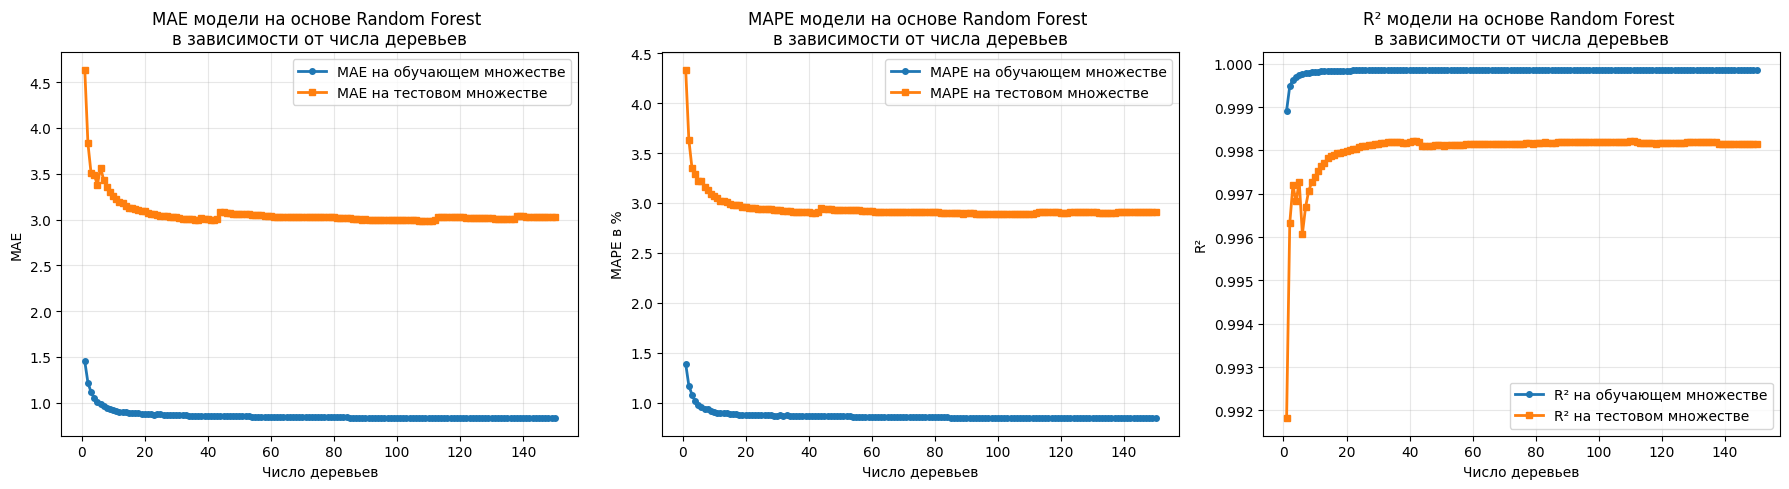

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

#Построить график зависимости метрик MAE, MAPE и R2 от числа деревьев в случайном лесе
def plot_rf_train_test_curve(X_train, y_train, X_test, y_test,
                             best_params, max_trees=150, step=1):
    
    rf = RandomForestRegressor(
        n_estimators=step,  #Начинаем с шага
        warm_start=True,    #Позволяет дообучать модель на ходу, добавляя в неё новые деревья
        random_state=11,
        **{k: v for k, v in best_params.items() if k != 'n_estimators'}
    )
    
    #Словарь с метриками и значениями числа деревьев
    results = {'n_estimators': [], 'train_mae': [], 'test_mae': [], 
               'train_mape': [], 'test_mape': [], 'train_r2': [], 'test_r2': []}
    
    #Дообучаем модель в цикле и считаем новые метрики
    for n_trees in range(step, max_trees + 1, step):
        rf.n_estimators = n_trees
        rf.fit(X_train, y_train)  #Дообучаем с использованием новых деревьев
        
        #Предсказываем
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)
        
        #Записываем результирующие метрики
        results['n_estimators'].append(n_trees)
        results['train_mae'].append(mean_absolute_error(y_train, y_train_pred))
        results['test_mae'].append(mean_absolute_error(y_test, y_test_pred))
        results['train_mape'].append(mean_absolute_percentage_error(y_train, y_train_pred) * 100)
        results['test_mape'].append(mean_absolute_percentage_error(y_test, y_test_pred) * 100)
        results['train_r2'].append(r2_score(y_train, y_train_pred))
        results['test_r2'].append(r2_score(y_test, y_test_pred))
    
    #Строим графики
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    #MAE
    axes[0].plot(results['n_estimators'], results['train_mae'], 
                label='MAE на обучающем множестве', marker='o', linewidth=2, markersize=4)
    axes[0].plot(results['n_estimators'], results['test_mae'], 
                label='MAE на тестовом множестве', marker='s', linewidth=2, markersize=4)
    axes[0].set_xlabel('Число деревьев')
    axes[0].set_ylabel('MAE')
    axes[0].set_title('MAE модели на основе Random Forest \nв зависимости от числа деревьев')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    #MAPE
    axes[1].plot(results['n_estimators'], results['train_mape'], 
                label='MAPE на обучающем множестве', marker='o', linewidth=2, markersize=4)
    axes[1].plot(results['n_estimators'], results['test_mape'], 
                label='MAPE на тестовом множестве', marker='s', linewidth=2, markersize=4)
    axes[1].set_xlabel('Число деревьев')
    axes[1].set_ylabel('MAPE в %')
    axes[1].set_title('MAPE модели на основе Random Forest \nв зависимости от числа деревьев')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    #R^2
    axes[2].plot(results['n_estimators'], results['train_r2'], 
                label='R² на обучающем множестве', marker='o', linewidth=2, markersize=4)
    axes[2].plot(results['n_estimators'], results['test_r2'], 
                label='R² на тестовом множестве', marker='s', linewidth=2, markersize=4)
    axes[2].set_xlabel('Число деревьев')
    axes[2].set_ylabel('R²')
    axes[2].set_title('R² модели на основе Random Forest \nв зависимости от числа деревьев')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


plot_rf_train_test_curve(X_train_validation.drop(columns='swimmer_id'),Y_train_validation,X_test.drop(columns='swimmer_id'),Y_test,{'max_depth':20,'criterion':'friedman_mse','min_samples_leaf':2,'max_features':0.5})

## Построить графики для ElasticNet

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.327e+08, tolerance: 6.601e+05
  model = cd_fast.enet_coordinate_descent(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.165e+07, tolerance: 6.601e+05
  model = cd_fast.enet_coordinate_descent(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider in

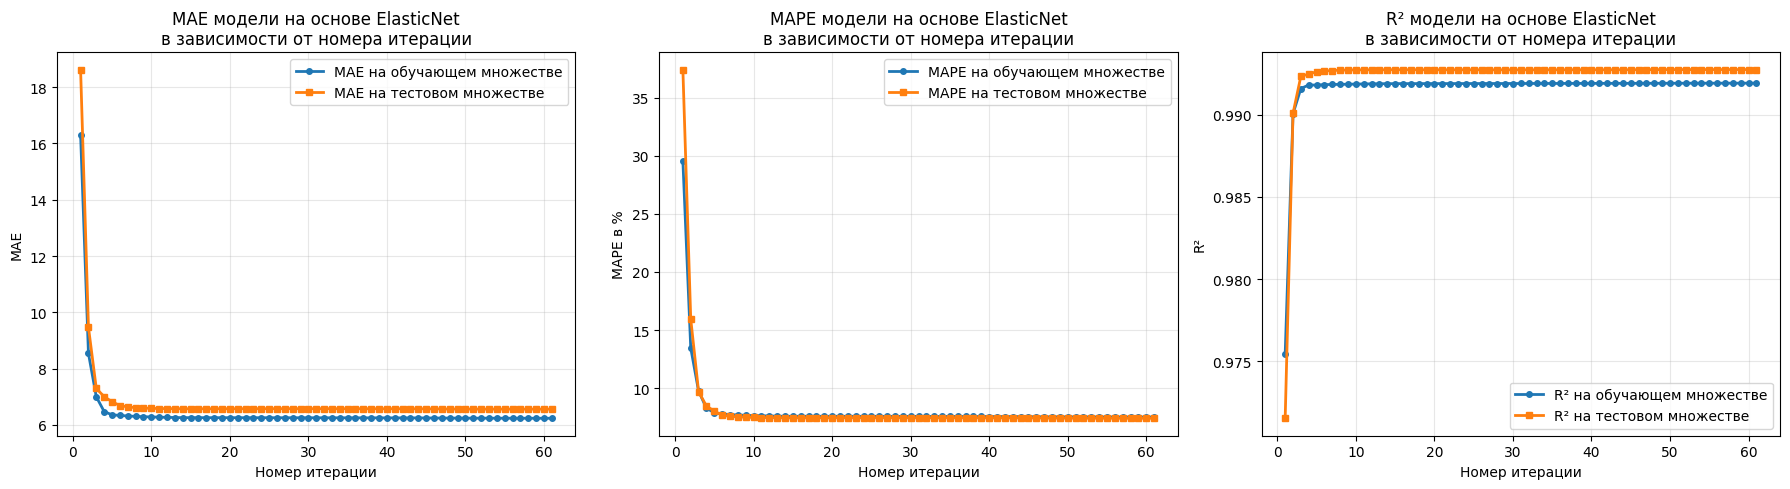

In [12]:
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,r2_score

#Построить график зависимости метрик MAE, MAPE и R2 от номера итерации в ElasticNet
def plot_en_train_test_curve(X_train, y_train, X_test, y_test,
                             best_params, max_iterations=1000, step=1):
    
    
    
    
    
    #Словарь с метриками и значениями номера итерации
    results = {'n_iterations': [], 'train_mae': [], 'test_mae': [], 
               'train_mape': [], 'test_mape': [], 'train_r2': [], 'test_r2': []}
    
    #Дообучаем модель в цикле и считаем новые метрики
    for n_iterations in range(step, max_iterations + 1, step):
        en=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('standard_normalizator',StandardScaler(),make_column_selector(dtype_include='number'))], #Нормализация числовых колонок
                                                                remainder='drop')), #Игнорируем строки
                              ('regressor',ElasticNet(random_state=11,#Фиксируем случайность. Можно не передавать target transformer, так как лучшей оказалась модель без нормализации таргета
                                                      max_iter=n_iterations,  
                                                      **{k: v for k, v in best_params.items() if k != 'max_iter'},  # Распаковываем значения переданных лучших гиперпараметров
                                                      warm_start=False
                                                      ))]
                       )
        en.fit(X_train, y_train)  #Обучаем с увеличением числа итераций
        
        #Предсказываем
        y_train_pred = en.predict(X_train)
        y_test_pred = en.predict(X_test)
        
        #Оптимизатор сошелся, текущая итерация лишняя. Не нужно больше добавлять результаты
        if en.named_steps['regressor'].n_iter_<en.named_steps['regressor'].max_iter:
            break
        
        
        #Записываем результирующие метрики
        results['n_iterations'].append(n_iterations)
        results['train_mae'].append(mean_absolute_error(y_train, y_train_pred))
        results['test_mae'].append(mean_absolute_error(y_test, y_test_pred))
        results['train_mape'].append(mean_absolute_percentage_error(y_train, y_train_pred) * 100)
        results['test_mape'].append(mean_absolute_percentage_error(y_test, y_test_pred) * 100)
        results['train_r2'].append(r2_score(y_train, y_train_pred))
        results['test_r2'].append(r2_score(y_test, y_test_pred))
    
    #Строим графики
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    #MAE
    axes[0].plot(results['n_iterations'], results['train_mae'], 
                label='MAE на обучающем множестве', marker='o', linewidth=2, markersize=4)
    axes[0].plot(results['n_iterations'], results['test_mae'], 
                label='MAE на тестовом множестве', marker='s', linewidth=2, markersize=4)
    axes[0].set_xlabel('Номер итерации')
    axes[0].set_ylabel('MAE')
    axes[0].set_title('MAE модели на основе ElasticNet\nв зависимости от номера итерации')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    #MAPE
    axes[1].plot(results['n_iterations'], results['train_mape'], 
                label='MAPE на обучающем множестве', marker='o', linewidth=2, markersize=4)
    axes[1].plot(results['n_iterations'], results['test_mape'], 
                label='MAPE на тестовом множестве', marker='s', linewidth=2, markersize=4)
    axes[1].set_xlabel('Номер итерации')
    axes[1].set_ylabel('MAPE в %')
    axes[1].set_title('MAPE модели на основе ElasticNet\nв зависимости от номера итерации')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    #R^2
    axes[2].plot(results['n_iterations'], results['train_r2'], 
                label='R² на обучающем множестве', marker='o', linewidth=2, markersize=4)
    axes[2].plot(results['n_iterations'], results['test_r2'], 
                label='R² на тестовом множестве', marker='s', linewidth=2, markersize=4)
    axes[2].set_xlabel('Номер итерации')
    axes[2].set_ylabel('R²')
    axes[2].set_title('R² модели на основе ElasticNet\nв зависимости от номера итерации')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_en_train_test_curve(X_train_validation.drop(columns='swimmer_id'),Y_train_validation,X_test.drop(columns='swimmer_id'),Y_test,{'alpha':1,'l1_ratio':1})

## Построить графики для LinearSVR

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\den\Desktop\vkr_train_models\.venv\L

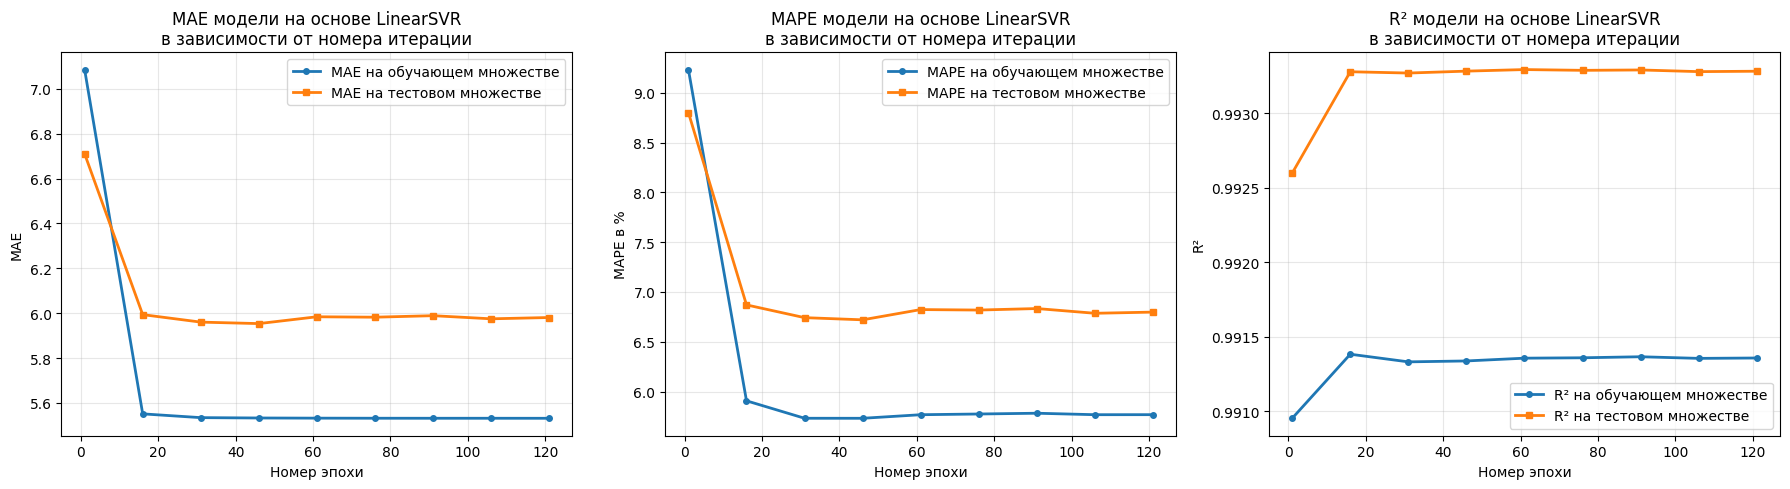

In [13]:
from sklearn.svm import LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,r2_score

#Построить график зависимости метрик MAE, MAPE и R2 от номера итерации в LinearSVR
def plot_linearSVR_train_test_curve(X_train, y_train, X_test, y_test,
                             best_params, max_iterations=1000, step=15):
    
    
    
    
    
    #Словарь с метриками и значениями номера итерации
    results = {'n_iterations': [], 'train_mae': [], 'test_mae': [], 
               'train_mape': [], 'test_mape': [], 'train_r2': [], 'test_r2': []}
    
    #Дообучаем модель в цикле и считаем новые метрики
    for n_iterations in range(1, max_iterations + 1, step):
        l_svr=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('standard_normalizator',StandardScaler(),make_column_selector(dtype_include='number'))], #Нормализация числовых колонок
                                                                remainder='drop')), #Игнорируем строки
                              ('regressor',LinearSVR(random_state=11,#Фиксируем случайность
                                                      max_iter=n_iterations,  
                                                      **{k: v for k, v in best_params.items() if k != 'max_iter'},  # Распаковываем значения переданных лучших гиперпараметров
                                                      ))]
                       )
        l_svr.fit(X_train, y_train)  #Обучаем с увеличением числа итераций
        
        #Предсказываем
        y_train_pred = l_svr.predict(X_train)
        y_test_pred = l_svr.predict(X_test)
        
        #Оптимизатор сошелся, текущая итерация лишняя. Не нужно больше добавлять результаты
        if l_svr.named_steps['regressor'].n_iter_<l_svr.named_steps['regressor'].max_iter:
            break
        
        
        #Записываем результирующие метрики
        results['n_iterations'].append(n_iterations)
        results['train_mae'].append(mean_absolute_error(y_train, y_train_pred))
        results['test_mae'].append(mean_absolute_error(y_test, y_test_pred))
        results['train_mape'].append(mean_absolute_percentage_error(y_train, y_train_pred) * 100)
        results['test_mape'].append(mean_absolute_percentage_error(y_test, y_test_pred) * 100)
        results['train_r2'].append(r2_score(y_train, y_train_pred))
        results['test_r2'].append(r2_score(y_test, y_test_pred))
    
    #Строим графики
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    #MAE
    axes[0].plot(results['n_iterations'], results['train_mae'], 
                label='MAE на обучающем множестве', marker='o', linewidth=2, markersize=4)
    axes[0].plot(results['n_iterations'], results['test_mae'], 
                label='MAE на тестовом множестве', marker='s', linewidth=2, markersize=4)
    axes[0].set_xlabel('Номер эпохи')
    axes[0].set_ylabel('MAE')
    axes[0].set_title('MAE модели на основе LinearSVR\nв зависимости от номера итерации')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    #MAPE
    axes[1].plot(results['n_iterations'], results['train_mape'], 
                label='MAPE на обучающем множестве', marker='o', linewidth=2, markersize=4)
    axes[1].plot(results['n_iterations'], results['test_mape'], 
                label='MAPE на тестовом множестве', marker='s', linewidth=2, markersize=4)
    axes[1].set_xlabel('Номер эпохи')
    axes[1].set_ylabel('MAPE в %')
    axes[1].set_title('MAPE модели на основе LinearSVR\nв зависимости от номера итерации')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    #R^2
    axes[2].plot(results['n_iterations'], results['train_r2'], 
                label='R² на обучающем множестве', marker='o', linewidth=2, markersize=4)
    axes[2].plot(results['n_iterations'], results['test_r2'], 
                label='R² на тестовом множестве', marker='s', linewidth=2, markersize=4)
    axes[2].set_xlabel('Номер эпохи')
    axes[2].set_ylabel('R²')
    axes[2].set_title('R² модели на основе LinearSVR\nв зависимости от номера итерации')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_linearSVR_train_test_curve(X_train_validation.drop(columns='swimmer_id'),Y_train_validation,X_test.drop(columns='swimmer_id'),Y_test,{'loss':'epsilon_insensitive','epsilon':0.1,'C':0.1,
                                                                                                                                    'intercept_scaling':1})

## Построить графики для XGBoost

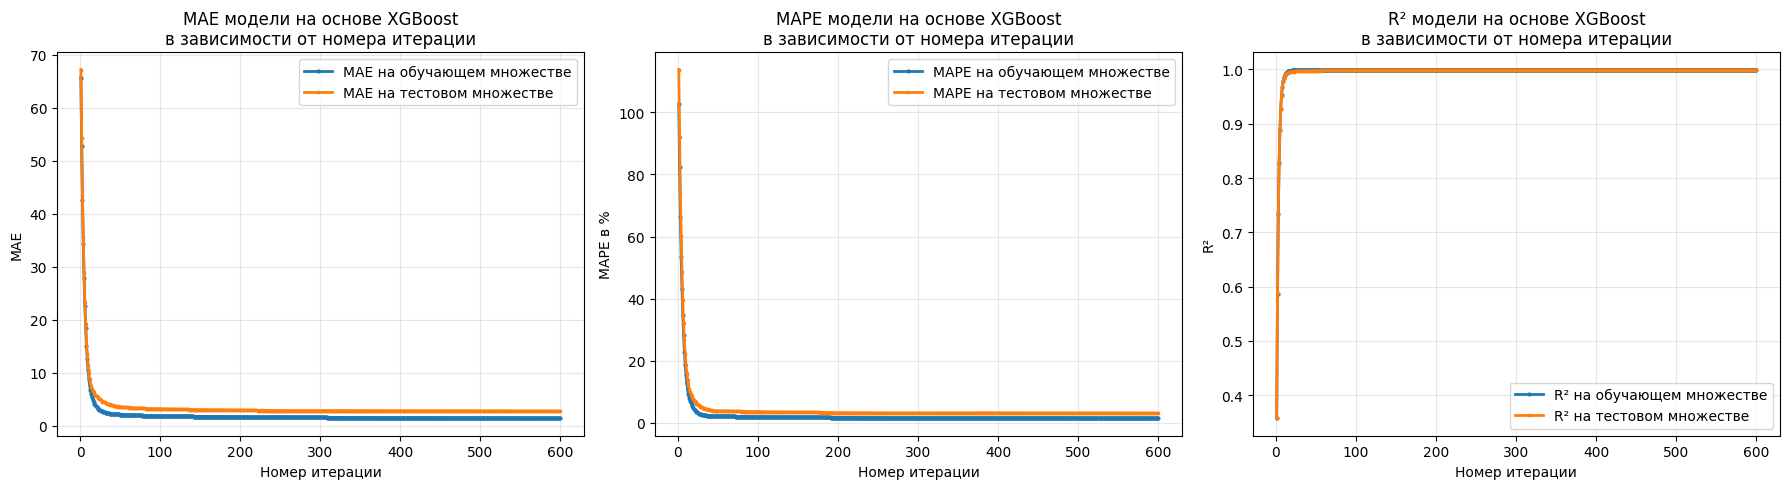

In [14]:
from sklearn.svm import LinearSVR
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,r2_score

#Построить график зависимости метрик MAE, MAPE и R2 от номера итерации в XGBoost
def plot_XGBoost_train_test_curve(X_train, y_train, X_test, y_test,
                             best_params):
    
    
    
    
    
    #Словарь с метриками и значениями номера итерации
    results = {'n_iterations': [], 'train_mae': [], 'test_mae': [], 
               'train_mape': [], 'test_mape': [], 'train_r2': [], 'test_r2': []}
    
    xgbr=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('select_only_numbers','passthrough',make_column_selector(dtype_include='number'))], #Берем только числовые признаки
                                                                remainder='drop')), #Остальные колонки игнорируем
                              ('regressor',XGBRegressor(random_state=11,n_jobs=-1, #Зафиксировать случайность и распараллелить на все ядра цпу
                                                        **{k: v for k, v in best_params.items()},  # Распаковываем значения переданных лучших гиперпараметров
                                                        ))])
    trees_count=best_params['n_estimators']
    xgbr.fit(X_train, y_train)  #Обучаем
    
    
    for i in range(1,trees_count+1,1):
        #Предсказываем на деревьях с первых i итераций
        y_train_pred=xgbr.predict(X_train,iteration_range=(0,i))
        y_test_pred=xgbr.predict(X_test,iteration_range=(0,i))
        
        
        #Записываем результирующие метрики
        results['n_iterations'].append(i)
        results['train_mae'].append(mean_absolute_error(y_train, y_train_pred))
        results['test_mae'].append(mean_absolute_error(y_test, y_test_pred))
        results['train_mape'].append(mean_absolute_percentage_error(y_train, y_train_pred) * 100)
        results['test_mape'].append(mean_absolute_percentage_error(y_test, y_test_pred) * 100)
        results['train_r2'].append(r2_score(y_train, y_train_pred))
        results['test_r2'].append(r2_score(y_test, y_test_pred))
    
    #Строим графики
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    #MAE
    axes[0].plot(results['n_iterations'], results['train_mae'], 
                label='MAE на обучающем множестве', marker='o', linewidth=2, markersize=2)
    axes[0].plot(results['n_iterations'], results['test_mae'], 
                label='MAE на тестовом множестве', marker='s', linewidth=2, markersize=2)
    axes[0].set_xlabel('Номер итерации')
    axes[0].set_ylabel('MAE')
    axes[0].set_title('MAE модели на основе XGBoost\nв зависимости от номера итерации')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    #MAPE
    axes[1].plot(results['n_iterations'], results['train_mape'], 
                label='MAPE на обучающем множестве', marker='o', linewidth=2, markersize=2)
    axes[1].plot(results['n_iterations'], results['test_mape'], 
                label='MAPE на тестовом множестве', marker='s', linewidth=2, markersize=2)
    axes[1].set_xlabel('Номер итерации')
    axes[1].set_ylabel('MAPE в %')
    axes[1].set_title('MAPE модели на основе XGBoost\nв зависимости от номера итерации')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    #R^2
    axes[2].plot(results['n_iterations'], results['train_r2'], 
                label='R² на обучающем множестве', marker='o', linewidth=2, markersize=2)
    axes[2].plot(results['n_iterations'], results['test_r2'], 
                label='R² на тестовом множестве', marker='s', linewidth=2, markersize=2)
    axes[2].set_xlabel('Номер итерации')
    axes[2].set_ylabel('R²')
    axes[2].set_title('R² модели на основе XGBoost\nв зависимости от номера итерации')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_XGBoost_train_test_curve(X_train_validation.drop(columns='swimmer_id'),Y_train_validation,X_test.drop(columns='swimmer_id'),Y_test,
                                {'n_estimators':600, 'max_depth':4, 'learning_rate':0.2, 'objective':'reg:squarederror', 'subsample':0.8, 'colsample_bytree':1,
                                 'reg_lambda':0.5, 'reg_alpha':0.5, 'gamma':0})

## Построить графики для MLP

In [15]:
from tensorflow.keras.regularizers import l1_l2
from keras import layers
from keras import activations
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from functools import partial
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.metrics import R2Score
from scikeras.wrappers import KerasRegressor
from random import seed
from os import environ
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,r2_score
from scikeras.wrappers import KerasRegressor
from tensorflow.keras.callbacks import Callback


SEED=11

#Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'


#Класс для преобразования таргета
class TargetTrasnsformer_Log_Standard_or_None(BaseEstimator,TransformerMixin):
    def __init__(self,method='none'):        
        super().__init__()
        self.method=method
    
    def fit(self,y,X=None):
        if self.method=='standard':
            self.scaler_=StandardScaler().fit(y)
        return self
    
    def transform(self,y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method=='log':
            return np.log(np.clip(y, 1e-9, None)).ravel()
        elif self.method=='standard':
            return self.scaler_.transform(y).ravel()
        elif self.method=='none':
            return y.ravel()
        else:
            raise ValueError("Неизвестное значение метода для нормализации таргета! Доступные значения: ['none','log','standard']")
    
    def inverse_transform(self,y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method=='log':
            return np.exp(y).ravel()
        elif self.method=='standard':
            return self.scaler_.inverse_transform(y).ravel()
        elif self.method=='none':
            return y.ravel()
        else:
            raise ValueError("Неизвестное значение метода для нормализации таргета! Доступные значения: ['none','log','standard']")
        







#Описание модели
def build_model_MLP(meta,num_layers=2,
                               neurons_in_layer=32,
                               activation_function='leaky_relu',
                               dropout_rate=0,
                               learning_rate=0.01,
                               loss_function='mse'):
    
  tf.random.set_seed(SEED)  
  #Определяем слои по порядку, один за другим
  model = Sequential()

  #Входной слой
  tf.random.set_seed(SEED);model.add(Input(shape=(meta["n_features_in_"],)))

  #Скрытые слои
  for i in range(num_layers):
    tf.random.set_seed(SEED);model.add(Dense(neurons_in_layer, activation=activation_function))
    #Добавляем дропаут для каждого скрытого слоя
    if dropout_rate>0:
      tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

  #Выходной слой
  tf.random.set_seed(SEED);model.add(Dense(1, activation='linear'))

  model.compile(optimizer=Adam(learning_rate=learning_rate), loss=loss_function,metrics=['mean_absolute_error',
                                                                                         'mean_absolute_percentage_error',
                                                                                         'r2_score'])
  return model


#Создаём переменную модели, лучшие гиперпараметры для модели и трансформера таргета захардкожены
MLP_model_for_plot=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('standard_normalizator',StandardScaler(),make_column_selector(dtype_include='number'))], #Нормализация числовых признаков
                                                                remainder='drop')), #Остальные колонки игнорируем
                              ('regressor',TransformedTargetRegressor(regressor=
                                  KerasRegressor(model=build_model_MLP,verbose=0,
                               activation_function='leaky_relu',
                               batch_size=128,
                               dropout_rate=0.1,
                               epochs=50,
                               learning_rate=0.001,
                               loss_function='mae',
                               neurons_in_layer=300,
                               num_layers=2,
                               random_state=SEED
                               ),transformer=TargetTrasnsformer_Log_Standard_or_None(method='none')))]
                       )
features_transformer=ColumnTransformer(transformers=[('standard_normalizator',StandardScaler(),make_column_selector(dtype_include='number'))],remainder='drop')

features_transformer.fit(X_train_validation)



#Обучаем модель
MLP_model_for_plot.fit(X_train_validation,Y_train_validation,
                       regressor__validation_data=(features_transformer.transform(X_test), #Передаём тестовое множество для получения метрик на нём
                                                              Y_test))  

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standard_normalizator', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

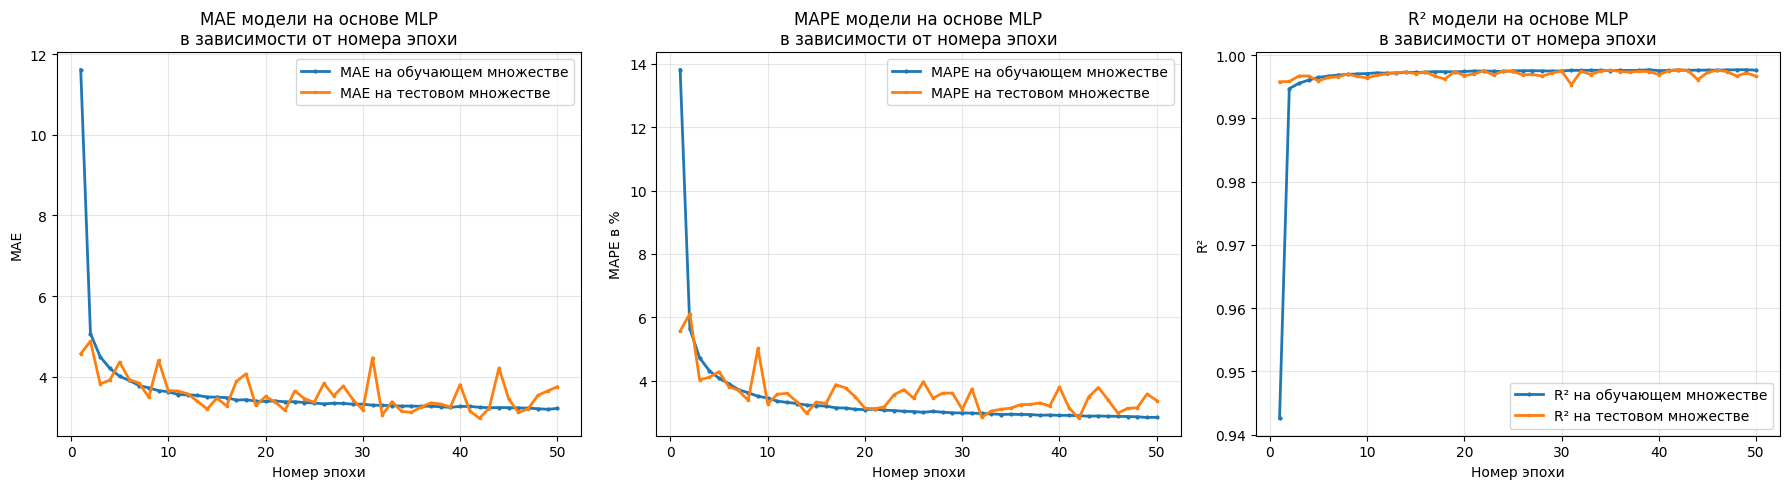

In [16]:
import matplotlib.pyplot as plt
#Строим график
mae_train_MLP=MLP_model_for_plot.named_steps['regressor'].regressor_.history_['mean_absolute_error']
mae_test_MLP=MLP_model_for_plot.named_steps['regressor'].regressor_.history_['val_mean_absolute_error']

mape_train_MLP=MLP_model_for_plot.named_steps['regressor'].regressor_.history_['mean_absolute_percentage_error']
mape_test_MLP=MLP_model_for_plot.named_steps['regressor'].regressor_.history_['val_mean_absolute_percentage_error']

r2_train_MLP=MLP_model_for_plot.named_steps['regressor'].regressor_.history_['r2_score']
r2_test_MLP=MLP_model_for_plot.named_steps['regressor'].regressor_.history_['val_r2_score']

epochs_arr_MLP=list(i for i in range(1,len(r2_train_MLP)+1))


#Строим графики
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#MAE
axes[0].plot(epochs_arr_MLP, mae_train_MLP, 
            label='MAE на обучающем множестве', marker='o', linewidth=2, markersize=2)
axes[0].plot(epochs_arr_MLP, mae_test_MLP, 
            label='MAE на тестовом множестве', marker='s', linewidth=2, markersize=2)
axes[0].set_xlabel('Номер эпохи')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE модели на основе MLP\nв зависимости от номера эпохи')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#MAPE
axes[1].plot(epochs_arr_MLP, mape_train_MLP, 
            label='MAPE на обучающем множестве', marker='o', linewidth=2, markersize=2)
axes[1].plot(epochs_arr_MLP, mape_test_MLP, 
            label='MAPE на тестовом множестве', marker='s', linewidth=2, markersize=2)
axes[1].set_xlabel('Номер эпохи')
axes[1].set_ylabel('MAPE в %')
axes[1].set_title('MAPE модели на основе MLP\nв зависимости от номера эпохи')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

#R^2
axes[2].plot(epochs_arr_MLP, r2_train_MLP, 
            label='R² на обучающем множестве', marker='o', linewidth=2, markersize=2)
axes[2].plot(epochs_arr_MLP, r2_test_MLP, 
            label='R² на тестовом множестве', marker='s', linewidth=2, markersize=2)
axes[2].set_xlabel('Номер эпохи')
axes[2].set_ylabel('R²')
axes[2].set_title('R² модели на основе MLP\nв зависимости от номера эпохи')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Построить графики для BiLSTM

In [ ]:
from tensorflow.keras.regularizers import l1_l2
from keras import layers
from keras import activations
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from functools import partial
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.metrics import R2Score
from scikeras.wrappers import KerasRegressor
from random import seed
from os import environ
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Masking,Bidirectional,LSTM,Dense,Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from numpy.lib.stride_tricks import sliding_window_view
import tensorflow as tf
import numpy as np
import joblib
SEED=11

#Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'

#Описание модели
def build_model_GridSearch_BiLSTM(meta,
                                   num_bilstm_layers=1,
                                   lstm_units_in_layer=16,
                                   num_dense_io_layers=1,
                                   dense_neurons_in_layer=32,
                                   activation_function='leaky_relu',
                                   dropout_rate=0,
                                   learning_rate=0.001,
                                   loss_function='mse'):

    tf.random.set_seed(SEED)

    input_shape = meta["X_shape_"][1:]  #Получаем размерность входных данных (будет кортеж (число элементов в 1 временной последовательности,число признаков))

    model = Sequential()
    tf.random.set_seed(SEED);model.add(Input(shape=input_shape))
    
    #Значения, маскированные -999 (пустые значения, которыми слева заполнялись последовательности внутри BiLSTM) будут игнорироваться при обучении
    tf.random.set_seed(SEED);model.add(Masking(mask_value=-999.0))
    
    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))


    for i in range(num_bilstm_layers):
        if i<num_bilstm_layers-1:        
            tf.random.set_seed(SEED);model.add(Bidirectional(LSTM(lstm_units_in_layer, return_sequences=True)))  #На выходе - 3d тензор. Передаем его для следующего BiLSTM слоя
        else:
            tf.random.set_seed(SEED);model.add(Bidirectional(LSTM(lstm_units_in_layer, return_sequences=False))) #На выходе - 2d тензор. Передаем его для полносвязного слоя
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    tf.random.set_seed(SEED);model.add(Dense(1, activation='linear'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),loss=loss_function, metrics=['mean_absolute_error', 'mean_absolute_percentage_error', 'r2_score'])
    return model

#Класс для преобразования таргета
class TargetTrasnsformer_Log_Standard_or_None(BaseEstimator, TransformerMixin):
    def __init__(self, method='none'):
        super().__init__()
        self.method = method

    def fit(self, y, X=None):
        if self.method == 'standard':
            #Делаем reshape, т.к. StandardScaler ожидает 2D
            self.scaler_ = StandardScaler().fit(np.asarray(y).reshape(-1, 1))
        return self

    def transform(self, y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method == 'log':
            return np.log(np.clip(y, 1e-9, None)).ravel()
        elif self.method == 'standard':
            return self.scaler_.transform(y).ravel()
        elif self.method == 'none':
            return y.ravel()
        else:
            raise ValueError("Недопустимое значение типа преобразования целевой переменной! Возможные значения: ['none','log','standard']")

    def inverse_transform(self, y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method == 'log':
            return np.exp(y).ravel()
        elif self.method == 'standard':
            return self.scaler_.inverse_transform(y).ravel()
        elif self.method == 'none':
            return y.ravel()
        else:
            raise ValueError("Недопустимое значение типа преобразования целевой переменной! Возможные значения: ['none','log','standard']")

sequences_from_train_data=None  #Входные последовательности BiLSTM из обучающего множества

#Класс для нормализации входных признаков и переделки их в формат, подходящий на вход к BiLSTM
class SequenceStandardScalerForBiLSTM(BaseEstimator, TransformerMixin):
    def __init__(self,
                 window_size=5,                           #Размер окна для последовательности
                 ):
        self.window_size = window_size                
        self.is_train_data_transformed=False             #Флаг, показывает, были ли преобразованы тренировочные данные через transform
        
    #Вернуть только те колонки датафрейма, которые не являются строками или объектами
    def _get_required_columns_from_dataset(self, X):
        return X.select_dtypes(include='number').columns.tolist()


    def fit(self, X, y=None):
        #Обучаем StandardScaler для признаков на тренировочном датасете
        self.feature_cols = self._get_required_columns_from_dataset(X)
        self.scaler_ = StandardScaler().fit(X[self.feature_cols])     
        self.is_train_data_transformed = False

        return self

    def transform(self, X):
        if not self.is_train_data_transformed:  #На train данных
            X_scaled = X.copy()
        
            #Получить углы дня года и времени в секундах дня - для сортировки записей в хронологическом порядке
            X_scaled['_doy_angle'] = np.arctan2(X['race_doy_sin'], X['race_doy_cos']) % (2 * np.pi)
            X_scaled['_time_angle'] = np.arctan2(X['race_time_seconds_sin'], X['race_time_seconds_cos']) % (2 * np.pi)
            
            #Преобразуем значения внутри датафрейма согласно StandardScaler
            X_scaled[self.feature_cols] = self.scaler_.transform(X[self.feature_cols])
            
            X_scaled['_original_idx'] = np.arange(len(X))  
            
            #Сортируем датафрейм сначала по ИД пловца, затем по году заплыва, затем по углу дня года, затем по углу времени дня
            X_scaled = X_scaled.sort_values(by=['swimmer_id', 'race_year', '_doy_angle', '_time_angle'])
            
            #Есть проблема, что не у всех строк в датасете было время (оно было импутировано для некоторых значений).
            #Однако дата есть у всех строк. В целом же погрешность времени в течении дня не должно сильно влиять на производительность модели
            
            
            #Выходной 3D массив на вход к модели
            sequences = np.zeros((len(X), self.window_size, len(self.feature_cols)), dtype=np.float32)
            
            #Получаем последовательности для обучения BiLSTM и сохраняем 
            self.swimmer_history = {}            
            for swimmer_id, group in X_scaled.groupby('swimmer_id', sort=False):
                X_for_1_swimmer = group[self.feature_cols].values.astype(np.float32)                      #Отсортированный массив результатов одного пловца
                paddings=np.full((self.window_size-1, len(self.feature_cols)), -999.0, dtype=np.float32)  #(windows_size-1,n_features)
                swimmer_history_sequence=np.vstack([paddings,X_for_1_swimmer])                             #(len(X_for_1_swimmer)+windows_size-1,n_features) 
                original_indices = group['_original_idx'].values                              
                
                windows = sliding_window_view(swimmer_history_sequence, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),n_features,windows_size)
                
                #Переставить местами два измерения массива, так как BiLSTM ожидает массив размерности (batch,timesteps,n_features)
                windows = np.swapaxes(windows, 1, 2) #(len(X_for_1_swimmer),windows_size,n_features)
                
                #Присваиваем результирующие последовательности для обучения BiLSTM внутрь выходного 3Д массива
                sequences[original_indices] = windows 
                
                self.swimmer_history[swimmer_id] = X_for_1_swimmer[-(self.window_size - 1):]      #Сохраняем последние записи пловца в историю
                
            self.is_train_data_transformed=True
            global sequences_from_train_data; sequences_from_train_data=sequences
            return sequences
        else:   #На test/validation данных
            X_scaled = X.copy()
        
            #Получить углы дня года и времени в секундах дня - для сортировки записей в хронологическом порядке
            X_scaled['_doy_angle'] = np.arctan2(X['race_doy_sin'], X['race_doy_cos']) % (2 * np.pi)
            X_scaled['_time_angle'] = np.arctan2(X['race_time_seconds_sin'], X['race_time_seconds_cos']) % (2 * np.pi)
            
            #Преобразуем значения внутри датафрейма согласно StandardScaler
            X_scaled[self.feature_cols] = self.scaler_.transform(X[self.feature_cols])
            
            X_scaled['_original_idx'] = np.arange(len(X)) 
            
            #Сортируем датафрейм сначала по ИД пловца, затем по году заплыва, затем по углу дня года, затем по углу времени дня
            X_scaled = X_scaled.sort_values(by=['swimmer_id', 'race_year', '_doy_angle', '_time_angle'])
                                   
            #Выходной 3D массив на вход к модели
            sequences = np.zeros((len(X), self.window_size, len(self.feature_cols)), dtype=np.float32)
            
            #Получаем последовательности для обучения BiLSTM и сохраняем             
            for swimmer_id, group in X_scaled.groupby('swimmer_id', sort=False):
                X_for_1_swimmer = group[self.feature_cols].values.astype(np.float32)                      #Отсортированный массив результатов одного пловца
                
                #Пытаемся получить историю пловца
                history = self.swimmer_history.get(
                    swimmer_id,
                    np.zeros((0, len(self.feature_cols)), dtype=np.float32)
                )
                
                padding_size=max(0,self.window_size-1-len(history))  #Размер паддинга слева значениями -999
                
                #Строим массив последовательностей
                swimmer_sequences=None
                if padding_size>0:
                    paddings=np.full((padding_size, len(self.feature_cols)), -999.0, dtype=np.float32)   #(padding_size,n_features)
                    swimmer_sequences=np.vstack([paddings,history,X_for_1_swimmer])                     #(len(X_for_1_swimmer)+windows_size-1,n_features)
                else:
                    swimmer_sequences=np.vstack([history,X_for_1_swimmer])                     #(len(X_for_1_swimmer)+windows_size-1,n_features)
                original_indices = group['_original_idx'].values                              
                
                windows = sliding_window_view(swimmer_sequences, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),n_features,windows_size)
                
                #Переставить местами два измерения массива, так как BiLSTM ожидает массив размерности (batch,timesteps,n_features)
                windows = np.swapaxes(windows, 1, 2) #(len(X_for_1_swimmer),windows_size,n_features)
                
                #Присваиваем результирующие последовательности для обучения BiLSTM внутрь выходного 3Д массива
                sequences[original_indices] = windows               
                
            return sequences


BiLSTM_epochs_metrics={"mae":[],"mape":[],"r2":[],"mae_test":[],"mape_test":[],"r2_test":[]}
#Класс для подсчёта метрик после каждой эпохи
class MetricsCallback(Callback):
    
    def __init__(self,X_train,Y_train,X_test,Y_test,scaler_for_BiLSTM):  #Передаём тренировочное и тестовое множество, а также преобразователь в формат пригодный на вход в BiLSTM при создании
        super().__init__()
        self.X_train=X_train
        self.Y_train=Y_train
        self.X_test=X_test
        self.Y_test=Y_test
        self.X_preprocessor=scaler_for_BiLSTM
        self.target_transformer=TargetTrasnsformer_Log_Standard_or_None(method='standard')  #Метод - standard, так как он самый лучший в ходе гридсерч
        self.target_transformer.fit(Y_train)
    
    #Функция для подсчёта метрик после каждой эпохи
    def on_epoch_end(self, epoch, logs = None):
        global BiLSTM_epochs_metrics,sequences_from_train_data
        Y_train_predict=self.target_transformer.inverse_transform(self.model.predict(sequences_from_train_data))  #На тренировочном множестве используем результаты transform на тестовом множестве
        Y_test_predict=self.target_transformer.inverse_transform(self.model.predict(self.X_preprocessor.transform(self.X_test)))    #На тестовом множестве используем наш преобразователь входных признаков
        BiLSTM_epochs_metrics['mae'].append(mean_absolute_error(self.Y_train,Y_train_predict))
        BiLSTM_epochs_metrics['mape'].append(mean_absolute_percentage_error(self.Y_train,Y_train_predict)*100)
        BiLSTM_epochs_metrics['r2'].append(r2_score(self.Y_train,Y_train_predict))
        BiLSTM_epochs_metrics['mae_test'].append(mean_absolute_error(self.Y_test,Y_test_predict))
        BiLSTM_epochs_metrics['mape_test'].append(mean_absolute_percentage_error(self.Y_test,Y_test_predict)*100)
        BiLSTM_epochs_metrics['r2_test'].append(r2_score(self.Y_test,Y_test_predict))
        print(BiLSTM_epochs_metrics)
        
        
scaler_for_BiLSTM=SequenceStandardScalerForBiLSTM(window_size=7)

#Создаём переменную модели, лучшие гиперпараметры для модели и трансформера таргета захардкожены
BiLSTM_model_for_plot=Pipeline(steps=[
        ('preprocessor', scaler_for_BiLSTM),  
        ('regressor', TransformedTargetRegressor(
            regressor=KerasRegressor(
                model=build_model_GridSearch_BiLSTM,
                verbose=0,
                activation_function='leaky_relu',
                batch_size=128,
                dense_neurons_in_layer=64,
                dropout_rate=0.1,
                epochs=25,
                learning_rate=0.001,
                loss_function='mae',
                lstm_units_in_layer=128,
                
                num_bilstm_layers=2,
                num_dense_io_layers=0,
                random_state=SEED,
                callbacks=[MetricsCallback(X_train_validation,Y_train_validation,X_test,Y_test,scaler_for_BiLSTM)]
            ),
            transformer=TargetTrasnsformer_Log_Standard_or_None(method='standard')
        ))
    ])
'''features_transformer=SequenceStandardScalerForBiLSTM(window_size=7)
BiLSTM_feature_scaler_for_metrics_eval=SequenceStandardScalerForBiLSTM(window_size=7)
BiLSTM_feature_scaler_for_metrics_eval.fit_transform(X_train_validation)
features_transformer.fit(X_train_validation)'''



#Обучаем модель
BiLSTM_model_for_plot.fit(X_train_validation,Y_train_validation)  

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(


9569/9569 ━━━━━━━━━━━━━━━━━━━━ 75s 8ms/step
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
{'mae': [4.651399379283514], 'mape': [6.022353282849837], 'r2': [0.9967649032139291], 'mae_test': [5.241953898828714], 'mape_test': [6.533712540139351], 'r2_test': [0.9951443755823256]}
9569/9569 ━━━━━━━━━━━━━━━━━━━━ 78s 8ms/step
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
{'mae': [4.651399379283514, 3.505537011753336], 'mape': [6.022353282849837, 4.617328667996182], 'r2': [0.9967649032139291, 0.9979057637011955], 'mae_test': [5.241953898828714, 5.139653574082979], 'mape_test': [6.533712540139351, 6.000278051230373], 'r2_test': [0.9951443755823256, 0.995717453333232]}
9569/9569 ━━━━━━━━━━━━━━━━━━━━ 75s 8ms/step
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
{'mae': [4.651399379283514, 3.505537011753336, 3.4728205780209205], 'mape': [6.022353282849837, 4.617328667996182, 4.974882843012261], 'r2': [0.9967649032139291, 0.9979057637011955, 0.9984610720974954], 'mae_test': [5.241953898828714, 5.139653574082979, 4.54

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,window_size,7
,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",KerasRegresso..._io_layers=0 )
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",TargetTrasnsf...od='standard')
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,model,<function bui...002E226BCF920>


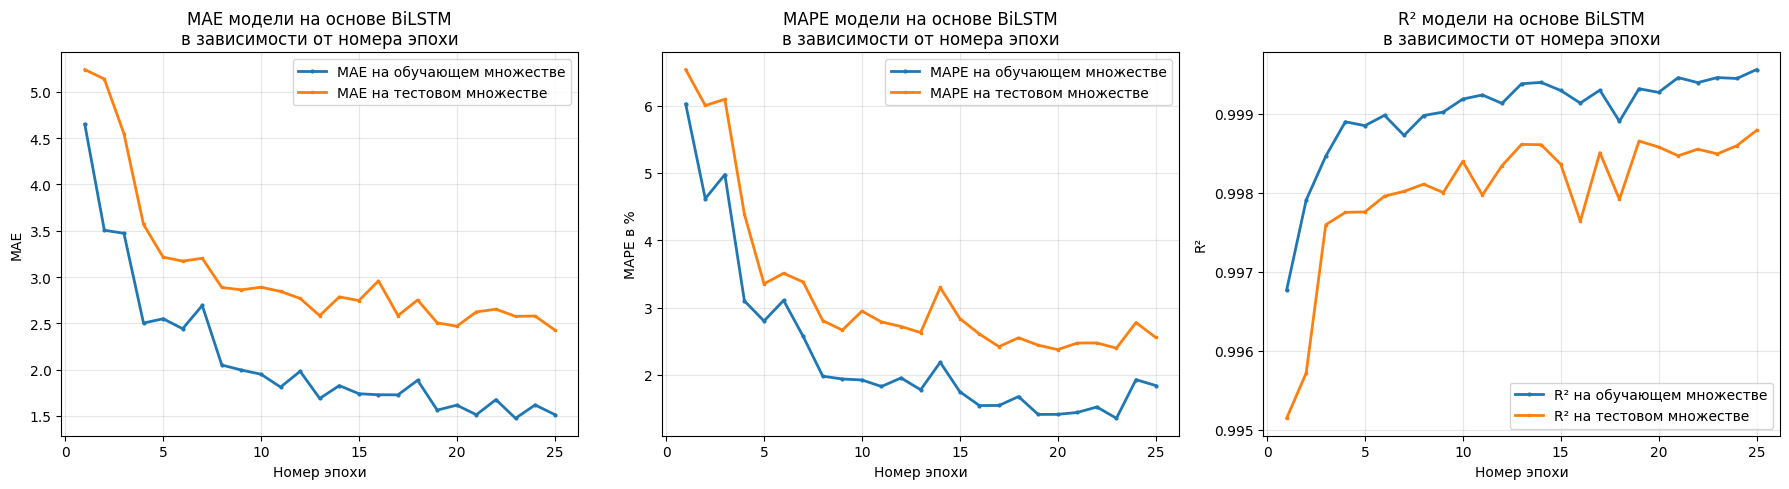

In [18]:
import matplotlib.pyplot as plt

epochs_arr_BiLSTM=list(i for i in range(1,len(BiLSTM_epochs_metrics['mae'])+1))


#Строим графики
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#MAE
axes[0].plot(epochs_arr_BiLSTM, BiLSTM_epochs_metrics['mae'], 
            label='MAE на обучающем множестве', marker='o', linewidth=2, markersize=2)
axes[0].plot(epochs_arr_BiLSTM, BiLSTM_epochs_metrics['mae_test'], 
            label='MAE на тестовом множестве', marker='s', linewidth=2, markersize=2)
axes[0].set_xlabel('Номер эпохи')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE модели на основе BiLSTM\nв зависимости от номера эпохи')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#MAPE
axes[1].plot(epochs_arr_BiLSTM, BiLSTM_epochs_metrics['mape'], 
            label='MAPE на обучающем множестве', marker='o', linewidth=2, markersize=2)
axes[1].plot(epochs_arr_BiLSTM, BiLSTM_epochs_metrics['mape_test'], 
            label='MAPE на тестовом множестве', marker='s', linewidth=2, markersize=2)
axes[1].set_xlabel('Номер эпохи')
axes[1].set_ylabel('MAPE в %')
axes[1].set_title('MAPE модели на основе BiLSTM\nв зависимости от номера эпохи')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

#R^2
axes[2].plot(epochs_arr_BiLSTM, BiLSTM_epochs_metrics['r2'], 
            label='R² на обучающем множестве', marker='o', linewidth=2, markersize=2)
axes[2].plot(epochs_arr_BiLSTM, BiLSTM_epochs_metrics['r2_test'], 
            label='R² на тестовом множестве', marker='s', linewidth=2, markersize=2)
axes[2].set_xlabel('Номер эпохи')
axes[2].set_ylabel('R²')
axes[2].set_title('R² модели на основе BiLSTM\nв зависимости от номера эпохи')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Строим диаграммы рассеяния предсказанное время vs реальное время

## Строим диаграмму рассеяния для ElasticNet

In [19]:
from sklearn.linear_model import ElasticNet
#Заново обучим модель c лучшими гиперпараметрами для использования в диаграммах
en_for_diagrams=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('standard_normalizator',StandardScaler(),make_column_selector(dtype_include='number'))], #Нормализация числовых колонок
                                                                remainder='drop')), #Игнорируем строки
                              ('regressor',ElasticNet(random_state=11,alpha=1,l1_ratio=1,max_iter=1000))],
                       )
en_for_diagrams.fit(X_train_validation,Y_train_validation)

#Получим ожидаемые значения на тестовом множестве
Y_pred_en=en_for_diagrams.predict(X_test)

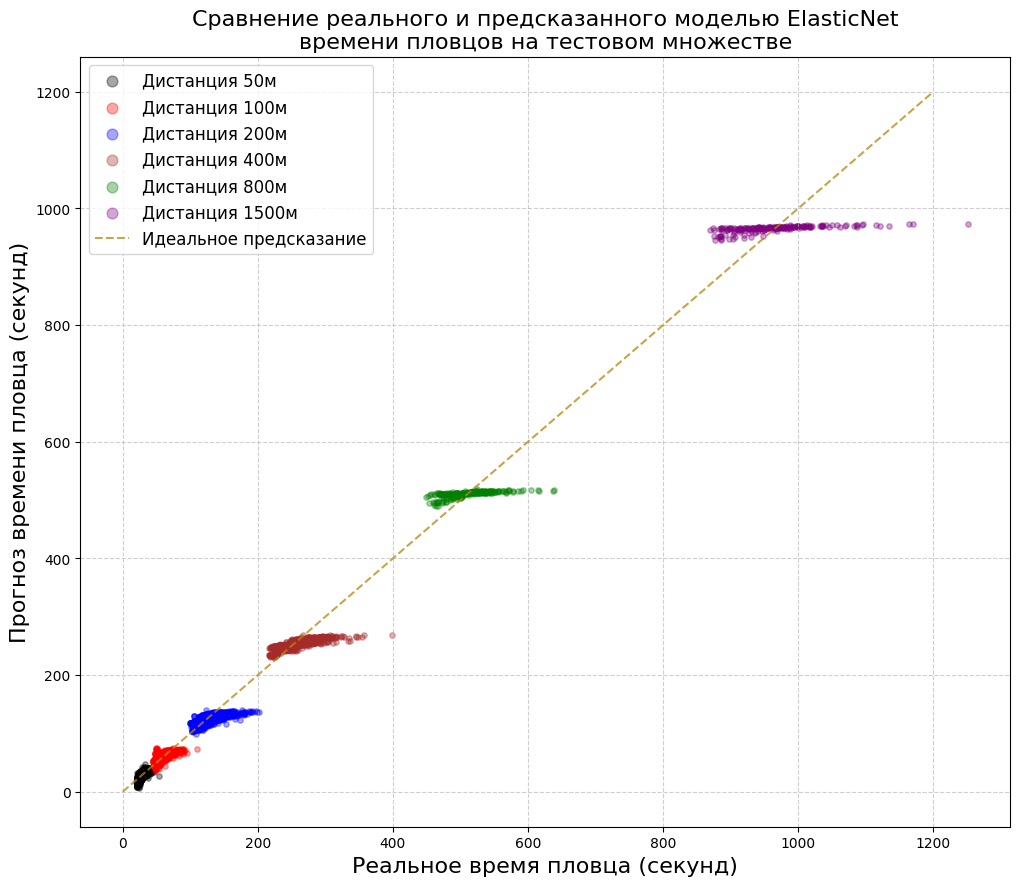

In [20]:
import matplotlib.pyplot as plt
import numpy as np


#Добавить цвета
colors=["black","red","blue","brown","green","purple"]

#Увеличить размер графика
plt.figure(figsize=(12, 10))

#Получить все дистанции в порядке возрастания
distances=sorted(X_test['distance'].unique())

for i in range(0,len(distances)):
    
    #Получить булеву маску элементов с данной дистанцией
    mask=(X_test['distance']==distances[i]).values

    #Строим на диаграмме рассеяния точки для данной дистанции
    plt.scatter(Y_test[mask], Y_pred_en[mask], alpha=0.35, s=15, color=colors[i], label=f"Дистанция {distances[i]}м")

# Добавляем линию идеального предсказания (y = x)
plt.plot([0,1200], [0,1200], '--', color='darkgoldenrod',alpha=0.75, label='Идеальное предсказание')

plt.xlabel("Реальное время пловца (секунд)",fontsize=16)
plt.ylabel("Прогноз времени пловца (секунд)",fontsize=16)
plt.title("Сравнение реального и предсказанного моделью ElasticNet\nвремени пловцов на тестовом множестве",fontsize=16)
plt.legend(fontsize=12, markerscale=2)  #Легенда
plt.grid(True, linestyle='--', alpha=0.6)  #Сетка координат
plt.show()

## Строим диаграмму рассеяния для LinearSVR

In [21]:
from sklearn.svm import LinearSVR
#Заново обучим модель c лучшими гиперпараметрами для использования в диаграммах
linear_SVR_for_diagrams=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('standard_normalizator',StandardScaler(),make_column_selector(dtype_include='number'))], #Нормализация числовых колонок
                                                                remainder='drop')), #Игнорируем строки
                              ('regressor',LinearSVR(random_state=11,loss='epsilon_insensitive',epsilon=0.1,C=0.1,intercept_scaling=1,max_iter=1000))],
                       )
linear_SVR_for_diagrams.fit(X_train_validation,Y_train_validation)

#Получим ожидаемые значения на тестовом множестве
Y_pred_linear_SVR=linear_SVR_for_diagrams.predict(X_test)

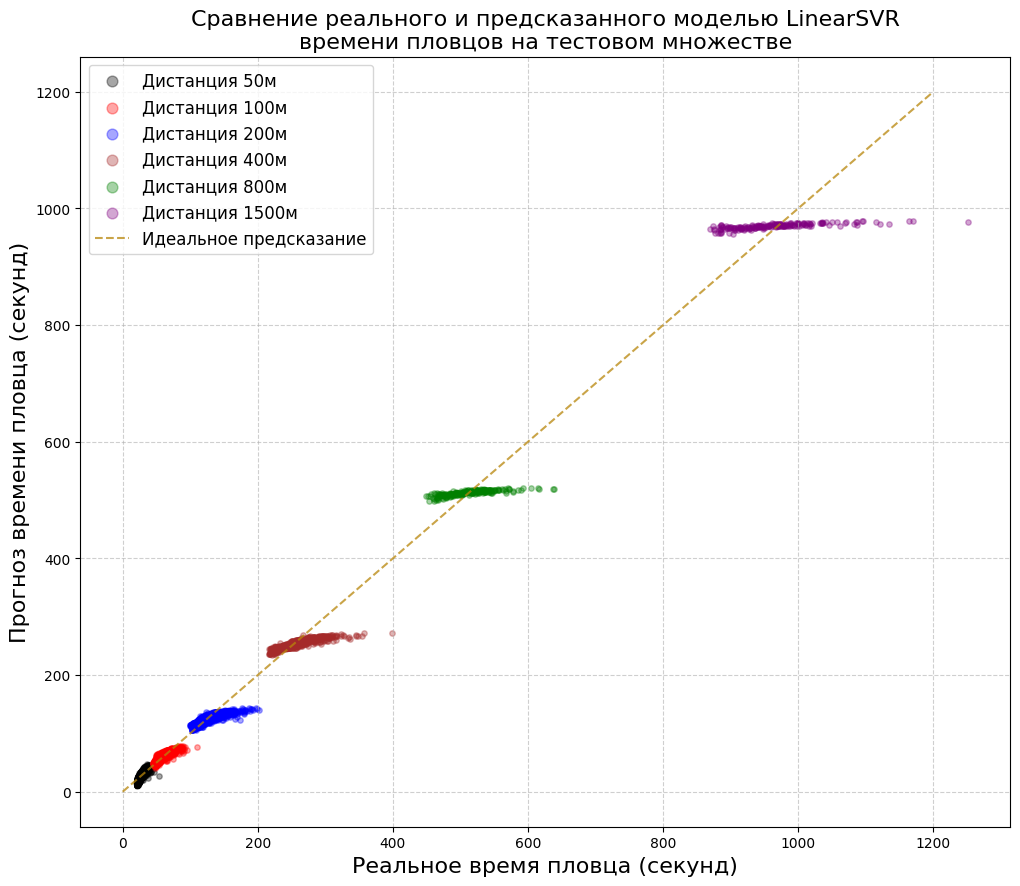

In [22]:
import matplotlib.pyplot as plt
import numpy as np


#Добавить цвета
colors=["black","red","blue","brown","green","purple"]

#Увеличить размер графика
plt.figure(figsize=(12, 10))

#Получить все дистанции в порядке возрастания
distances=sorted(X_test['distance'].unique())

for i in range(0,len(distances)):
    
    #Получить булеву маску элементов с данной дистанцией
    mask=(X_test['distance']==distances[i]).values

    #Строим на диаграмме рассеяния точки для данной дистанции
    plt.scatter(Y_test[mask], Y_pred_linear_SVR[mask], alpha=0.35, s=15, color=colors[i], label=f"Дистанция {distances[i]}м")

# Добавляем линию идеального предсказания (y = x)
plt.plot([0,1200], [0,1200], '--', color='darkgoldenrod',alpha=0.75, label='Идеальное предсказание')

plt.xlabel("Реальное время пловца (секунд)",fontsize=16)
plt.ylabel("Прогноз времени пловца (секунд)",fontsize=16)
plt.title("Сравнение реального и предсказанного моделью LinearSVR\nвремени пловцов на тестовом множестве",fontsize=16)
plt.legend(fontsize=12, markerscale=2)  #Легенда
plt.grid(True, linestyle='--', alpha=0.6)  #Сетка координат
plt.show()

## Строим диаграмму рассеяния для Random Forest

In [23]:
from sklearn.ensemble import RandomForestRegressor
#Заново обучим модель c лучшими гиперпараметрами для использования в диаграммах
rf_for_diagrams=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('select_only_numbers','passthrough',make_column_selector(dtype_include='number'))], #Берем только числовые признаки
                                                                remainder='drop')), #Остальные колонки игнорируем
                              ('regressor',RandomForestRegressor(random_state=11,n_jobs=-1, #Зафиксировать случайность и распараллелить на все ядра цпу
                                                                 #Вставляем найденные лучшие гиперпараметры
                                                                 n_estimators=150,
                                                                 max_depth=20,
                                                                 criterion='friedman_mse',
                                                                 min_samples_leaf=2,
                                                                 max_features=0.5))]
                       )
rf_for_diagrams.fit(X_train_validation,Y_train_validation)

#Получим ожидаемые значения на тестовом множестве
Y_pred_rf=rf_for_diagrams.predict(X_test)

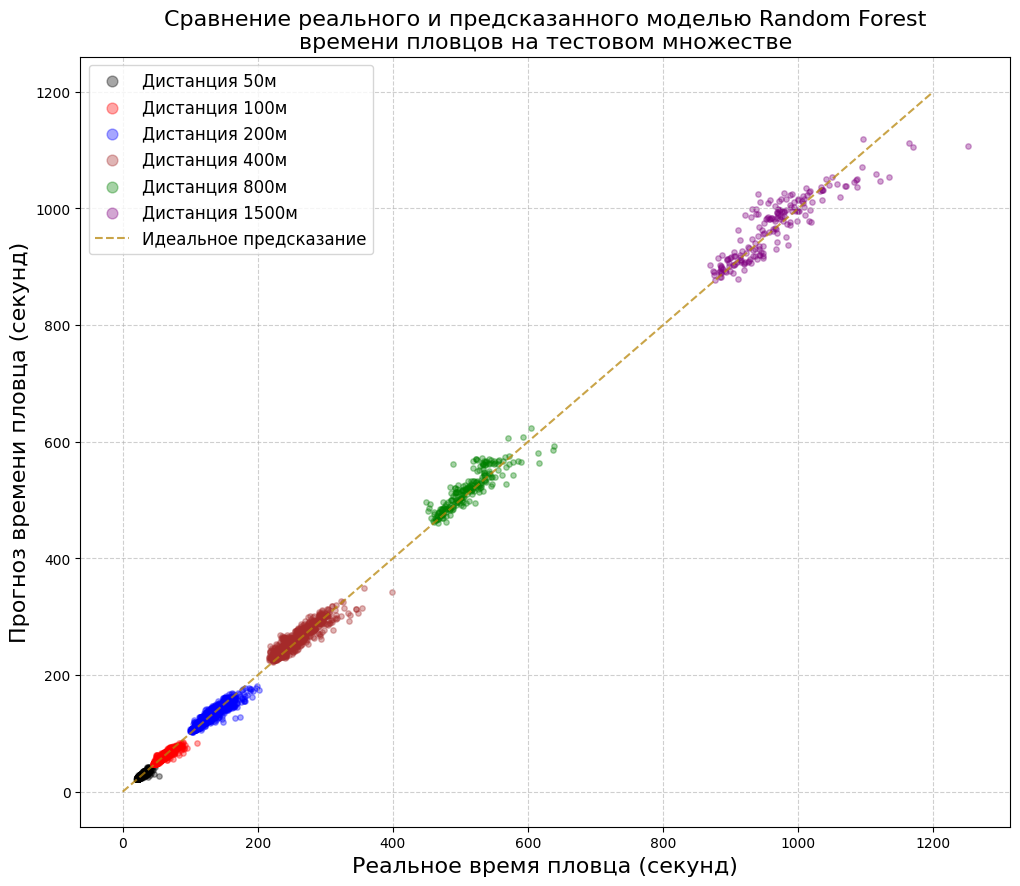

In [24]:
import matplotlib.pyplot as plt
import numpy as np


#Добавить цвета
colors=["black","red","blue","brown","green","purple"]

#Увеличить размер графика
plt.figure(figsize=(12, 10))

#Получить все дистанции в порядке возрастания
distances=sorted(X_test['distance'].unique())

for i in range(0,len(distances)):
    
    #Получить булеву маску элементов с данной дистанцией
    mask=(X_test['distance']==distances[i]).values

    #Строим на диаграмме рассеяния точки для данной дистанции
    plt.scatter(Y_test[mask], Y_pred_rf[mask], alpha=0.35, s=15, color=colors[i], label=f"Дистанция {distances[i]}м")

# Добавляем линию идеального предсказания (y = x)
plt.plot([0,1200], [0,1200], '--', color='darkgoldenrod',alpha=0.75, label='Идеальное предсказание')

plt.xlabel("Реальное время пловца (секунд)",fontsize=16)
plt.ylabel("Прогноз времени пловца (секунд)",fontsize=16)
plt.title("Сравнение реального и предсказанного моделью Random Forest\nвремени пловцов на тестовом множестве",fontsize=16)
plt.legend(fontsize=12, markerscale=2)  #Легенда
plt.grid(True, linestyle='--', alpha=0.6)  #Сетка координат
plt.show()

## Строим диаграмму рассеяния для XGBoost

In [25]:
from xgboost import XGBRegressor
#Заново обучим модель c лучшими гиперпараметрами для использования в диаграммах
xgbr_for_diagrams=Pipeline(steps=[('preprocessor',ColumnTransformer(transformers=[('select_only_numbers','passthrough',make_column_selector(dtype_include='number'))], #Берем только числовые признаки
                                                                remainder='drop')), #Остальные колонки игнорируем
                              ('regressor',XGBRegressor(random_state=11,n_jobs=-1, #Зафиксировать случайность и распараллелить на все ядра цпу
                                                                 #Вставляем найденные лучшие гиперпараметры
                                                                 n_estimators=600,
                                                                 max_depth=4,
                                                                 learning_rate=0.2,
                                                                 objective='reg:squarederror',
                                                                 subsample=0.8,
                                                                 colsample_bytree=1,
                                                                 reg_lambda=0.5,
                                                                 reg_alpha=0.5,
                                                                 gamma=0))]
                       )
xgbr_for_diagrams.fit(X_train_validation,Y_train_validation)

#Получим ожидаемые значения на тестовом множестве
Y_pred_xgbr=xgbr_for_diagrams.predict(X_test)

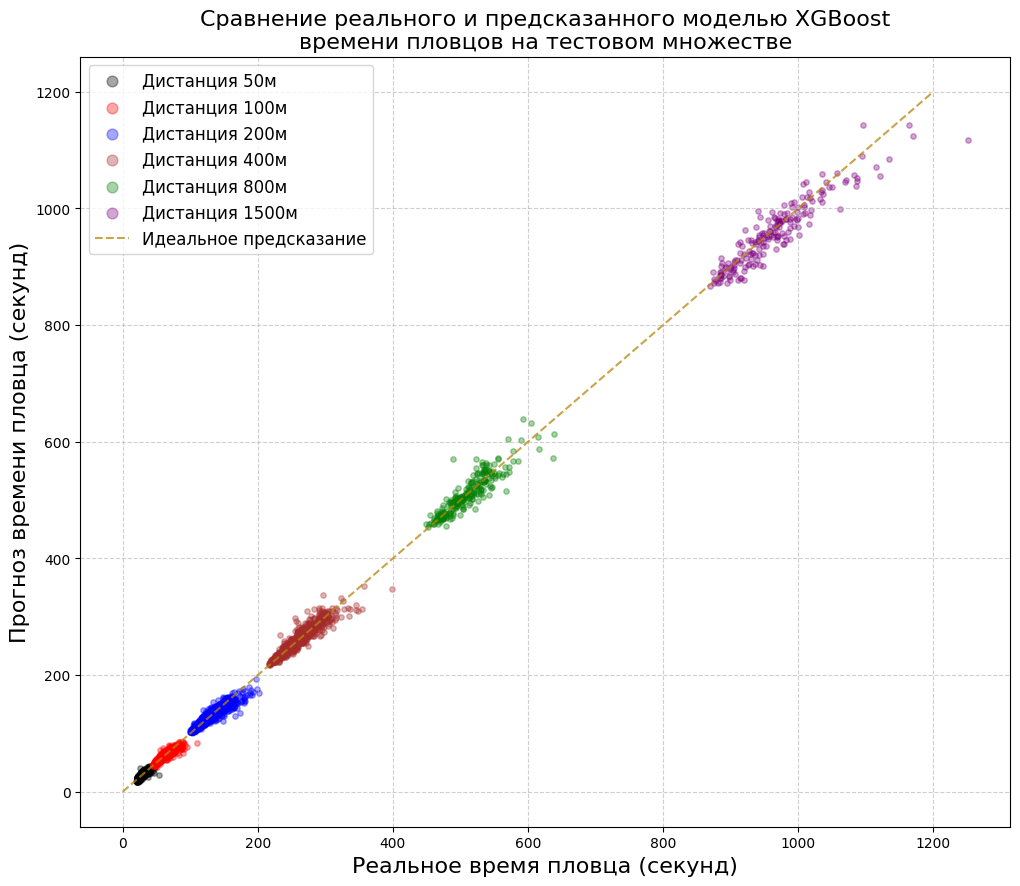

In [26]:
import matplotlib.pyplot as plt
import numpy as np


#Добавить цвета
colors=["black","red","blue","brown","green","purple"]

#Увеличить размер графика
plt.figure(figsize=(12, 10))

#Получить все дистанции в порядке возрастания
distances=sorted(X_test['distance'].unique())

for i in range(0,len(distances)):
    
    #Получить булеву маску элементов с данной дистанцией
    mask=(X_test['distance']==distances[i]).values

    #Строим на диаграмме рассеяния точки для данной дистанции
    plt.scatter(Y_test[mask], Y_pred_xgbr[mask], alpha=0.35, s=15, color=colors[i], label=f"Дистанция {distances[i]}м")

# Добавляем линию идеального предсказания (y = x)
plt.plot([0,1200], [0,1200], '--', color='darkgoldenrod',alpha=0.75, label='Идеальное предсказание')

plt.xlabel("Реальное время пловца (секунд)",fontsize=16)
plt.ylabel("Прогноз времени пловца (секунд)",fontsize=16)
plt.title("Сравнение реального и предсказанного моделью XGBoost\nвремени пловцов на тестовом множестве",fontsize=16)
plt.legend(fontsize=12, markerscale=2)  #Легенда
plt.grid(True, linestyle='--', alpha=0.6)  #Сетка координат
plt.show()

## Строим диаграмму рассеяния для MLP

In [27]:
from xgboost import XGBRegressor
#Возьмем уже обученную раннее модель
MLP_model_for_plot

#Получим ожидаемые значения на тестовом множестве
Y_pred_MLP=MLP_model_for_plot.predict(X_test)

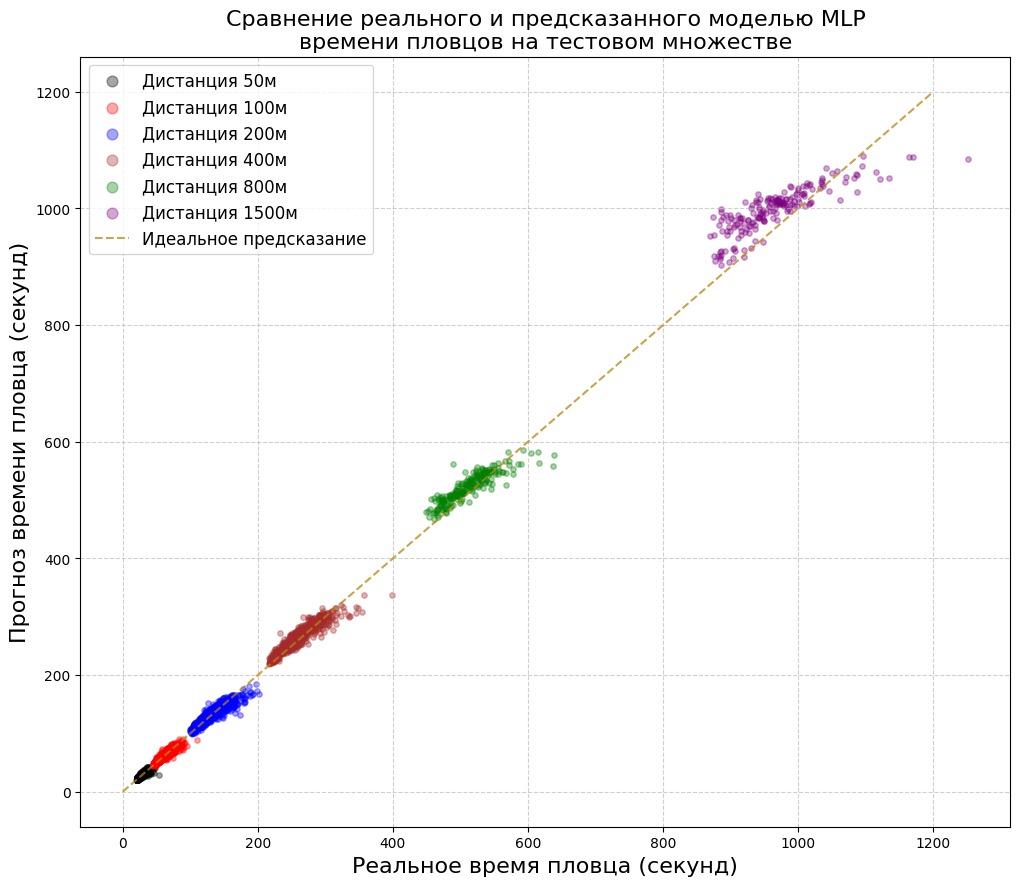

In [28]:
import matplotlib.pyplot as plt
import numpy as np


#Добавить цвета
colors=["black","red","blue","brown","green","purple"]

#Увеличить размер графика
plt.figure(figsize=(12, 10))

#Получить все дистанции в порядке возрастания
distances=sorted(X_test['distance'].unique())

for i in range(0,len(distances)):
    
    #Получить булеву маску элементов с данной дистанцией
    mask=(X_test['distance']==distances[i]).values

    #Строим на диаграмме рассеяния точки для данной дистанции
    plt.scatter(Y_test[mask], Y_pred_MLP[mask], alpha=0.35, s=15, color=colors[i], label=f"Дистанция {distances[i]}м")

# Добавляем линию идеального предсказания (y = x)
plt.plot([0,1200], [0,1200], '--', color='darkgoldenrod',alpha=0.75, label='Идеальное предсказание')

plt.xlabel("Реальное время пловца (секунд)",fontsize=16)
plt.ylabel("Прогноз времени пловца (секунд)",fontsize=16)
plt.title("Сравнение реального и предсказанного моделью MLP\nвремени пловцов на тестовом множестве",fontsize=16)
plt.legend(fontsize=12, markerscale=2)  #Легенда
plt.grid(True, linestyle='--', alpha=0.6)  #Сетка координат
plt.show()

## Строим диаграмму рассеяния для BiLSTM

In [29]:
from xgboost import XGBRegressor
#Возьмем уже обученную раннее модель
BiLSTM_model_for_plot

#Получим ожидаемые значения на тестовом множестве
Y_pred_BiLSTM=BiLSTM_model_for_plot.predict(X_test)

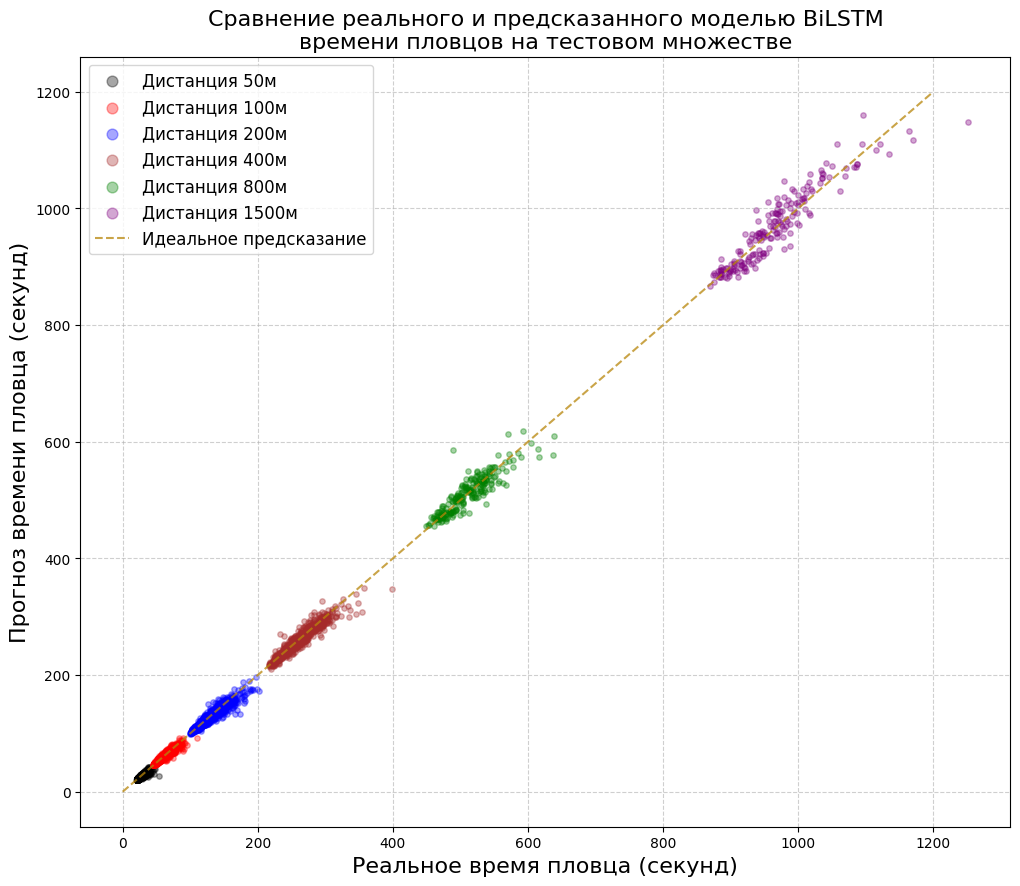

In [30]:
import matplotlib.pyplot as plt
import numpy as np

#Добавить цвета
colors=["black","red","blue","brown","green","purple"]

#Увеличить размер графика
plt.figure(figsize=(12, 10))

#Получить все дистанции в порядке возрастания
distances=sorted(X_test['distance'].unique())

for i in range(0,len(distances)):
    
    #Получить булеву маску элементов с данной дистанцией
    mask=(X_test['distance']==distances[i]).values

    #Строим на диаграмме рассеяния точки для данной дистанции
    plt.scatter(Y_test[mask], Y_pred_BiLSTM[mask], alpha=0.35, s=15, color=colors[i], label=f"Дистанция {distances[i]}м")

# Добавляем линию идеального предсказания (y = x)
plt.plot([0,1200], [0,1200], '--', color='darkgoldenrod',alpha=0.75, label='Идеальное предсказание')

plt.xlabel("Реальное время пловца (секунд)",fontsize=16)
plt.ylabel("Прогноз времени пловца (секунд)",fontsize=16)
plt.title("Сравнение реального и предсказанного моделью BiLSTM\nвремени пловцов на тестовом множестве",fontsize=16)
plt.legend(fontsize=12, markerscale=2)  #Легенда
plt.grid(True, linestyle='--', alpha=0.6)  #Сетка координат
plt.show()

# Строим диаграммы для сравнения метрик разных моделей на разных дистанциях

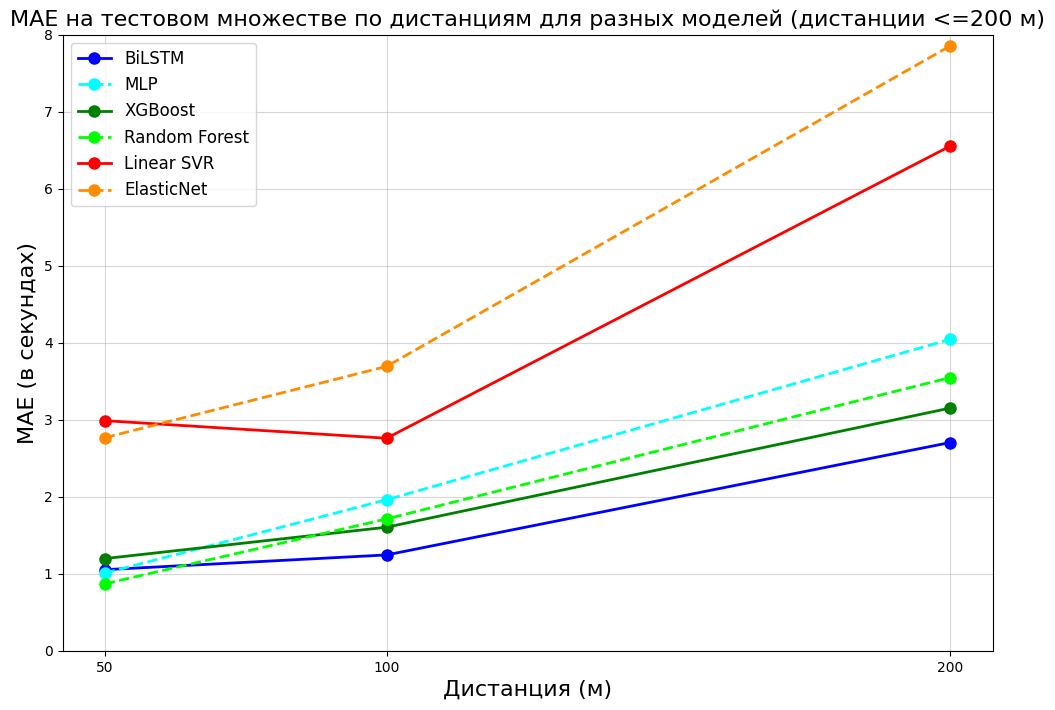

In [31]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

distances = sorted(X_test[X_test['distance']<=200]['distance'].unique())  #Поиск всех имеющихся дистанций

#Определяем модели и записываем их предсказания в словарь
models = {
    "BiLSTM": Y_pred_BiLSTM,
    "MLP": Y_pred_MLP,
    "XGBoost": Y_pred_xgbr,
    "Random Forest": Y_pred_rf,
    "Linear SVR": Y_pred_linear_SVR,
    "ElasticNet": Y_pred_en
}

colors = ["blue", "cyan", "green", "lime", "red", "darkorange"]
lines=['-','--','-','--','-','--']

#Посчитать MAE для каждой модели для каждой дистанции
mae_by_model = {}
for model_name, Y_pred in models.items():
    mae_by_model[model_name] = []
    for dist in distances:
        
        
        #Получить булеву маску элементов с данной дистанцией
        mask = (X_test['distance'] == dist).values
        
        #Добавляем в массив метрик MAE для данной модели
        mae = mean_absolute_error(Y_test[mask], Y_pred[mask])
        mae_by_model[model_name].append(mae)

#Строим график
plt.figure(figsize=(12, 8))

for i, (model_name, mae) in enumerate(mae_by_model.items()):
    plt.plot(distances, mae, color=colors[i], label=model_name, marker='o', linestyle=lines[i], linewidth=2, markersize=8)


plt.xlabel("Дистанция (м)", fontsize=16)
plt.ylabel("MAE (в секундах)", fontsize=16)
plt.title("MAE на тестовом множестве по дистанциям для разных моделей (дистанции <=200 м)", fontsize=16)
plt.xticks(distances, distances)
plt.ylim((0,8))
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

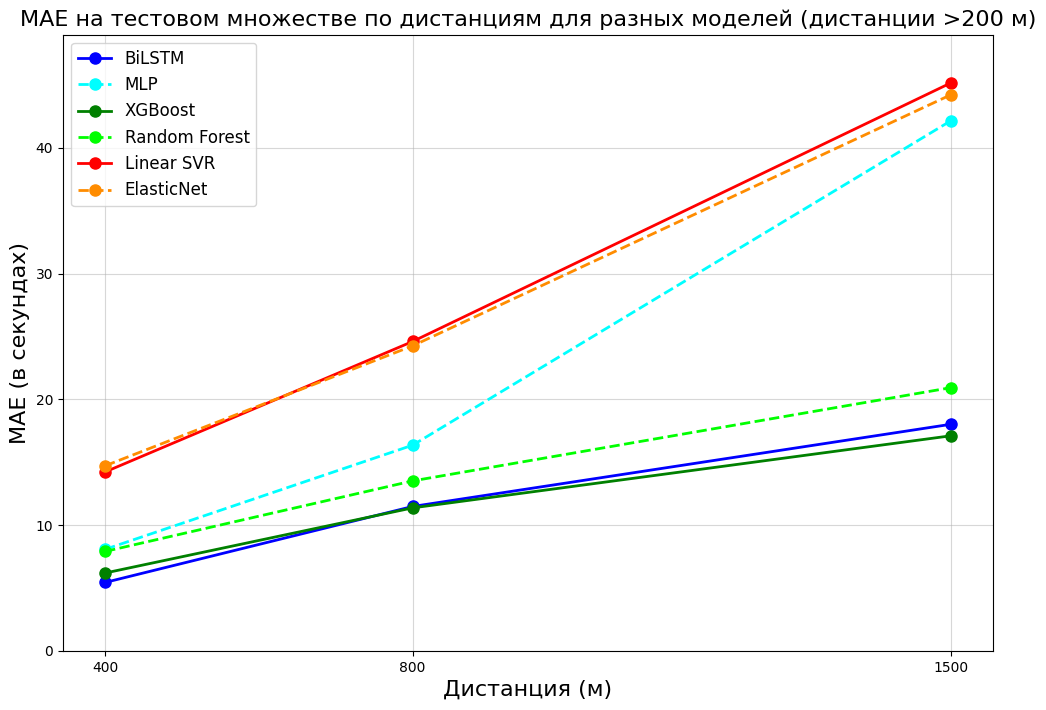

In [32]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

distances = sorted(X_test[X_test['distance']>200]['distance'].unique())  #Поиск всех имеющихся дистанций

#Определяем модели и записываем их предсказания в словарь
models = {
    "BiLSTM": Y_pred_BiLSTM,
    "MLP": Y_pred_MLP,
    "XGBoost": Y_pred_xgbr,
    "Random Forest": Y_pred_rf,
    "Linear SVR": Y_pred_linear_SVR,
    "ElasticNet": Y_pred_en
}

colors = ["blue", "cyan", "green", "lime", "red", "darkorange"]
lines=['-','--','-','--','-','--']

#Посчитать MAE для каждой модели для каждой дистанции
mae_by_model = {}
for model_name, Y_pred in models.items():
    mae_by_model[model_name] = []
    for dist in distances:
        
        
        #Получить булеву маску элементов с данной дистанцией
        mask = (X_test['distance'] == dist).values
        
        #Добавляем в массив метрик MAE для данной модели
        mae = mean_absolute_error(Y_test[mask], Y_pred[mask])
        mae_by_model[model_name].append(mae)

#Строим график
plt.figure(figsize=(12, 8))

for i, (model_name, mae) in enumerate(mae_by_model.items()):
    plt.plot(distances, mae, color=colors[i], label=model_name, marker='o', linestyle=lines[i], linewidth=2, markersize=8)


plt.xlabel("Дистанция (м)", fontsize=16)
plt.ylabel("MAE (в секундах)", fontsize=16)
plt.title("MAE на тестовом множестве по дистанциям для разных моделей (дистанции >200 м)", fontsize=16)
plt.xticks(distances, distances)
plt.ylim((0,49))
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

In [33]:
print(X_test['distance'].value_counts().sort_index())

distance
50      3035
100     3110
200     2630
400      756
800      219
1500     185
Name: count, dtype: int64


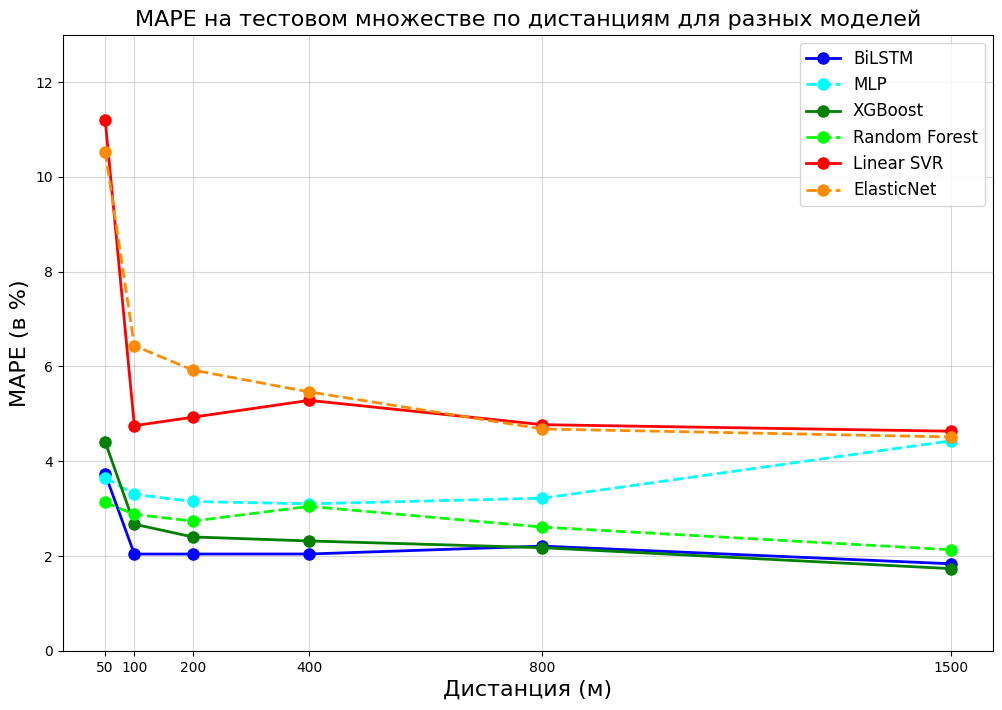

In [34]:
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np

distances = sorted(X_test['distance'].unique())  #Поиск всех имеющихся дистанций

#Определяем модели и записываем их предсказания в словарь
models = {
    "BiLSTM": Y_pred_BiLSTM,
    "MLP": Y_pred_MLP,
    "XGBoost": Y_pred_xgbr,
    "Random Forest": Y_pred_rf,
    "Linear SVR": Y_pred_linear_SVR,
    "ElasticNet": Y_pred_en
}

colors = ["blue", "cyan", "green", "lime", "red", "darkorange"]
lines=['-','--','-','--','-','--']

#Посчитать MAPE для каждой модели для каждой дистанции
mape_by_model = {}
for model_name, Y_pred in models.items():
    mape_by_model[model_name] = []
    for dist in distances:
        
        #Получить булеву маску элементов с данной дистанцией
        mask = (X_test['distance'] == dist).values
        
        #Добавляем в массив метрик MAPE для данной модели
        mape = mean_absolute_percentage_error(Y_test[mask], Y_pred[mask])*100
        mape_by_model[model_name].append(mape)

#Строим график
plt.figure(figsize=(12, 8))

for i, (model_name, mape) in enumerate(mape_by_model.items()):
    plt.plot(distances, mape, color=colors[i], label=model_name, marker='o', linestyle=lines[i], linewidth=2, markersize=8)


plt.xlabel("Дистанция (м)", fontsize=16)
plt.ylabel("MAPE (в %)", fontsize=16)
plt.title("MAPE на тестовом множестве по дистанциям для разных моделей", fontsize=16)
plt.xticks(distances,distances)
plt.ylim((0,13))
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

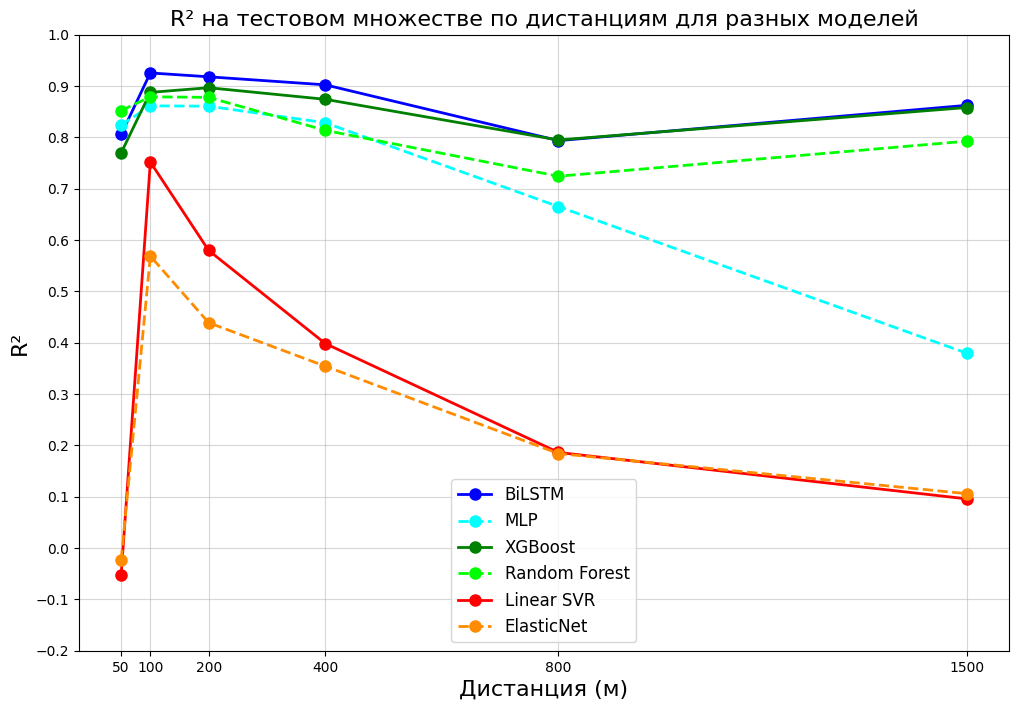

In [35]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

distances = sorted(X_test['distance'].unique())  #Поиск всех имеющихся дистанций

#Определяем модели и записываем их предсказания в словарь
models = {
    "BiLSTM": Y_pred_BiLSTM,
    "MLP": Y_pred_MLP,
    "XGBoost": Y_pred_xgbr,
    "Random Forest": Y_pred_rf,
    "Linear SVR": Y_pred_linear_SVR,
    "ElasticNet": Y_pred_en
}

colors = ["blue", "cyan", "green", "lime", "red", "darkorange"]
lines=['-','--','-','--','-','--']

#Посчитать R^2 для каждой модели для каждой дистанции
r2_by_model = {}
for model_name, Y_pred in models.items():
    r2_by_model[model_name] = []
    for dist in distances:
        
        #Получить булеву маску элементов с данной дистанцией
        mask = (X_test['distance'] == dist).values
        
        #Добавляем в массив метрик R^2 для данной модели
        r2 = r2_score(Y_test[mask], Y_pred[mask])
        r2_by_model[model_name].append(r2)

#Строим график
plt.figure(figsize=(12, 8))

for i, (model_name, r2s) in enumerate(r2_by_model.items()):
    plt.plot(distances, r2s, color=colors[i], label=model_name, marker='o', linestyle=lines[i], linewidth=2, markersize=8)

plt.yticks([i*0.1 for i in range(-2,11,1)])
plt.xlabel("Дистанция (м)", fontsize=16)
plt.ylabel("R²", fontsize=16)
plt.title("R² на тестовом множестве по дистанциям для разных моделей", fontsize=16)
plt.xticks(distances, distances)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

# Проведение ablation study для BiLSTM

## Описание всех необходимых функций и классов

In [ ]:
from tensorflow.keras.regularizers import l1_l2
from keras import layers
from keras import activations
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from functools import partial
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.metrics import R2Score
from scikeras.wrappers import KerasRegressor
from random import seed
from os import environ
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Masking,Bidirectional,LSTM,Dense,Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from numpy.lib.stride_tricks import sliding_window_view
import tensorflow as tf
import numpy as np
import joblib




#Класс для преобразования таргета
class TargetTrasnsformer_Log_Standard_or_None(BaseEstimator, TransformerMixin):
    def __init__(self, method='none'):
        super().__init__()
        self.method = method

    def fit(self, y, X=None):
        if self.method == 'standard':
            #Делаем reshape, т.к. StandardScaler ожидает 2D
            self.scaler_ = StandardScaler().fit(np.asarray(y).reshape(-1, 1))
        return self

    def transform(self, y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method == 'log':
            return np.log(np.clip(y, 1e-9, None)).ravel()
        elif self.method == 'standard':
            return self.scaler_.transform(y).ravel()
        elif self.method == 'none':
            return y.ravel()
        else:
            raise ValueError("Недопустимое значение типа преобразования целевой переменной! Возможные значения: ['none','log','standard']")

    def inverse_transform(self, y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method == 'log':
            return np.exp(y).ravel()
        elif self.method == 'standard':
            return self.scaler_.inverse_transform(y).ravel()
        elif self.method == 'none':
            return y.ravel()
        else:
            raise ValueError("Недопустимое значение типа преобразования целевой переменной! Возможные значения: ['none','log','standard']")



#Класс для нормализации входных признаков и переделки их в формат, подходящий на вход к BiLSTM
class SequenceStandardScalerForBiLSTM(BaseEstimator, TransformerMixin):
    def __init__(self,
                 window_size=5,                           #Размер окна для последовательности
                 ):
        self.window_size = window_size                
        self.is_train_data_transformed=False             #Флаг, показывает, были ли преобразованы тренировочные данные через transform
        
    #Вернуть только те колонки датафрейма, которые не являются строками или объектами
    def _get_required_columns_from_dataset(self, X):
        return X.select_dtypes(include='number').columns.tolist()

    def fit(self, X, y=None):
        #Обучаем StandardScaler для признаков на тренировочном датасете
        self.feature_cols = self._get_required_columns_from_dataset(X)
        self.scaler_ = StandardScaler().fit(X[self.feature_cols])     
        self.is_train_data_transformed = False

        return self

    def transform(self, X):
        if not self.is_train_data_transformed:  #На train данных
            X_scaled = X.copy()
        
            #Получить углы дня года и времени в секундах дня - для сортировки записей в хронологическом порядке
            X_scaled['_doy_angle'] = np.arctan2(X['race_doy_sin'], X['race_doy_cos']) % (2 * np.pi)
            X_scaled['_time_angle'] = np.arctan2(X['race_time_seconds_sin'], X['race_time_seconds_cos']) % (2 * np.pi)
            
            #Преобразуем значения внутри датафрейма согласно StandardScaler
            X_scaled[self.feature_cols] = self.scaler_.transform(X[self.feature_cols])
            
            X_scaled['_original_idx'] = np.arange(len(X))  
            
            #Сортируем датафрейм сначала по ИД пловца, затем по году заплыва, затем по углу дня года, затем по углу времени дня
            X_scaled = X_scaled.sort_values(by=['swimmer_id', 'race_year', '_doy_angle', '_time_angle'])
            
            #Есть проблема, что не у всех строк в датасете было время (оно было импутировано для некоторых значений).
            #Однако дата есть у всех строк. В целом же погрешность времени в течении дня не должно сильно влиять на производительность модели
            
            
            #Выходной 3D массив на вход к модели
            sequences = np.zeros((len(X), self.window_size, len(self.feature_cols)), dtype=np.float32)
            
            #Получаем последовательности для обучения BiLSTM и сохраняем 
            self.swimmer_history = {}            
            for swimmer_id, group in X_scaled.groupby('swimmer_id', sort=False):
                X_for_1_swimmer = group[self.feature_cols].values.astype(np.float32)                      #Отсортированный массив результатов одного пловца
                paddings=np.full((self.window_size-1, len(self.feature_cols)), -999.0, dtype=np.float32)  #(windows_size-1,n_features)
                swimmer_history_sequence=np.vstack([paddings,X_for_1_swimmer])                             #(len(X_for_1_swimmer)+windows_size-1,n_features) 
                original_indices = group['_original_idx'].values                              
                
                windows = sliding_window_view(swimmer_history_sequence, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),n_features,windows_size)
                
                #Переставить местами два измерения массива, так как BiLSTM ожидает массив размерности (batch,timesteps,n_features)
                windows = np.swapaxes(windows, 1, 2) #(len(X_for_1_swimmer),windows_size,n_features)
                
                #Присваиваем результирующие последовательности для обучения BiLSTM внутрь выходного 3Д массива
                sequences[original_indices] = windows 
                
                self.swimmer_history[swimmer_id] = X_for_1_swimmer[-(self.window_size - 1):]      #Сохраняем последние записи пловца в историю
                
            self.is_train_data_transformed=True
            return sequences
        else:   #На test/validation данных
            X_scaled = X.copy()
        
            #Получить углы дня года и времени в секундах дня - для сортировки записей в хронологическом порядке
            X_scaled['_doy_angle'] = np.arctan2(X['race_doy_sin'], X['race_doy_cos']) % (2 * np.pi)
            X_scaled['_time_angle'] = np.arctan2(X['race_time_seconds_sin'], X['race_time_seconds_cos']) % (2 * np.pi)
            
            #Преобразуем значения внутри датафрейма согласно StandardScaler
            X_scaled[self.feature_cols] = self.scaler_.transform(X[self.feature_cols])
            
            X_scaled['_original_idx'] = np.arange(len(X)) 
            
            #Сортируем датафрейм сначала по ИД пловца, затем по году заплыва, затем по углу дня года, затем по углу времени дня
            X_scaled = X_scaled.sort_values(by=['swimmer_id', 'race_year', '_doy_angle', '_time_angle'])
                                   
            #Выходной 3D массив на вход к модели
            sequences = np.zeros((len(X), self.window_size, len(self.feature_cols)), dtype=np.float32)
            
            #Получаем последовательности для обучения BiLSTM и сохраняем             
            for swimmer_id, group in X_scaled.groupby('swimmer_id', sort=False):
                X_for_1_swimmer = group[self.feature_cols].values.astype(np.float32)                      #Отсортированный массив результатов одного пловца
                
                #Пытаемся получить историю пловца
                history = self.swimmer_history.get(
                    swimmer_id,
                    np.zeros((0, len(self.feature_cols)), dtype=np.float32)
                )
                
                padding_size=max(0,self.window_size-1-len(history))  #Размер паддинга слева значениями -999
                
                #Строим массив последовательностей
                swimmer_sequences=None
                if padding_size>0:
                    paddings=np.full((padding_size, len(self.feature_cols)), -999.0, dtype=np.float32)   #(padding_size,n_features)
                    swimmer_sequences=np.vstack([paddings,history,X_for_1_swimmer])                     #(len(X_for_1_swimmer)+windows_size-1,n_features)
                else:
                    swimmer_sequences=np.vstack([history,X_for_1_swimmer])                     #(len(X_for_1_swimmer)+windows_size-1,n_features)
                original_indices = group['_original_idx'].values                              
                
                windows = sliding_window_view(swimmer_sequences, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),n_features,windows_size)
                
                #Переставить местами два измерения массива, так как BiLSTM ожидает массив размерности (batch,timesteps,n_features)
                windows = np.swapaxes(windows, 1, 2) #(len(X_for_1_swimmer),windows_size,n_features)
                
                #Присваиваем результирующие последовательности для обучения BiLSTM внутрь выходного 3Д массива
                sequences[original_indices] = windows               
                
            return sequences

## LSTM

In [37]:
#Описание модели
def build_model_ablation_LSTM(meta,
                                   num_bilstm_layers=1,
                                   lstm_units_in_layer=16,
                                   num_dense_io_layers=1,
                                   dense_neurons_in_layer=32,
                                   activation_function='leaky_relu',
                                   dropout_rate=0,
                                   learning_rate=0.001,
                                   loss_function='mse'):

    tf.random.set_seed(SEED)

    input_shape = meta["X_shape_"][1:]  #Получаем размерность входных данных (будет кортеж (число элементов в 1 временной последовательности,число признаков))

    model = Sequential()
    tf.random.set_seed(SEED);model.add(Input(shape=input_shape))
    
    #Значения, маскированные -999 (пустые значения, которыми слева заполнялись последовательности внутри BiLSTM) будут игнорироваться при обучении
    tf.random.set_seed(SEED);model.add(Masking(mask_value=-999.0))
    
    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))


    for i in range(num_bilstm_layers):
        if i<num_bilstm_layers-1:        
            tf.random.set_seed(SEED);model.add(LSTM(lstm_units_in_layer, return_sequences=True))  #На выходе - 3d тензор. Передаем его для следующего LSTM слоя
        else:
            tf.random.set_seed(SEED);model.add(LSTM(lstm_units_in_layer, return_sequences=False)) #На выходе - 2d тензор. Передаем его для полносвязного слоя
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    tf.random.set_seed(SEED);model.add(Dense(1, activation='linear'))

    tf.random.set_seed(SEED);model.compile(optimizer=Adam(learning_rate=learning_rate),loss=loss_function, metrics=['mean_absolute_error', 'mean_absolute_percentage_error', 'r2_score'])
    return model

In [38]:
#Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'

ablation_LSTM=Pipeline(steps=[
        ('preprocessor', SequenceStandardScalerForBiLSTM(window_size=7)),  
        ('regressor', TransformedTargetRegressor(
            regressor=KerasRegressor(
                model=build_model_ablation_LSTM,
                verbose=0,
                activation_function='leaky_relu',
                batch_size=128,
                dense_neurons_in_layer=64,
                dropout_rate=0.1,
                epochs=25,
                learning_rate=0.001,
                loss_function='mae',
                lstm_units_in_layer=128,
                num_bilstm_layers=2,
                num_dense_io_layers=0,
                random_state=SEED
            ),
            transformer=TargetTrasnsformer_Log_Standard_or_None(method='standard')
        ))
    ])

ablation_LSTM.fit(X_train_validation,Y_train_validation)

Y_ablation_LSTM_pred=ablation_LSTM.predict(X_test)

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(


In [39]:
#Выводим метрики MAE, MAPE, r^2
print("MAE на тесте у модели LSTM в ходе ablation study:", mean_absolute_error(Y_test, Y_ablation_LSTM_pred), sep="")
print("MAPE на тесте у модели LSTM в ходе ablation study:", mean_absolute_percentage_error(Y_test, Y_ablation_LSTM_pred) * 100, "%", sep="")
print("R^2 на тесте у модели LSTM в ходе ablation study:", r2_score(Y_test, Y_ablation_LSTM_pred), sep="")

MAE на тесте у модели LSTM в ходе ablation study:3.4096132424694843
MAPE на тесте у модели LSTM в ходе ablation study:3.6819967906084305%
R^2 на тесте у модели LSTM в ходе ablation study:0.9976257626739521


## LSTM x2 LSTM ячеек

In [40]:
#Описание модели
def build_model_ablation_LSTM_x2_LSTM_units(meta,
                                   num_bilstm_layers=1,
                                   lstm_units_in_layer=16,
                                   num_dense_io_layers=1,
                                   dense_neurons_in_layer=32,
                                   activation_function='leaky_relu',
                                   dropout_rate=0,
                                   learning_rate=0.001,
                                   loss_function='mse'):

    tf.random.set_seed(SEED)

    input_shape = meta["X_shape_"][1:]  #Получаем размерность входных данных (будет кортеж (число элементов в 1 временной последовательности,число признаков))

    model = Sequential()
    tf.random.set_seed(SEED);model.add(Input(shape=input_shape))
    
    #Значения, маскированные -999 (пустые значения, которыми слева заполнялись последовательности внутри BiLSTM) будут игнорироваться при обучении
    tf.random.set_seed(SEED);model.add(Masking(mask_value=-999.0))
    
    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))


    for i in range(num_bilstm_layers):
        if i<num_bilstm_layers-1:        
            tf.random.set_seed(SEED);model.add(LSTM(lstm_units_in_layer, return_sequences=True))  #На выходе - 3d тензор. Передаем его для следующего LSTM слоя
        else:
            tf.random.set_seed(SEED);model.add(LSTM(lstm_units_in_layer, return_sequences=False)) #На выходе - 2d тензор. Передаем его для полносвязного слоя
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    tf.random.set_seed(SEED);model.add(Dense(1, activation='linear'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),loss=loss_function, metrics=['mean_absolute_error', 'mean_absolute_percentage_error', 'r2_score'])
    return model

In [ ]:
#Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'

ablation_LSTM_x2_LSTM_units=Pipeline(steps=[
        ('preprocessor', SequenceStandardScalerForBiLSTM(window_size=7)),  
        ('regressor', TransformedTargetRegressor(
            regressor=KerasRegressor(
                model=build_model_ablation_LSTM_x2_LSTM_units,
                verbose=1,
                activation_function='leaky_relu',
                batch_size=128,
                dense_neurons_in_layer=64,
                dropout_rate=0.1,
                epochs=25,
                learning_rate=0.001,
                loss_function='mae',
                lstm_units_in_layer=256, #В два раза больше
                num_bilstm_layers=2,
                num_dense_io_layers=0,
                random_state=SEED
            ),
            transformer=TargetTrasnsformer_Log_Standard_or_None(method='standard')
        ))
    ])

ablation_LSTM_x2_LSTM_units.fit(X_train_validation,Y_train_validation)

Y_ablation_LSTM_x2_LSTM_units_pred=ablation_LSTM_x2_LSTM_units.predict(X_test)

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(


In [42]:
#Выводим метрики MAE, MAPE, r^2
print("MAE на тесте у модели LSTM с два раза большим числом LSTM ячеек в ходе ablation study:", mean_absolute_error(Y_test, Y_ablation_LSTM_x2_LSTM_units_pred), sep="")
print("MAPE на тесте у модели LSTM с два раза большим числом LSTM ячеек  в ходе ablation study:", mean_absolute_percentage_error(Y_test, Y_ablation_LSTM_x2_LSTM_units_pred) * 100, "%", sep="")
print("R^2 на тесте у модели LSTM с два раза большим числом LSTM ячеек в ходе ablation study:", r2_score(Y_test, Y_ablation_LSTM_x2_LSTM_units_pred), sep="")

MAE на тесте у модели LSTM с два раза большим числом LSTM ячеек в ходе ablation study:2.7408331817181555
MAPE на тесте у модели LSTM с два раза большим числом LSTM ячеек  в ходе ablation study:2.527651969161519%
R^2 на тесте у модели LSTM с два раза большим числом LSTM ячеек в ходе ablation study:0.9984528470518214


## Без эмбеддингов

In [43]:
#Описание модели
def build_model_ablation_no_embeddings(meta,
                                   num_bilstm_layers=1,
                                   lstm_units_in_layer=16,
                                   num_dense_io_layers=1,
                                   dense_neurons_in_layer=32,
                                   activation_function='leaky_relu',
                                   dropout_rate=0,
                                   learning_rate=0.001,
                                   loss_function='mse'):

    tf.random.set_seed(SEED)

    input_shape = meta["X_shape_"][1:]  #Получаем размерность входных данных (будет кортеж (число элементов в 1 временной последовательности,число признаков))

    model = Sequential()
    tf.random.set_seed(SEED);model.add(Input(shape=input_shape))
    
    #Значения, маскированные -999 (пустые значения, которыми слева заполнялись последовательности внутри BiLSTM) будут игнорироваться при обучении
    tf.random.set_seed(SEED);model.add(Masking(mask_value=-999.0))
    
    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))
    


    for i in range(num_bilstm_layers):
        if i<num_bilstm_layers-1:        
            tf.random.set_seed(SEED);model.add(Bidirectional(LSTM(lstm_units_in_layer, return_sequences=True)))  #На выходе - 3d тензор. Передаем его для следующего BiLSTM слоя
        else:
            tf.random.set_seed(SEED);model.add(Bidirectional(LSTM(lstm_units_in_layer, return_sequences=False))) #На выходе - 2d тензор. Передаем его для FC слоя
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    tf.random.set_seed(SEED);model.add(Dense(1, activation='linear'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),loss=loss_function, metrics=['mean_absolute_error', 'mean_absolute_percentage_error', 'r2_score'])
    return model

In [44]:
#Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'

ablation_no_embeddings=Pipeline(steps=[
        ('preprocessor', SequenceStandardScalerForBiLSTM(window_size=7)),  
        ('regressor', TransformedTargetRegressor(
            regressor=KerasRegressor(
                model=build_model_ablation_no_embeddings,
                verbose=0,
                activation_function='leaky_relu',
                batch_size=128,
                dense_neurons_in_layer=64,
                dropout_rate=0.1,
                epochs=25,
                learning_rate=0.001,
                loss_function='mae',
                lstm_units_in_layer=128,
                num_bilstm_layers=2,
                num_dense_io_layers=0,
                random_state=SEED
            ),
            transformer=TargetTrasnsformer_Log_Standard_or_None(method='standard')
        ))
    ])

ablation_no_embeddings.fit(X_train_validation.drop(columns=['swimmer_country_0','swimmer_country_1',	'swimmer_country_2',	'swimmer_country_3',	'swimmer_country_4',	'swimmer_country_5',	'swimmer_country_6',	'swimmer_country_7',	'host_country_0',	'host_country_1',	'host_country_2',	'host_country_3',	'host_country_4',	'host_country_5',	'host_country_6',	'host_country_7',	'swimmer_id_0',	'swimmer_id_1',	'swimmer_id_2',	'swimmer_id_3',	'swimmer_id_4',	'swimmer_id_5',	'swimmer_id_6',	'swimmer_id_7',	'swimmer_id_8',	'swimmer_id_9',	'swimmer_id_10',	'swimmer_id_11',	'swimmer_id_12',	'swimmer_id_13',	'swimmer_id_14',	'swimmer_id_15']),
                           Y_train_validation)

Y_ablation_no_embeddings_pred=ablation_no_embeddings.predict(X_test.drop(columns=['swimmer_country_0','swimmer_country_1',	'swimmer_country_2',	'swimmer_country_3',	'swimmer_country_4',	'swimmer_country_5',	'swimmer_country_6',	'swimmer_country_7',	'host_country_0',	'host_country_1',	'host_country_2',	'host_country_3',	'host_country_4',	'host_country_5',	'host_country_6',	'host_country_7',	'swimmer_id_0',	'swimmer_id_1',	'swimmer_id_2',	'swimmer_id_3',	'swimmer_id_4',	'swimmer_id_5',	'swimmer_id_6',	'swimmer_id_7',	'swimmer_id_8',	'swimmer_id_9',	'swimmer_id_10',	'swimmer_id_11',	'swimmer_id_12',	'swimmer_id_13',	'swimmer_id_14',	'swimmer_id_15']))

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(


In [45]:
#Выводим метрики MAE, MAPE, r^2
print("MAE на тесте у модели без эмбеддингов в ходе ablation study:", mean_absolute_error(Y_test, Y_ablation_no_embeddings_pred), sep="")
print("MAPE на тесте у модели без эмбеддингов в ходе ablation study:", mean_absolute_percentage_error(Y_test, Y_ablation_no_embeddings_pred) * 100, "%", sep="")
print("R^2 на тесте у модели без эмбеддингов в ходе ablation study:", r2_score(Y_test, Y_ablation_no_embeddings_pred), sep="")

MAE на тесте у модели без эмбеддингов в ходе ablation study:2.477294105042149
MAPE на тесте у модели без эмбеддингов в ходе ablation study:2.362654235858823%
R^2 на тесте у модели без эмбеддингов в ходе ablation study:0.9985151186903083


## Изначальный BiLSTM

In [46]:
#Описание модели
def build_model_ablation_original_BiLSTM(meta,
                                   num_bilstm_layers=1,
                                   lstm_units_in_layer=16,
                                   num_dense_io_layers=1,
                                   dense_neurons_in_layer=32,
                                   activation_function='leaky_relu',
                                   dropout_rate=0,
                                   learning_rate=0.001,
                                   loss_function='mse'):

    tf.random.set_seed(SEED)

    input_shape = meta["X_shape_"][1:]  #Получаем размерность входных данных (будет кортеж (число элементов в 1 временной последовательности,число признаков))

    model = Sequential()
    tf.random.set_seed(SEED);model.add(Input(shape=input_shape))
    
    #Значения, маскированные -999 (пустые значения, которыми слева заполнялись последовательности внутри BiLSTM) будут игнорироваться при обучении
    tf.random.set_seed(SEED);model.add(Masking(mask_value=-999.0))
    
    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))


    for i in range(num_bilstm_layers):
        if i<num_bilstm_layers-1:        
            tf.random.set_seed(SEED);model.add(Bidirectional(LSTM(lstm_units_in_layer, return_sequences=True)))  #На выходе - 3d тензор. Передаем его для следующего BiLSTM слоя
        else:
            tf.random.set_seed(SEED);model.add(Bidirectional(LSTM(lstm_units_in_layer, return_sequences=False))) #На выходе - 2d тензор. Передаем его для полносвязного слоя
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    tf.random.set_seed(SEED);model.add(Dense(1, activation='linear'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),loss=loss_function, metrics=['mean_absolute_error', 'mean_absolute_percentage_error', 'r2_score'])
    return model

In [47]:
#Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'

ablation_original_BiLSTM=Pipeline(steps=[
        ('preprocessor', SequenceStandardScalerForBiLSTM(window_size=7)),  
        ('regressor', TransformedTargetRegressor(
            regressor=KerasRegressor(
                model=build_model_ablation_original_BiLSTM,
                verbose=0,
                activation_function='leaky_relu',
                batch_size=128,
                dense_neurons_in_layer=64,
                dropout_rate=0.1,
                epochs=25,
                learning_rate=0.001,
                loss_function='mae',
                lstm_units_in_layer=128,
                num_bilstm_layers=2,
                num_dense_io_layers=0,
                random_state=SEED
            ),
            transformer=TargetTrasnsformer_Log_Standard_or_None(method='standard')
        ))
    ])

ablation_original_BiLSTM.fit(X_train_validation,
                           Y_train_validation)

Y_ablation_original_BiLSTM_pred=ablation_original_BiLSTM.predict(X_test)

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(


In [48]:
#Выводим метрики MAE, MAPE, r^2
print("MAE на тесте у исходной модели BiLSTM в ходе ablation study:", mean_absolute_error(Y_test, Y_ablation_original_BiLSTM_pred), sep="")
print("MAPE на тесте у исходной модели BiLSTM в ходе ablation study:", mean_absolute_percentage_error(Y_test, Y_ablation_original_BiLSTM_pred) * 100, "%", sep="")
print("R^2 на тесте у исходной модели BiLSTM в ходе ablation study:", r2_score(Y_test, Y_ablation_original_BiLSTM_pred), sep="")

MAE на тесте у исходной модели BiLSTM в ходе ablation study:2.428381017369125
MAPE на тесте у исходной модели BiLSTM в ходе ablation study:2.5564931427470365%
R^2 на тесте у исходной модели BiLSTM в ходе ablation study:0.9987872328642546


## Без эмбеддингов id пловца

In [49]:
#Описание модели
def build_model_ablation_no_embeddings_for_swimmer_id(meta,
                                   num_bilstm_layers=1,
                                   lstm_units_in_layer=16,
                                   num_dense_io_layers=1,
                                   dense_neurons_in_layer=32,
                                   activation_function='leaky_relu',
                                   dropout_rate=0,
                                   learning_rate=0.001,
                                   loss_function='mse'):

    tf.random.set_seed(SEED)

    input_shape = meta["X_shape_"][1:]  #Получаем размерность входных данных (будет кортеж (число элементов в 1 временной последовательности,число признаков))

    model = Sequential()
    tf.random.set_seed(SEED);model.add(Input(shape=input_shape))
    
    #Значения, маскированные -999 (пустые значения, которыми слева заполнялись последовательности внутри BiLSTM) будут игнорироваться при обучении
    tf.random.set_seed(SEED);model.add(Masking(mask_value=-999.0))
    
    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))
    


    for i in range(num_bilstm_layers):
        if i<num_bilstm_layers-1:        
            tf.random.set_seed(SEED);model.add(Bidirectional(LSTM(lstm_units_in_layer, return_sequences=True)))  #На выходе - 3d тензор. Передаем его для следующего BiLSTM слоя
        else:
            tf.random.set_seed(SEED);model.add(Bidirectional(LSTM(lstm_units_in_layer, return_sequences=False))) #На выходе - 2d тензор. Передаем его для FC слоя
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    for i in range(num_dense_io_layers):
        tf.random.set_seed(SEED);model.add(Dense(dense_neurons_in_layer, activation=activation_function))
        if dropout_rate > 0:
            tf.random.set_seed(SEED);model.add(Dropout(dropout_rate))

    tf.random.set_seed(SEED);model.add(Dense(1, activation='linear'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),loss=loss_function, metrics=['mean_absolute_error', 'mean_absolute_percentage_error', 'r2_score'])
    return model

In [50]:
#Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'

ablation_no_embeddings_for_swimmer_id=Pipeline(steps=[
        ('preprocessor', SequenceStandardScalerForBiLSTM(window_size=7)),  
        ('regressor', TransformedTargetRegressor(
            regressor=KerasRegressor(
                model=build_model_ablation_no_embeddings_for_swimmer_id,
                verbose=0,
                activation_function='leaky_relu',
                batch_size=128,
                dense_neurons_in_layer=64,
                dropout_rate=0.1,
                epochs=25,
                learning_rate=0.001,
                loss_function='mae',
                lstm_units_in_layer=128,
                num_bilstm_layers=2,
                num_dense_io_layers=0,
                random_state=SEED
            ),
            transformer=TargetTrasnsformer_Log_Standard_or_None(method='standard')
        ))
    ])

ablation_no_embeddings_for_swimmer_id.fit(X_train_validation.drop(columns=['swimmer_id_0',	'swimmer_id_1',	'swimmer_id_2',	'swimmer_id_3',	'swimmer_id_4',	'swimmer_id_5',	'swimmer_id_6',	'swimmer_id_7',	'swimmer_id_8',	'swimmer_id_9',	'swimmer_id_10',	'swimmer_id_11',	'swimmer_id_12',	'swimmer_id_13',	'swimmer_id_14',	'swimmer_id_15']),
                           Y_train_validation)

Y_ablation_no_embeddings_for_swimmer_id_pred=ablation_no_embeddings_for_swimmer_id.predict(X_test.drop(columns=['swimmer_id_0',	'swimmer_id_1',	'swimmer_id_2',	'swimmer_id_3',	'swimmer_id_4',	'swimmer_id_5',	'swimmer_id_6',	'swimmer_id_7',	'swimmer_id_8',	'swimmer_id_9',	'swimmer_id_10',	'swimmer_id_11',	'swimmer_id_12',	'swimmer_id_13',	'swimmer_id_14',	'swimmer_id_15']))

c:\Users\den\Desktop\vkr_train_models\.venv\Lib\site-packages\sklearn\compose\_target.py:210: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(


In [51]:
#Выводим метрики MAE, MAPE, r^2
print("MAE на тесте у модели без эмбеддингов в ходе ablation study:", mean_absolute_error(Y_test, Y_ablation_no_embeddings_for_swimmer_id_pred), sep="")
print("MAPE на тесте у модели без эмбеддингов в ходе ablation study:", mean_absolute_percentage_error(Y_test, Y_ablation_no_embeddings_for_swimmer_id_pred) * 100, "%", sep="")
print("R^2 на тесте у модели без эмбеддингов в ходе ablation study:", r2_score(Y_test, Y_ablation_no_embeddings_for_swimmer_id_pred), sep="")

MAE на тесте у модели без эмбеддингов в ходе ablation study:2.527921721828482
MAPE на тесте у модели без эмбеддингов в ходе ablation study:2.390612006447243%
R^2 на тесте у модели без эмбеддингов в ходе ablation study:0.9985820849368959


## Парсинг данных для создания очищенного датасета, но без эмбеддингов

In [ ]:
import pandas as pd; import numpy as np
df1=pd.read_csv('raw_dataset.txt')
# Очистка датасета
## Очистка основных данных
#Добавляем признак - находится ли пловец в родных стенах
df1['is_swimmer_in_home_country']=((df1['swimmer_country_code'] == df1['host_country_code']) & (~df1['swimmer_country_code'].isna())).astype('int')
df1['host_city'].value_counts()
#Удаляем строки где target переменная result_time=nan
df1=df1.dropna(subset=['result_time'])

#Переводим результирующее время в секунды
def get_time_in_seconds(x):
    if ':' in x: #Формат ММ:СС.МС или ЧЧ:ММ:СС.МС

        split=x.split(':')
        if len(split)>2:
            return float(split[0])*60*60+float(split[1])*60+float(split[2])

        return float(split[0])*60+float(split[1])
    return float(x)

# 4. Считаем итоговое время в секундах
df1['result_time'] = df1['result_time'].apply(get_time_in_seconds)
## Удалить строки, где result_time и heat_rank несогласованы друг с другом (пловец находится между двумя пловцами по рангу, но по времени он не находится между ними)
#Проверить пустые значения
df1.isna().sum()
#Удалить строки, где пловец x находится между двумя пловцами a и b по рангу, rank(a)<rank(x)<rank(b), но не выполняется логичное условие времени: time(a)<time(x)<time(b)
#Сначала найдем эти строки
race_results_cache={}
def find_inconsistent_rows(row:pd.Series):
    global df1,race_results_cache #Весь датафрейм
    #Если какая-то необходимая колонка отсутствует - помечаем столбец как консистентный.
    if pd.isna(row['heat_rank']) or pd.isna(row['result_time']) or pd.isna(row['competition_name']) \
        or pd.isna(row['discipline_name']) or pd.isna(row['race_number_in_phase']) or pd.isna(row['phase_name']) or pd.isna(row['race_date_local']):
            return 0
    h_r=row['heat_rank']
    r_t=row['result_time']
    c_n=row['competition_name']
    d_n=row['discipline_name']
    h_n=row['race_number_in_phase']
    p_n=row['phase_name']
    r_d=row['race_date_local']
    
    race_results=None
    key=(c_n,d_n,h_n,p_n,r_d)
    if key in race_results_cache:
        race_results=race_results_cache[key]
    else:
        #Строки пловцов из данного заплыва отсортированные по месту пловца в заплыве
        race_results=df1[(df1['competition_name']==c_n) & (df1['discipline_name']==d_n) & (df1['race_date_local']==r_d) &
            (df1['race_number_in_phase']==h_n) & (df1['phase_name']==p_n) & (~pd.isna(df1['heat_rank'])) & (~pd.isna(df1['result_time']))].sort_values('heat_rank')
        race_results_cache[key]=race_results
    
    #Индекс худшего по месту пловца
    right_idx=race_results['heat_rank'].searchsorted(h_r,side='right')
    
    #Индекс лучшего по месту пловца
    left_idx=race_results['heat_rank'].searchsorted(h_r,side='left') -1
    
    #Индексы вышли за границы - пловец не находится между двумя другими в результатах заплыва. Считаем, что консистентно
    if left_idx<0 or right_idx>=len(race_results):
        return 0
    
    right_row=race_results.iloc[right_idx]
    left_row=race_results.iloc[left_idx]
    #Если время лучшего пловца относительно текущего больше или равно текущему пловцу
    # или время текущего пловца больше или равно времени худшего пловца - в данных неконсистентность. Удаляем эту строку.
    if ((left_row['result_time']>=row['result_time']) | (row['result_time']>=right_row['result_time'])):
        return 1
    #Иначе возвращаем 0
    return 0

df1['is_heat_rank_result_time_inconsistent']=df1.apply(find_inconsistent_rows,axis=1)
df1[df1['is_heat_rank_result_time_inconsistent']==1]
df1['is_heat_rank_result_time_inconsistent'].value_counts()
#Удалить строки, где результирующее время неконсистентно с итоговым местом пловца
df1=df1[df1['is_heat_rank_result_time_inconsistent']==0]

#Удаляем столбец is_heat_rank_result_time_inconsistent, так как он больше не нужен. Также удаляем столбец heat_rank, так как он содержит данные, которые недоступны на момент начала соревнования
df1=df1.drop(columns=['is_heat_rank_result_time_inconsistent','heat_rank'])
## Продолжение очистки
#Делим признак discipline_name на 3 признака: пол пловца, дистанция и стиль плавания
splitted_discipline_name=df1['discipline_name'].str.split(expand=True)
df1['swimmer_sex']=splitted_discipline_name[0].map({"Men's":0,"Women's":1})
df1["distance"]=splitted_discipline_name[1].str.replace('m','')
df1['distance']=pd.to_numeric(df1['distance'])
df1["style"]=splitted_discipline_name[2]
df1=df1.drop(columns="discipline_name")
print(df1['swimmer_sex'].value_counts())
print(df1['style'].value_counts())
print(df1['distance'].value_counts())

#Удаляем все строки, где или пол, или дистанция или стиль плавания неизвестен
df1=df1.dropna(subset=['swimmer_sex','style','distance'])



#Делаем OHE для стиля плавания
df1=pd.concat([df1,pd.get_dummies(df1['style'],dtype=int)],axis=1)
df1=df1.drop(columns='style')

#Удаляем host_city, т.к. не придумал, что делать с ним при использовании модели (если попадётся неизвестный город).
# + Городов много, и врядли какие-то важные зависимости найдутся на конкретные города (для 1 города мало записей)
df1=df1.drop(columns=['host_city'])

#Удаляем из датасета имя пловца и имя соревнования (имя соревнования не поможет предсказать будущие соревнования. Имя пловца дублируется его id)
df1=df1.drop(columns=['competition_name','swimmer_full_name'])
#Делаем OHE для региона страны проведения
df1=pd.concat([df1,pd.get_dummies(df1['host_region'],dtype=int)],axis=1)
df1=df1.drop(columns='host_region')
df1['phase_name'].value_counts()
df1=df1[~df1['phase_name'].isin(['Swim Off Heats', 'Swim Off Semifinals'])] #Удалим записи связанные с дополнительными заплывами за выход в финал или полуфинал, т.к. их мало
#Делаем OHE для фазы проведения
df1=pd.concat([df1,pd.get_dummies(df1['phase_name'],dtype=int)],axis=1)
df1=df1.drop(columns='phase_name')
#Переводим длину бассейна в целое число
df1['pool_length']=df1['pool_configuration'].str.replace('m','').astype(int)
df1=df1.drop(columns='pool_configuration')
df1=df1[(df1['swimmer_lane'].isna()) | ((df1['swimmer_lane']>=0) & (df1['swimmer_lane']<=10))] #Удалим записи где № дорожки пловца <0 или >10
#Удаляем вес, так как там слишком много пропусков
df1=df1.drop(columns='swimmer_weight')
#Заполняем пустые значения строкой "Unknown"
df1['swimmer_id']=df1['swimmer_id'].fillna("Unknown").astype(str)
df1['host_country_code']=df1['host_country_code'].fillna("Unknown").astype(str)
df1['swimmer_country_code']=df1['swimmer_country_code'].fillna("Unknown").astype(str)
## Кодируем временные признаки через sin cos encoding и обрабатываем возраст пловцов
#Удаляем строки, где возраст пловца <12 или >60 (они скорее всего "мусорные"). Пропуски оставляем
df1=df1[(df1['swimmer_age_at_swim_start'].isna()) |((~df1['swimmer_age_at_swim_start'].isna()) & (df1['swimmer_age_at_swim_start']>=12) & (df1['swimmer_age_at_swim_start']<=60))]

#Заполняем возраст в строках, где возраст пловца неизвестен, медианой возрастов
median=df1['swimmer_age_at_swim_start'].median()
df1['swimmer_age_at_swim_start']=df1['swimmer_age_at_swim_start'].fillna(median)
df1
#Добавляем переменные has_race_date_local - для отображения, были ли в датасете точные даты заплыва
df1['has_race_date_local']=df1['race_date_local'].notna().astype(int)


#Где есть дата заплыва, получаем из даты год; синус месяца в году; косинус месяца в году; синус дня года; косинус дня года; синус дня в неделе; косинус дня в неделе;
#Где нет - заполняем медианами имеющихся значений

dates=pd.to_datetime(df1['race_date_local'],errors='coerce')
year=dates.dt.year
month=dates.dt.month
doy=dates.dt.day_of_year
dow=dates.dt.day_of_week
days_in_year=365+dates.dt.is_leap_year.astype(int)
date_columns=pd.DataFrame({
    'race_year': year,
    'race_month_sin': np.sin(2 * np.pi * month / 12),
    'race_month_cos': np.cos(2 * np.pi * month / 12),
    'race_doy_sin'  : np.sin(2 * np.pi * doy / days_in_year),
    'race_doy_cos'  : np.cos(2 * np.pi * doy / days_in_year),
    'race_dow_sin'  : np.sin(2 * np.pi * dow / 7),
    'race_dow_cos'  : np.cos(2 * np.pi * dow / 7)
})
for col in date_columns:
    median=date_columns[col].median()
    date_columns[col]=date_columns[col].fillna(median).astype(float)
df1=pd.concat([df1.drop(columns='race_date_local'),date_columns],axis=1) #также удаляем исходную колонку с датой заплыва
df1

#Добавляем переменные has_race_time_local - для отображения, были ли в датасете точные времена заплыва
df1['has_race_time_local']=df1['race_time_local'].notna().astype(int)
#Где есть время заплыва, получаем из времени синус секунд дня; косинус секунд дня;
#Где нет - заполняем синусом и косинусам секунд в 12:00:00
times=pd.to_timedelta(df1['race_time_local'],errors='coerce')
seconds=times.dt.total_seconds()
seconds_in_day=60*60*24
time_columns=pd.DataFrame({
    'race_time_seconds_sin': np.sin(seconds*2*np.pi/seconds_in_day),
    'race_time_seconds_cos': np.cos(seconds*2*np.pi/seconds_in_day),
})
sin_secs_in_12_00_00=np.sin(12*60*60*2*np.pi/seconds_in_day)
cos_secs_in_12_00_00=np.cos(12*60*60*2*np.pi/seconds_in_day)
time_columns['race_time_seconds_sin']=time_columns['race_time_seconds_sin'].fillna(sin_secs_in_12_00_00).astype(float)
time_columns['race_time_seconds_cos']=time_columns['race_time_seconds_cos'].fillna(cos_secs_in_12_00_00).astype(float)
df1=pd.concat([df1.drop(columns='race_time_local'),time_columns],axis=1) #также удаляем исходную колонку с временем
df1
#Добавляем переменные has_swimmer_dob - для отображения, были ли в датасете даты рождения пловца
df1['has_swimmer_dob']=df1['swimmer_date_of_birth'].notna().astype(int)


#Где есть дата рождения пловца, получаем из даты год; синус месяца в году; косинус месяца в году; синус дня года; косинус дня года; синус дня в неделе; косинус дня в неделе;
#Где нет - заполняем медианами имеющихся значений

dates=pd.to_datetime(df1['swimmer_date_of_birth'],errors='coerce')
year=dates.dt.year
month=dates.dt.month
doy=dates.dt.day_of_year
dow=dates.dt.day_of_week
days_in_year=365+dates.dt.is_leap_year.astype(int)
date_columns=pd.DataFrame({
    'swimmer_dob_year': year,
    'swimmer_dob_month_sin': np.sin(2 * np.pi * month / 12),
    'swimmer_dob_month_cos': np.cos(2 * np.pi * month / 12),
    'swimmer_dob_doy_sin'  : np.sin(2 * np.pi * doy / days_in_year),
    'swimmer_dob_doy_cos'  : np.cos(2 * np.pi * doy / days_in_year),
    'swimmer_dob_dow_sin'  : np.sin(2 * np.pi * dow / 7),
    'swimmer_dob_dow_cos'  : np.cos(2 * np.pi * dow / 7)
})
for col in date_columns:
    median=date_columns[col].median()
    date_columns[col]=date_columns[col].fillna(median).astype(float)
df1=pd.concat([df1.drop(columns='swimmer_date_of_birth'),date_columns],axis=1) #также удаляем исходную колонку с датой рождения пловца
df1

print(df1.isna().sum())
print(df1.dtypes)
print(df1.isna().sum())
## Обработка столбцов swimmer_lane и swimmer_height
#Добавляем переменные has_swimmer_lane - для отображения, были ли в датасете номера дорожки пловца
df1['has_swimmer_lane']=df1['swimmer_lane'].notna().astype(int)

#Заполняем отсутствующие значения в столбце swimmer_lane медианами
median=df1['swimmer_lane'].median()
df1['swimmer_lane']=df1['swimmer_lane'].fillna(median).astype(float)
#Добавляем переменные has_swimmer_height - для отображения, были ли в датасете росты пловцов
df1['has_swimmer_height']=df1['swimmer_height'].notna().astype(int)

#Заполняем отсутствующие значения в столбце swimmer_height медианами
median=df1['swimmer_height'].median()
df1['swimmer_height']=df1['swimmer_height'].fillna(median).astype(float)




swimmer_sex
0    171326
1    145637
Name: count, dtype: int64
style
Freestyle       109740
Butterfly        57211
Breaststroke     56202
Backstroke       54298
Medley           39512
Name: count, dtype: int64
distance
100     105363
200      87918
50       83535
400      28112
800       6234
1500      5773
1000        28
Name: count, dtype: int64
host_country_code                  0
race_number_in_phase               0
races_in_phase                     0
swimmer_country_code               0
swimmer_age_at_swim_start          0
swimmer_id                         0
swimmer_lane                   82808
swimmer_height                231373
result_time                        0
is_swimmer_in_home_country         0
swimmer_sex                        0
distance                           0
Backstroke                         0
Breaststroke                       0
Butterfly                          0
Freestyle                          0
Medley                             0
Africa                

In [190]:
#Делим датасет на 3 части
train_no_embedds=df1[df1['race_year']<2022] #На трейне - все записи до 2022 года
validation_no_embedds=df1[(df1['race_year']>=2022) & (df1['race_year']<=2024)] #На валидации - записи с 2022 по 2024 года
test_no_embedds=df1[df1['race_year']>2024] #На тесте - все записи после 2024 года
train_validation_no_embedds=df1[df1['race_year']<=2024] #train + validation

X_train_no_embedds=train_no_embedds.drop(columns=['result_time'])
X_validation_no_embedds=validation_no_embedds.drop(columns=['result_time'])
X_test_no_embedds=test_no_embedds.drop(columns=['result_time'])
X_train_validation_no_embedds=pd.concat([X_train_no_embedds,X_validation_no_embedds],axis=0)

Y_train_no_embedds=train_no_embedds['result_time']
Y_validation_no_embedds=validation_no_embedds['result_time']
Y_test_no_embedds=test_no_embedds['result_time']
Y_train_validation_no_embedds=pd.concat([Y_train_no_embedds,Y_validation_no_embedds],axis=0)

In [100]:
#Проверим на нулы
print(list(df1.isna().sum()))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [191]:
#Проверить типы
print(X_test_no_embedds.dtypes)

host_country_code                 str
race_number_in_phase          float64
races_in_phase                  int64
swimmer_country_code              str
swimmer_age_at_swim_start     float64
swimmer_id                        str
swimmer_lane                  float64
swimmer_height                float64
is_swimmer_in_home_country      int64
swimmer_sex                     int64
distance                        int64
Backstroke                      int64
Breaststroke                    int64
Butterfly                       int64
Freestyle                       int64
Medley                          int64
Africa                          int64
Americas                        int64
Asia                            int64
Europe                          int64
Oceania                         int64
Finals                          int64
Heats                           int64
Semifinals                      int64
pool_length                     int64
has_race_date_local             int64
race_year   

In [192]:
#Проверим что размеры совпадают (за вычетом эмбеддингов)
print(X_train.shape, X_train_no_embedds.shape,Y_train.shape)
print(X_train_validation.shape, X_train_validation_no_embedds.shape,Y_train_validation.shape)
print(X_validation.shape, X_validation_no_embedds.shape,Y_validation.shape)
print(X_test.shape, X_test_no_embedds.shape,Y_test.shape)

(275598, 76) (275598, 46) (275598,)
(306185, 76) (306185, 46) (306185,)
(30587, 76) (30587, 46) (30587,)
(9935, 76) (9935, 46) (9935,)


## Описание классов и функций для моделей где эмбеддинги являются их частями

In [80]:
from tensorflow.keras.regularizers import l1_l2
from keras import layers
from keras import activations
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, StringLookup,Embedding
from tensorflow.keras.optimizers import Adam
from functools import partial
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.metrics import R2Score
from scikeras.wrappers import KerasRegressor
from random import seed
from os import environ
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Masking,Bidirectional,LSTM,Dense,Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from numpy.lib.stride_tricks import sliding_window_view
import tensorflow as tf
import numpy as np
import joblib
from sklearn.preprocessing import FunctionTransformer



#Класс для преобразования таргета
class TargetTrasnsformer_Log_Standard_or_None(BaseEstimator, TransformerMixin):
    def __init__(self, method='none'):
        super().__init__()
        self.method = method

    def fit(self, y, X=None):
        if self.method == 'standard':
            #Делаем reshape, т.к. StandardScaler ожидает 2D
            self.scaler_ = StandardScaler().fit(np.asarray(y).reshape(-1, 1))
        return self

    def transform(self, y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method == 'log':
            return np.log(np.clip(y, 1e-9, None)).ravel()
        elif self.method == 'standard':
            return self.scaler_.transform(y).ravel()
        elif self.method == 'none':
            return y.ravel()
        else:
            raise ValueError("Недопустимое значение типа преобразования целевой переменной! Возможные значения: ['none','log','standard']")

    def inverse_transform(self, y):
        y = np.asarray(y).reshape(-1, 1)
        if self.method == 'log':
            return np.exp(y).ravel()
        elif self.method == 'standard':
            return self.scaler_.inverse_transform(y).ravel()
        elif self.method == 'none':
            return y.ravel()
        else:
            raise ValueError("Недопустимое значение типа преобразования целевой переменной! Возможные значения: ['none','log','standard']")



#Класс для нормализации входных признаков и переделки их в формат, подходящий на вход к BiLSTM.
#Вернем словарь из числовых признаков и категориальных признаков, а также размеры словаря для категориальных признаков
class SequenceStandardScalerForBiLSTM(BaseEstimator, TransformerMixin):
    def __init__(self,
                 window_size=5,                           #Размер окна для последовательности
                 ):
        self.window_size = window_size                
        self.is_train_data_transformed=False             #Флаг, показывает, были ли преобразованы тренировочные данные через transform
        
        

    #Вернуть только те колонки датафрейма, которые не являются строками или объектами
    def _get_numeric_columns_from_dataset(self, X):
        return X.select_dtypes(include='number').columns.tolist()

    
    
    def fit(self, X, y=None):
        #Обучаем StandardScaler для признаков на тренировочном датасете
        self.numeric_cols = self._get_numeric_columns_from_dataset(X)
        self.swimmer_id_lookup=StringLookup(vocabulary=np.setdiff1d(X['swimmer_id'].unique(),['Unknown']),output_mode='int', mask_token='<PAD>')
        self.swimmer_country_lookup=StringLookup(vocabulary=np.setdiff1d(X['swimmer_country_code'].unique(),['Unknown']),output_mode='int', mask_token='<PAD>')
        self.host_country_lookup=StringLookup(vocabulary=np.setdiff1d(X['host_country_code'].unique(),['Unknown']),output_mode='int', mask_token='<PAD>')
        self.scaler_ = StandardScaler().fit(X[self.numeric_cols])
        self.is_train_data_transformed = False
        
        
        

        return self

    def transform(self, X):
        if not self.is_train_data_transformed:  #На train данных
            X_scaled = X.copy()
        
            #Получить углы дня года и времени в секундах дня - для сортировки записей в хронологическом порядке
            X_scaled['_doy_angle'] = np.arctan2(X['race_doy_sin'], X['race_doy_cos']) % (2 * np.pi)
            X_scaled['_time_angle'] = np.arctan2(X['race_time_seconds_sin'], X['race_time_seconds_cos']) % (2 * np.pi)
            
            #Преобразуем значения внутри датафрейма согласно StandardScaler
            X_scaled[self.numeric_cols] = self.scaler_.transform(X[self.numeric_cols])
            
            X_scaled['_original_idx'] = np.arange(len(X))  
            
            #Сортируем датафрейм сначала по ИД пловца, затем по году заплыва, затем по углу дня года, затем по углу времени дня
            X_scaled = X_scaled.sort_values(by=['swimmer_id', 'race_year', '_doy_angle', '_time_angle'])
            
            #Есть проблема, что не у всех строк в датасете было время (оно было импутировано для некоторых значений).
            #Однако дата есть у всех строк. В целом же погрешность времени в течении дня не должно сильно влиять на производительность модели
            
            
            #Выходной 3D массив на вход к модели
            sequences = np.zeros((len(X), self.window_size, len(self.numeric_cols)), dtype=np.float32)
            
            #Также выходные массивы категориальных признаков на вход к модели
            swimmer_ids_array=np.zeros((len(X), self.window_size, ), dtype=np.int32)
            swimmer_country_array=np.zeros((len(X), self.window_size, ), dtype=np.int32)
            host_country_array=np.zeros((len(X), self.window_size, ), dtype=np.int32)
            
            #Получаем последовательности для обучения BiLSTM и сохраняем 
            self.swimmer_history_numeric = {}            
            self.swimmer_history_swimmer_ids={}
            self.swimmer_history_swimmer_country={}
            self.swimmer_history_host_country={}
            for swimmer_id, group in X_scaled.groupby('swimmer_id', sort=False):
                #Отсортированный массив результатов одного пловца
                X_numeric_for_1_swimmer = group[self.numeric_cols].values.astype(np.float32)
                swimmer_ids_for_1_swimmer=self.swimmer_id_lookup(group['swimmer_id'].values).numpy().astype(np.int32)
                swimmer_country_for_1_swimmer=self.swimmer_country_lookup(group['swimmer_country_code'].values).numpy().astype(np.int32)
                host_country_for_1_swimmer=self.host_country_lookup(group['host_country_code'].values).numpy().astype(np.int32)
                
                
                paddings_numeric=np.full((self.window_size-1, len(self.numeric_cols)), -999.0, dtype=np.float32)  #(windows_size-1,n_features)
                paddings_swimmer_ids=np.full((self.window_size-1, ), 0, dtype=np.int32)  #(windows_size-1,)
                paddings_swimmer_country=np.full((self.window_size-1, ), 0, dtype=np.int32)  #(windows_size-1,)
                paddings_host_country=np.full((self.window_size-1, ), 0, dtype=np.int32)  #(windows_size-1,)
                
                
                swimmer_history_sequence_numeric=np.vstack([paddings_numeric,X_numeric_for_1_swimmer])                             #(len(X_for_1_swimmer)+windows_size-1,n_features)
                swimmer_history_sequence_swimmer_ids=np.concatenate([paddings_swimmer_ids,swimmer_ids_for_1_swimmer])                   #(len(X_for_1_swimmer)+windows_size-1,)
                swimmer_history_sequence_swimmer_country=np.concatenate([paddings_swimmer_country,swimmer_country_for_1_swimmer])       #(len(X_for_1_swimmer)+windows_size-1,)
                swimmer_history_sequence_host_country=np.concatenate([paddings_host_country,host_country_for_1_swimmer])                #(len(X_for_1_swimmer)+windows_size-1,)
                
                original_indices = group['_original_idx'].values
                
                windows_numeric = sliding_window_view(swimmer_history_sequence_numeric, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),n_features,windows_size)
                windows_swimmer_ids = sliding_window_view(swimmer_history_sequence_swimmer_ids, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),windows_size)
                windows_swimmer_country = sliding_window_view(swimmer_history_sequence_swimmer_country, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),windows_size)
                windows_host_country = sliding_window_view(swimmer_history_sequence_host_country, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),windows_size)
                
                #Переставить местами два измерения массива, так как BiLSTM ожидает массив размерности (batch,timesteps,n_features)
                windows_numeric = np.swapaxes(windows_numeric, 1, 2) #(len(X_for_1_swimmer),windows_size,n_features)
                
                #Присваиваем результирующие последовательности для обучения BiLSTM внутрь выходного 3Д массива
                sequences[original_indices] = windows_numeric
                swimmer_ids_array[original_indices]=windows_swimmer_ids
                swimmer_country_array[original_indices]=windows_swimmer_country
                host_country_array[original_indices]=windows_host_country
                
                self.swimmer_history_numeric[swimmer_id] = X_numeric_for_1_swimmer[-(self.window_size - 1):]      #Сохраняем последние записи пловца в историю
                self.swimmer_history_swimmer_ids[swimmer_id] = swimmer_ids_for_1_swimmer[-(self.window_size - 1):]      #Сохраняем последние записи пловца в историю
                self.swimmer_history_swimmer_country[swimmer_id] = swimmer_country_for_1_swimmer[-(self.window_size - 1):]      #Сохраняем последние записи пловца в историю
                self.swimmer_history_host_country[swimmer_id] = host_country_for_1_swimmer[-(self.window_size - 1):]      #Сохраняем последние записи пловца в историю
                
            self.is_train_data_transformed=True
            return {"numeric_cols":sequences,"swimmer_ids_indexes":swimmer_ids_array,
                    "swimmer_country_indexes":swimmer_country_array,"host_country_indexes":host_country_array}
        else:   #На test/validation данных
            X_scaled = X.copy()
        
            #Получить углы дня года и времени в секундах дня - для сортировки записей в хронологическом порядке
            X_scaled['_doy_angle'] = np.arctan2(X['race_doy_sin'], X['race_doy_cos']) % (2 * np.pi)
            X_scaled['_time_angle'] = np.arctan2(X['race_time_seconds_sin'], X['race_time_seconds_cos']) % (2 * np.pi)
            
            #Преобразуем значения внутри датафрейма согласно StandardScaler
            X_scaled[self.numeric_cols] = self.scaler_.transform(X[self.numeric_cols])
            
            X_scaled['_original_idx'] = np.arange(len(X)) 
            
            #Сортируем датафрейм сначала по ИД пловца, затем по году заплыва, затем по углу дня года, затем по углу времени дня
            X_scaled = X_scaled.sort_values(by=['swimmer_id', 'race_year', '_doy_angle', '_time_angle'])
                                   
            #Выходной 3D массив на вход к модели
            sequences = np.zeros((len(X), self.window_size, len(self.numeric_cols)), dtype=np.float32)
            
            #Также выходные массивы категориальных признаков на вход к модели
            swimmer_ids_array=np.zeros((len(X), self.window_size, ), dtype=np.int32)
            swimmer_country_array=np.zeros((len(X), self.window_size, ), dtype=np.int32)
            host_country_array=np.zeros((len(X), self.window_size, ), dtype=np.int32)
            
            #Получаем последовательности для обучения BiLSTM и сохраняем
            for swimmer_id, group in X_scaled.groupby('swimmer_id', sort=False):
                #Отсортированный массив результатов одного пловца
                X_numeric_for_1_swimmer = group[self.numeric_cols].values.astype(np.float32)
                swimmer_ids_for_1_swimmer=self.swimmer_id_lookup(group['swimmer_id'].values).numpy().astype(np.int32)
                swimmer_country_for_1_swimmer=self.swimmer_country_lookup(group['swimmer_country_code'].values).numpy().astype(np.int32)
                host_country_for_1_swimmer=self.host_country_lookup(group['host_country_code'].values).numpy().astype(np.int32)
                
                #Пытаемся получить историю пловца
                history_numeric = self.swimmer_history_numeric.get(
                    swimmer_id,
                    np.zeros((0, len(self.numeric_cols)), dtype=np.float32)
                )
                history_swimmer_ids = self.swimmer_history_swimmer_ids.get(
                    swimmer_id,
                    np.zeros((0, ), dtype=np.int32)
                )
                history_swimmer_country = self.swimmer_history_swimmer_country.get(
                    swimmer_id,
                    np.zeros((0, ), dtype=np.int32)
                )
                history_host_country = self.swimmer_history_host_country.get(
                    swimmer_id,
                    np.zeros((0, ), dtype=np.int32)
                )
                
                padding_size=max(0,self.window_size-1-len(history_numeric))  #Размер паддинга слева значениями -999
                
                #Строим массив последовательностей
                swimmer_sequences_numeric=None
                swimmer_sequences_swimmer_ids=None
                swimmer_sequences_swimmer_country=None
                swimmer_sequences_host_country=None
                if padding_size>0:
                    paddings_numeric=np.full((padding_size, len(self.numeric_cols)), -999.0, dtype=np.float32)   #(padding_size,n_features)
                    paddings_swimmer_ids=np.full((padding_size,),0,np.int32)                                    #(padding_size,)
                    paddings_swimmer_country=np.full((padding_size,),0,np.int32)                                    #(padding_size,)
                    paddings_host_country=np.full((padding_size,),0,np.int32)                                    #(padding_size,)
                    
                    
                    swimmer_sequences_numeric=np.vstack([paddings_numeric,history_numeric,X_numeric_for_1_swimmer])                                         #(len(X_for_1_swimmer)+windows_size-1,n_features)
                    swimmer_sequences_swimmer_ids=np.concatenate([paddings_swimmer_ids,history_swimmer_ids,swimmer_ids_for_1_swimmer])                      #(len(X_for_1_swimmer)+windows_size-1,)
                    swimmer_sequences_swimmer_country=np.concatenate([paddings_swimmer_country,history_swimmer_country,swimmer_country_for_1_swimmer])      #(len(X_for_1_swimmer)+windows_size-1,)
                    swimmer_sequences_host_country=np.concatenate([paddings_host_country,history_host_country,host_country_for_1_swimmer])                  #(len(X_for_1_swimmer)+windows_size-1,)
                else:
                    swimmer_sequences_numeric=np.vstack([history_numeric,X_numeric_for_1_swimmer])                                     #(len(X_for_1_swimmer)+windows_size-1,n_features)
                    swimmer_sequences_swimmer_ids=np.concatenate([history_swimmer_ids,swimmer_ids_for_1_swimmer])                      #(len(X_for_1_swimmer)+windows_size-1,)
                    swimmer_sequences_swimmer_country=np.concatenate([history_swimmer_country,swimmer_country_for_1_swimmer])          #(len(X_for_1_swimmer)+windows_size-1,)
                    swimmer_sequences_host_country=np.concatenate([history_host_country,host_country_for_1_swimmer])                   #(len(X_for_1_swimmer)+windows_size-1,)
                original_indices = group['_original_idx'].values                              
                
                windows_numeric = sliding_window_view(swimmer_sequences_numeric, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),n_features,windows_size)
                windows_swimmer_ids = sliding_window_view(swimmer_sequences_swimmer_ids, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),windows_size)
                windows_swimmer_country = sliding_window_view(swimmer_sequences_swimmer_country, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),windows_size)
                windows_host_country = sliding_window_view(swimmer_sequences_host_country, window_shape=self.window_size, axis=0) #(len(X_for_1_swimmer),windows_size)
                
                #Переставить местами два измерения массива, так как BiLSTM ожидает массив размерности (batch,timesteps,n_features)
                windows_numeric = np.swapaxes(windows_numeric, 1, 2) #(len(X_for_1_swimmer),windows_size,n_features)
                
                #Присваиваем результирующие последовательности для обучения BiLSTM внутрь выходного 3Д массива
                sequences[original_indices] = windows_numeric
                swimmer_ids_array[original_indices]=windows_swimmer_ids
                swimmer_country_array[original_indices]=windows_swimmer_country
                host_country_array[original_indices]=windows_host_country               
                
            return {"numeric_cols":sequences,"swimmer_ids_indexes":swimmer_ids_array,
                    "swimmer_country_indexes":swimmer_country_array,"host_country_indexes":host_country_array}




## LSTM с встроенными в него(!) эмбеддингами

In [197]:
#Описание модели
def build_model_ablation_LSTM_with_embeddings(preprocessor:SequenceStandardScalerForBiLSTM,
                                   num_bilstm_layers=1,
                                   lstm_units_in_layer=16,
                                   
                                   dropout_rate=0,
                                   learning_rate=0.001,
                                   loss_function='mse'):

    
    
    #Входы
    tf.random.set_seed(SEED);numeric_cols_input=Input(shape=(preprocessor.window_size,len(preprocessor.numeric_cols)),name='numeric_cols')
    tf.random.set_seed(SEED);swimmer_ids_input=Input(shape=(preprocessor.window_size,),name='swimmer_ids_indexes')
    tf.random.set_seed(SEED);swimmer_countries_input=Input(shape=(preprocessor.window_size,),name='swimmer_country_indexes')
    tf.random.set_seed(SEED);host_countries_input=Input(shape=(preprocessor.window_size,),name='host_country_indexes')
    
    #Маски + эмбеддинги
    tf.random.set_seed(SEED);num_branch=Masking(mask_value=-999.0)(numeric_cols_input)
    tf.random.set_seed(SEED);swimmer_ids_branch=Embedding(input_dim=(preprocessor.swimmer_id_lookup.vocabulary_size()),output_dim=16,mask_zero=True)(swimmer_ids_input)
    tf.random.set_seed(SEED);swimmer_countries_branch=Embedding(input_dim=(preprocessor.swimmer_country_lookup.vocabulary_size()),output_dim=8,mask_zero=True)(swimmer_countries_input)
    tf.random.set_seed(SEED);host_countries_branch=Embedding(input_dim=(preprocessor.host_country_lookup.vocabulary_size()),output_dim=8,mask_zero=True)(host_countries_input)
    

    #Склеиваем все ветки в один большой 3д Массив (batch,window_size,n_features)
    tf.random.set_seed(SEED);merged_branch=tf.keras.layers.Concatenate(axis=-1)([num_branch,swimmer_ids_branch,swimmer_countries_branch,host_countries_branch])
    
    for i in range(num_bilstm_layers):
        if i<num_bilstm_layers-1:        
            tf.random.set_seed(SEED);merged_branch=LSTM(lstm_units_in_layer, return_sequences=True)(merged_branch)  #На выходе - 3d тензор. Передаем его для следующего BiLSTM слоя
        else:
            tf.random.set_seed(SEED);merged_branch=LSTM(lstm_units_in_layer, return_sequences=False)(merged_branch) #На выходе - 2d тензор. Передаем его для полносвязного слоя
        if dropout_rate > 0:
            tf.random.set_seed(SEED);merged_branch=Dropout(dropout_rate)(merged_branch)

    

    tf.random.set_seed(SEED);output=Dense(1, activation='linear')(merged_branch)
    
    tf.random.set_seed(SEED);model=tf.keras.Model(inputs=[numeric_cols_input, swimmer_ids_input, swimmer_countries_input, host_countries_input],outputs=output)

    model.compile(optimizer=Adam(learning_rate=learning_rate),loss=loss_function, metrics=['mean_absolute_error', 'mean_absolute_percentage_error', 'r2_score'])
    return model

In [198]:
# Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'


preprocessor = SequenceStandardScalerForBiLSTM(window_size=7)


X_train_validation_dict = preprocessor.fit_transform(X_train_validation_no_embedds)
X_test_dict = preprocessor.transform(X_test_no_embedds)



model_LSTM_With_Embeddings = build_model_ablation_LSTM_with_embeddings(
    preprocessor=preprocessor, # Передаем препроцессор для словарей
    dropout_rate=0.1,
    learning_rate=0.001,
    loss_function='mae',
    lstm_units_in_layer=128,
    num_bilstm_layers=2,
    
)
targetTransformer=TargetTrasnsformer_Log_Standard_or_None(method='standard')
Y_train_validation_transformed=targetTransformer.fit_transform(Y_train_validation_no_embedds)





model_LSTM_With_Embeddings.fit(X_train_validation_dict, Y_train_validation_transformed,batch_size=128,
epochs=25,verbose=1)


Y_ablation_LSTM_with_embeddings_pred = targetTransformer.inverse_transform(model_LSTM_With_Embeddings.predict(X_test_dict))


Epoch 1/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 90s 35ms/step - loss: 0.0699 - mean_absolute_error: 0.0699 - mean_absolute_percentage_error: 90.3825 - r2_score: 0.9593
Epoch 2/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 78s 33ms/step - loss: 0.0335 - mean_absolute_error: 0.0335 - mean_absolute_percentage_error: 39.0360 - r2_score: 0.9949
Epoch 3/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 78s 33ms/step - loss: 0.0306 - mean_absolute_error: 0.0306 - mean_absolute_percentage_error: 35.5843 - r2_score: 0.9957
Epoch 4/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 78s 33ms/step - loss: 0.0290 - mean_absolute_error: 0.0290 - mean_absolute_percentage_error: 35.0367 - r2_score: 0.9962
Epoch 5/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 77s 32ms/step - loss: 0.0280 - mean_absolute_error: 0.0280 - mean_absolute_percentage_error: 35.6135 - r2_score: 0.9965
Epoch 6/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 74s 31ms/step - loss: 0.0272 - mean_absolute_error: 0.0272 - mean_absolute_percentage_error: 32.7567 - r2_score: 0.9967
Epoch 7/25
2393/2393 ━━━━━━━

In [199]:
#Выводим метрики MAE, MAPE, r^2
print("MAE на тесте у LSTM со встроенными в нее эмбеддингами в ходе ablation study:", mean_absolute_error(Y_test, Y_ablation_LSTM_with_embeddings_pred), sep="")
print("MAPE на тесте у LSTM со встроенными в нее эмбеддингами в ходе ablation study:", mean_absolute_percentage_error(Y_test, Y_ablation_LSTM_with_embeddings_pred) * 100, "%", sep="")
print("R^2 на тесте у LSTM со встроенными в нее эмбеддингами в ходе ablation study:", r2_score(Y_test, Y_ablation_LSTM_with_embeddings_pred), sep="")

MAE на тесте у LSTM со встроенными в нее эмбеддингами в ходе ablation study:15.436613504211087
MAPE на тесте у LSTM со встроенными в нее эмбеддингами в ходе ablation study:15.144330348110687%
R^2 на тесте у LSTM со встроенными в нее эмбеддингами в ходе ablation study:0.9212446091795521


## LSTM с встроенными в него(!) эмбеддингами и x2 числом ячеек

In [200]:
#Описание модели
def build_model_ablation_LSTMx2_with_embeddings(preprocessor:SequenceStandardScalerForBiLSTM,
                                   num_bilstm_layers=1,
                                   lstm_units_in_layer=16,
                                   
                                   dropout_rate=0,
                                   learning_rate=0.001,
                                   loss_function='mse'):

    
    
    #Входы
    tf.random.set_seed(SEED);numeric_cols_input=Input(shape=(preprocessor.window_size,len(preprocessor.numeric_cols)),name='numeric_cols')
    tf.random.set_seed(SEED);swimmer_ids_input=Input(shape=(preprocessor.window_size,),name='swimmer_ids_indexes')
    tf.random.set_seed(SEED);swimmer_countries_input=Input(shape=(preprocessor.window_size,),name='swimmer_country_indexes')
    tf.random.set_seed(SEED);host_countries_input=Input(shape=(preprocessor.window_size,),name='host_country_indexes')
    
    #Маски + эмбеддинги
    tf.random.set_seed(SEED);num_branch=Masking(mask_value=-999.0)(numeric_cols_input)
    tf.random.set_seed(SEED);swimmer_ids_branch=Embedding(input_dim=(preprocessor.swimmer_id_lookup.vocabulary_size()),output_dim=16,mask_zero=True)(swimmer_ids_input)
    tf.random.set_seed(SEED);swimmer_countries_branch=Embedding(input_dim=(preprocessor.swimmer_country_lookup.vocabulary_size()),output_dim=8,mask_zero=True)(swimmer_countries_input)
    tf.random.set_seed(SEED);host_countries_branch=Embedding(input_dim=(preprocessor.host_country_lookup.vocabulary_size()),output_dim=8,mask_zero=True)(host_countries_input)
    

    #Склеиваем все ветки в один большой 3д Массив (batch,window_size,n_features)
    tf.random.set_seed(SEED);merged_branch=tf.keras.layers.Concatenate(axis=-1)([num_branch,swimmer_ids_branch,swimmer_countries_branch,host_countries_branch])
    
    for i in range(num_bilstm_layers):
        if i<num_bilstm_layers-1:        
            tf.random.set_seed(SEED);merged_branch=LSTM(lstm_units_in_layer, return_sequences=True)(merged_branch)  #На выходе - 3d тензор. Передаем его для следующего BiLSTM слоя
        else:
            tf.random.set_seed(SEED);merged_branch=LSTM(lstm_units_in_layer, return_sequences=False)(merged_branch) #На выходе - 2d тензор. Передаем его для полносвязного слоя
        if dropout_rate > 0:
            tf.random.set_seed(SEED);merged_branch=Dropout(dropout_rate)(merged_branch)

    

    tf.random.set_seed(SEED);output=Dense(1, activation='linear')(merged_branch)
    
    tf.random.set_seed(SEED);model=tf.keras.Model(inputs=[numeric_cols_input, swimmer_ids_input, swimmer_countries_input, host_countries_input],outputs=output)

    model.compile(optimizer=Adam(learning_rate=learning_rate),loss=loss_function, metrics=['mean_absolute_error', 'mean_absolute_percentage_error', 'r2_score'])
    return model

In [201]:
# Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'


preprocessor = SequenceStandardScalerForBiLSTM(window_size=7)


X_train_validation_dict = preprocessor.fit_transform(X_train_validation_no_embedds)
X_test_dict = preprocessor.transform(X_test_no_embedds)



model_LSTMx2_With_Embeddings = build_model_ablation_LSTMx2_with_embeddings(
    preprocessor=preprocessor, # Передаем препроцессор для словарей
    dropout_rate=0.1,
    learning_rate=0.001,
    loss_function='mae',
    lstm_units_in_layer=256,  #В два раза больше LSTM ячеек
    num_bilstm_layers=2,
    
)
targetTransformer=TargetTrasnsformer_Log_Standard_or_None(method='standard')
Y_train_validation_transformed=targetTransformer.fit_transform(Y_train_validation_no_embedds)





model_LSTMx2_With_Embeddings.fit(X_train_validation_dict, Y_train_validation_transformed,batch_size=128,
epochs=25,verbose=1)


Y_ablation_LSTMx2_with_embeddings_pred = targetTransformer.inverse_transform(model_LSTMx2_With_Embeddings.predict(X_test_dict))


Epoch 1/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 130s 52ms/step - loss: 0.0579 - mean_absolute_error: 0.0579 - mean_absolute_percentage_error: 80.7130 - r2_score: 0.9752
Epoch 2/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 126s 53ms/step - loss: 0.0314 - mean_absolute_error: 0.0314 - mean_absolute_percentage_error: 37.3654 - r2_score: 0.9959
Epoch 3/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 133s 55ms/step - loss: 0.0287 - mean_absolute_error: 0.0287 - mean_absolute_percentage_error: 37.0347 - r2_score: 0.9966
Epoch 4/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 135s 57ms/step - loss: 0.0271 - mean_absolute_error: 0.0271 - mean_absolute_percentage_error: 35.3380 - r2_score: 0.9970
Epoch 5/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 142s 59ms/step - loss: 0.0258 - mean_absolute_error: 0.0258 - mean_absolute_percentage_error: 33.8939 - r2_score: 0.9972
Epoch 6/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 122s 51ms/step - loss: 0.0249 - mean_absolute_error: 0.0249 - mean_absolute_percentage_error: 32.0256 - r2_score: 0.9975
Epoch 7/25
2393/2393 ━

In [202]:
#Выводим метрики MAE, MAPE, r^2
print("MAE на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:", mean_absolute_error(Y_test, Y_ablation_LSTMx2_with_embeddings_pred), sep="")
print("MAPE на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:", mean_absolute_percentage_error(Y_test, Y_ablation_LSTMx2_with_embeddings_pred) * 100, "%", sep="")
print("R^2 на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:", r2_score(Y_test, Y_ablation_LSTMx2_with_embeddings_pred), sep="")

MAE на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:10.325980325208336
MAPE на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:7.077360445725891%
R^2 на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:0.9484191537953783


## BiLSTM с встроенными в него(!) эмбеддингами

In [ ]:
#Описание модели
def build_model_ablation_BiLSTM_with_embeddings(preprocessor:SequenceStandardScalerForBiLSTM,
                                   num_bilstm_layers=1,
                                   lstm_units_in_layer=16,
                                   
                                   dropout_rate=0,
                                   learning_rate=0.001,
                                   loss_function='mse'):

    
    
    #Входы
    tf.random.set_seed(SEED);numeric_cols_input=Input(shape=(preprocessor.window_size,len(preprocessor.numeric_cols)),name='numeric_cols')
    tf.random.set_seed(SEED);swimmer_ids_input=Input(shape=(preprocessor.window_size,),name='swimmer_ids_indexes')
    tf.random.set_seed(SEED);swimmer_countries_input=Input(shape=(preprocessor.window_size,),name='swimmer_country_indexes')
    tf.random.set_seed(SEED);host_countries_input=Input(shape=(preprocessor.window_size,),name='host_country_indexes')
    
    #Маски + эмбеддинги
    tf.random.set_seed(SEED);num_branch=Masking(mask_value=-999.0)(numeric_cols_input)
    tf.random.set_seed(SEED);swimmer_ids_branch=Embedding(input_dim=(preprocessor.swimmer_id_lookup.vocabulary_size()),output_dim=16,mask_zero=True)(swimmer_ids_input)
    tf.random.set_seed(SEED);swimmer_countries_branch=Embedding(input_dim=(preprocessor.swimmer_country_lookup.vocabulary_size()),output_dim=8,mask_zero=True)(swimmer_countries_input)
    tf.random.set_seed(SEED);host_countries_branch=Embedding(input_dim=(preprocessor.host_country_lookup.vocabulary_size()),output_dim=8,mask_zero=True)(host_countries_input)
    

    #Склеиваем все ветки в один большой 3д Массив (batch,window_size,n_features)
    tf.random.set_seed(SEED);merged_branch=tf.keras.layers.Concatenate(axis=-1)([num_branch,swimmer_ids_branch,swimmer_countries_branch,host_countries_branch])
    
    for i in range(num_bilstm_layers):
        if i<num_bilstm_layers-1:        
            tf.random.set_seed(SEED);merged_branch=Bidirectional(LSTM(lstm_units_in_layer, return_sequences=True))(merged_branch)  #На выходе - 3d тензор. Передаем его для следующего BiLSTM слоя
        else:
            tf.random.set_seed(SEED);merged_branch=Bidirectional(LSTM(lstm_units_in_layer, return_sequences=False))(merged_branch) #На выходе - 2d тензор. Передаем его для полносвязного слоя
        if dropout_rate > 0:
            tf.random.set_seed(SEED);merged_branch=Dropout(dropout_rate)(merged_branch)

    

    tf.random.set_seed(SEED);output=Dense(1, activation='linear')(merged_branch)
    
    tf.random.set_seed(SEED);model=tf.keras.Model(inputs=[numeric_cols_input, swimmer_ids_input, swimmer_countries_input, host_countries_input],outputs=output)

    model.compile(optimizer=Adam(learning_rate=learning_rate),loss=loss_function, metrics=['mean_absolute_error', 'mean_absolute_percentage_error', 'r2_score'])
    return model

In [195]:
# Фиксируем случайность
seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()
environ['TF_DETERMINISTIC_OPS'] = '1'


preprocessor = SequenceStandardScalerForBiLSTM(window_size=7)


X_train_validation_dict = preprocessor.fit_transform(X_train_validation_no_embedds)
X_test_dict = preprocessor.transform(X_test_no_embedds)



model_BiLSTM_With_Embeddings = build_model_ablation_BiLSTM_with_embeddings(
    preprocessor=preprocessor, # Передаем препроцессор для словарей
    dropout_rate=0.1,
    learning_rate=0.001,
    loss_function='mae',
    lstm_units_in_layer=128,
    num_bilstm_layers=2,
    
)
targetTransformer=TargetTrasnsformer_Log_Standard_or_None(method='standard')
Y_train_validation_transformed=targetTransformer.fit_transform(Y_train_validation_no_embedds)





model_BiLSTM_With_Embeddings.fit(X_train_validation_dict, Y_train_validation_transformed,batch_size=128,
epochs=25,verbose=1)


Y_ablation_BiLSTM_with_embeddings_pred = targetTransformer.inverse_transform(model_BiLSTM_With_Embeddings.predict(X_test_dict))


Epoch 1/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 154s 60ms/step - loss: 0.0606 - mean_absolute_error: 0.0606 - mean_absolute_percentage_error: 82.3400 - r2_score: 0.9741
Epoch 2/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 140s 58ms/step - loss: 0.0304 - mean_absolute_error: 0.0304 - mean_absolute_percentage_error: 34.6699 - r2_score: 0.9959
Epoch 3/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 147s 60ms/step - loss: 0.0275 - mean_absolute_error: 0.0275 - mean_absolute_percentage_error: 33.2383 - r2_score: 0.9966
Epoch 4/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 135s 56ms/step - loss: 0.0261 - mean_absolute_error: 0.0261 - mean_absolute_percentage_error: 30.4088 - r2_score: 0.9968
Epoch 5/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 136s 57ms/step - loss: 0.0244 - mean_absolute_error: 0.0244 - mean_absolute_percentage_error: 29.4140 - r2_score: 0.9973
Epoch 6/25
2393/2393 ━━━━━━━━━━━━━━━━━━━━ 143s 60ms/step - loss: 0.0233 - mean_absolute_error: 0.0233 - mean_absolute_percentage_error: 28.0764 - r2_score: 0.9975
Epoch 7/25
2393/2393 ━

In [196]:
#Выводим метрики MAE, MAPE, r^2
print("MAE на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:", mean_absolute_error(Y_test, Y_ablation_BiLSTM_with_embeddings_pred), sep="")
print("MAPE на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:", mean_absolute_percentage_error(Y_test, Y_ablation_BiLSTM_with_embeddings_pred) * 100, "%", sep="")
print("R^2 на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:", r2_score(Y_test, Y_ablation_BiLSTM_with_embeddings_pred), sep="")

MAE на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:4.245893482240889
MAPE на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:3.961737764429827%
R^2 на тесте у BiLSTM со встроенными в нее эмбеддингами в ходе ablation study:0.9927727083150033
